# Q-factorisation on Gridworld Maze- Baseline, full retrain not regularisation

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


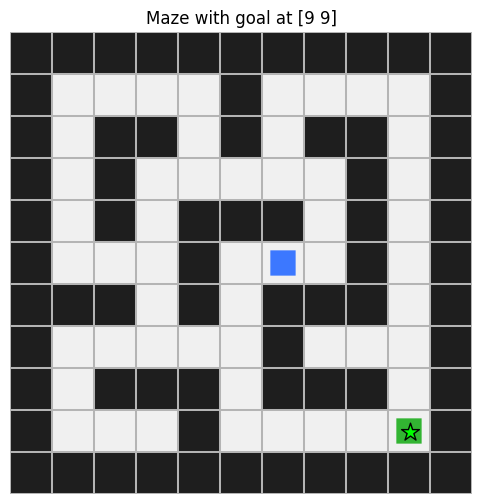

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

## Training Loop across goals

first loop = retrain from scratch for every goal

second loop = retrain from previous task weights as initialisation


================ SEED 42 ================


===== PASS 1 / 3 =====


----- seed=42, goal=(9, 9) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-8.550 | eval_len=88.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-5.825 | eval_len=63.1| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-9.937 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.953 | eval_return=-9.875 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.941 | eval_return=-8.512 | eval_len=87.9| Ortho loss=0.000 | SigReg loss=0.998 | Loss=0.004| Weight loss=0.0000000000 | EWC loss=0.00000

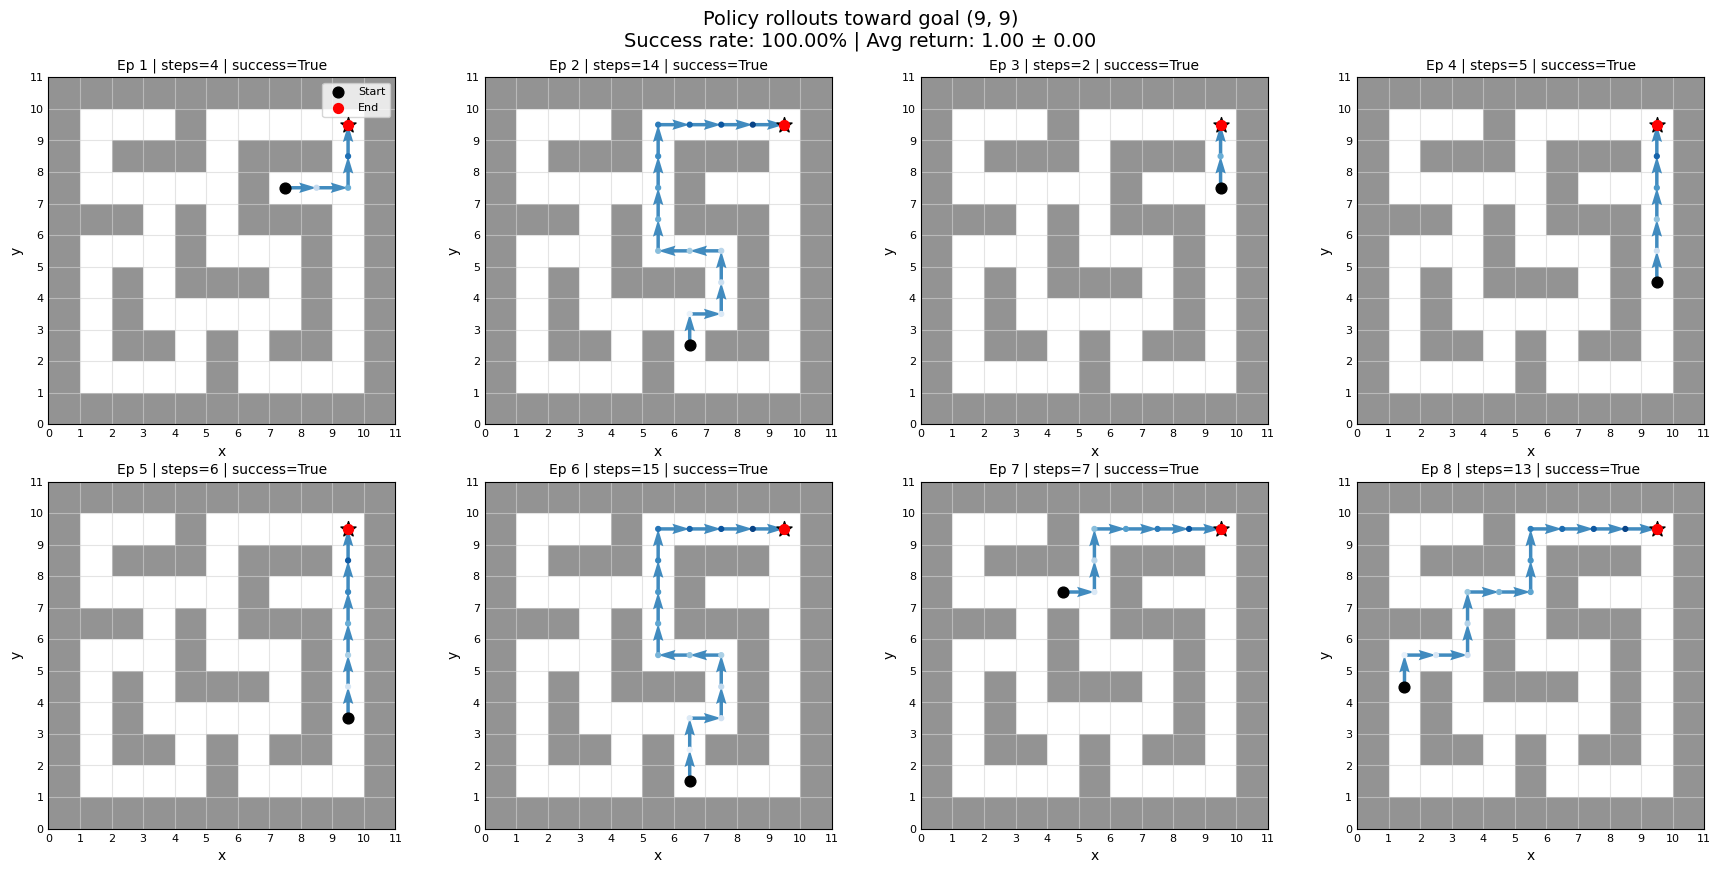

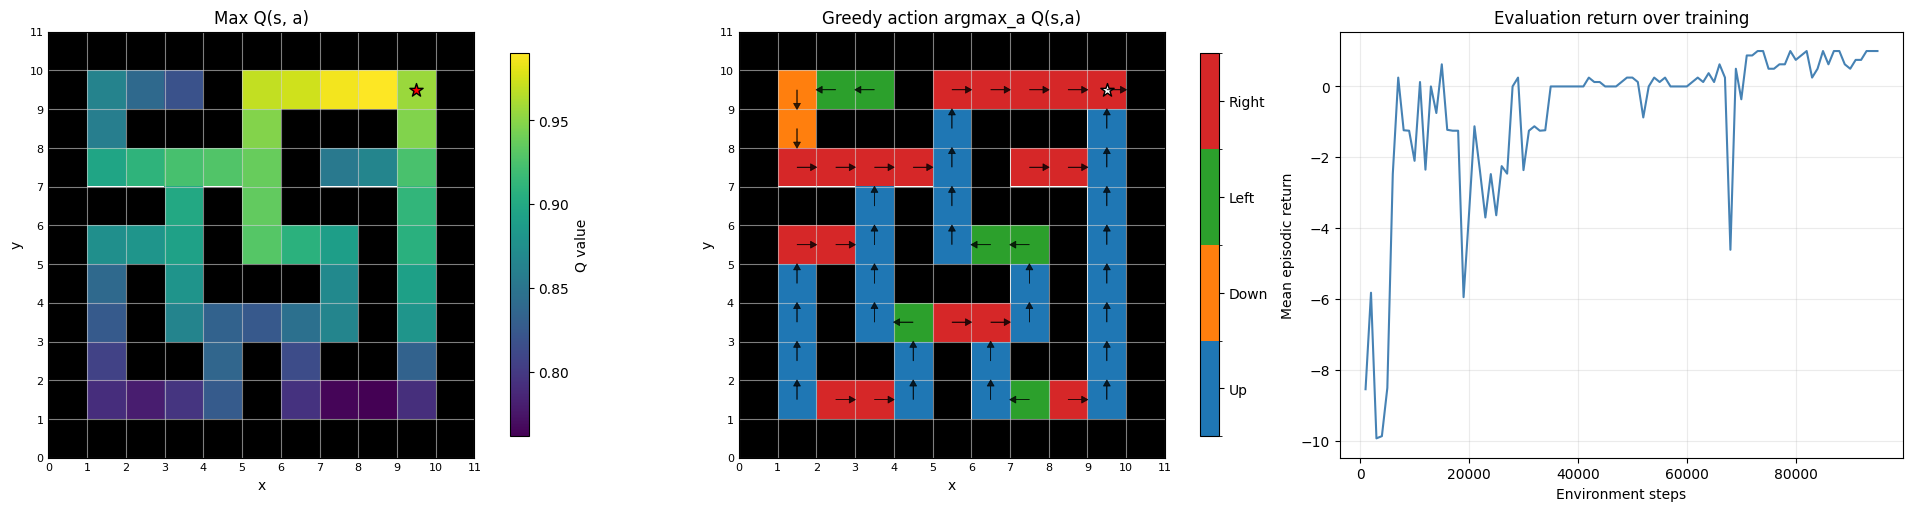

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6404495 3.426242  3.0316443 2.5616987 2.0120502]
cumulative variance (first 5 dims): [0.21441038 0.4043309  0.55302453 0.6591921  0.7246879 ]
cos(phi(s,a), psi/task): mean=0.8156, std=0.0759


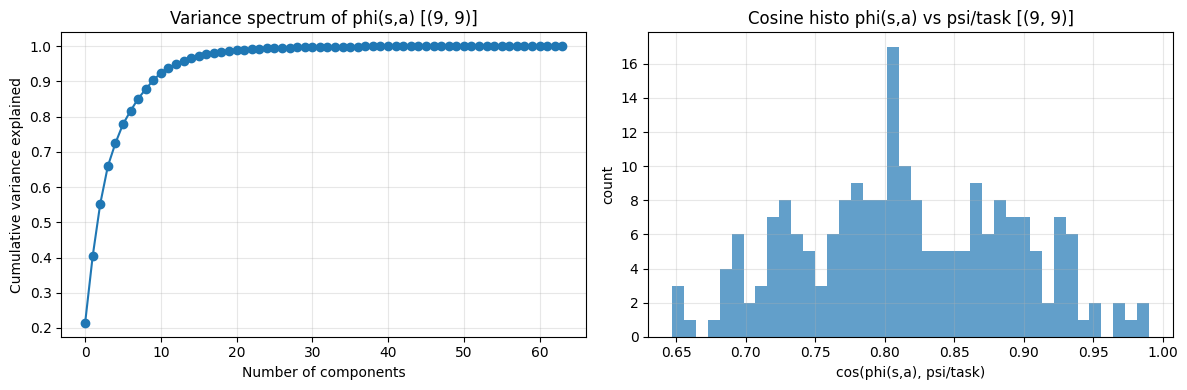


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000

----- seed=42, goal=(7, 7) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-9.975 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.937 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-9.937 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.953 | eval_return=-9.825 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   5000 | eps=0.941 | eval_return=-9.812 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.998 | Loss=0.004| Weight loss=0.0000000000 | EWC loss

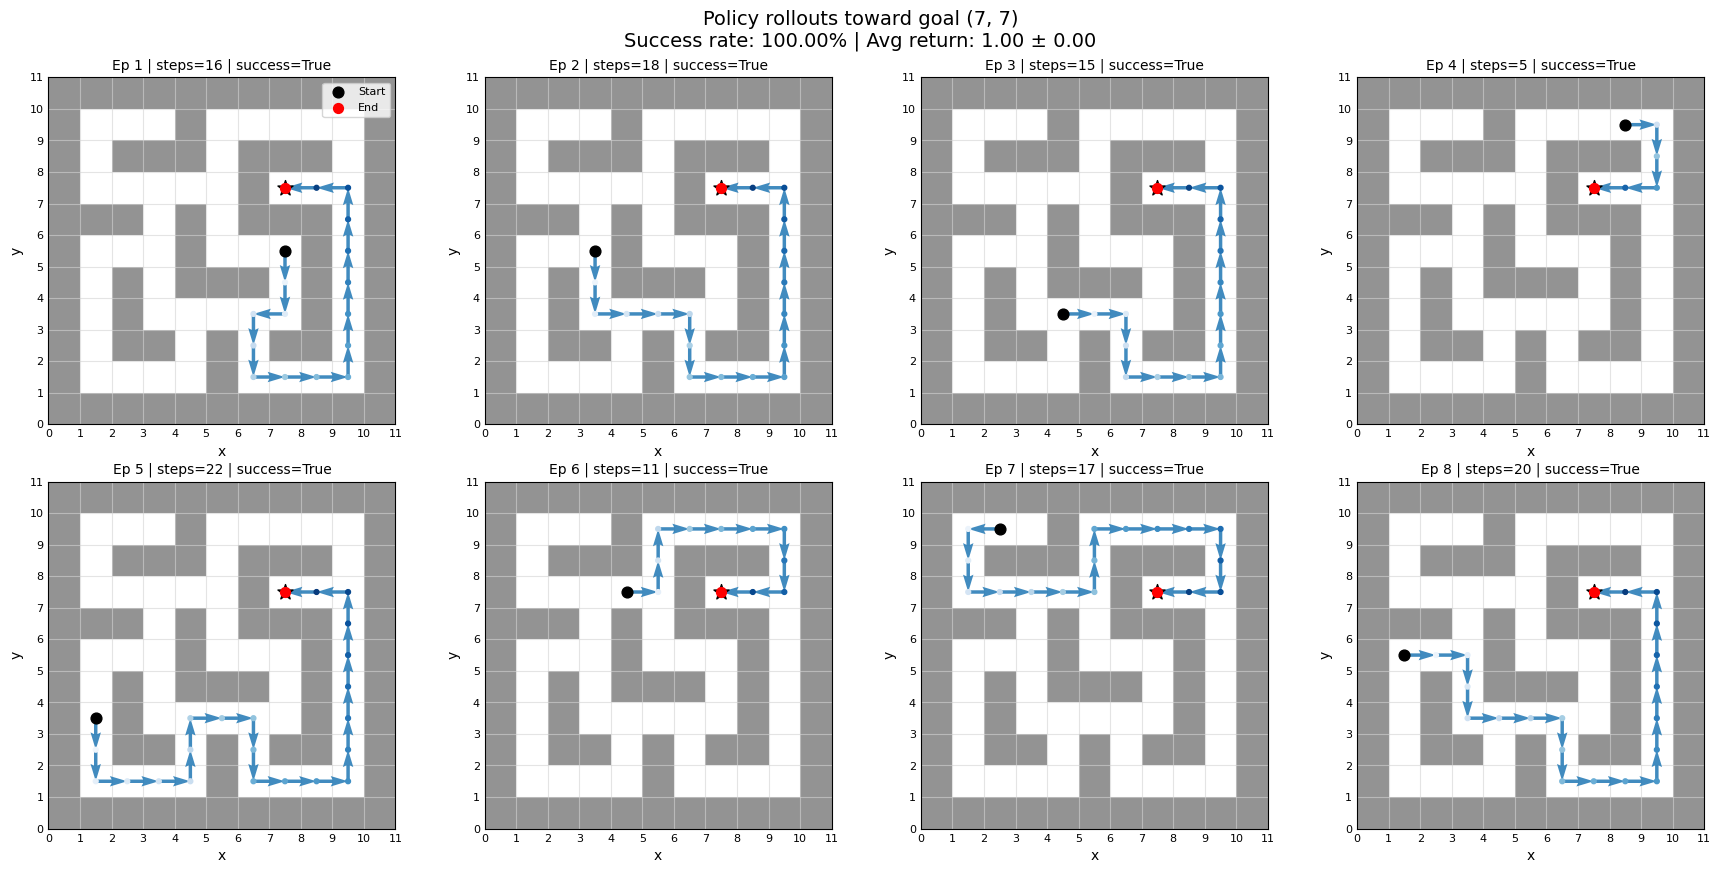

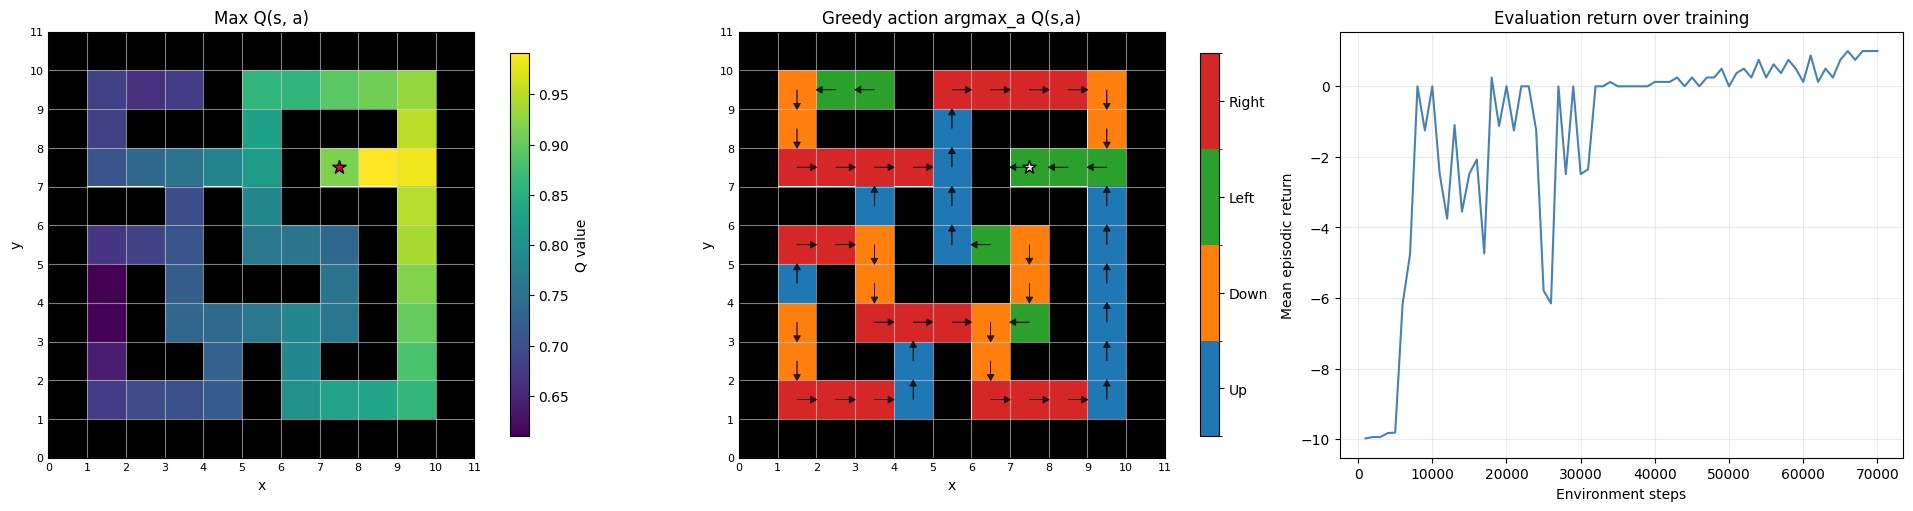

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.1571913 3.8701682 2.7934704 2.2310193 1.8776562]
cumulative variance (first 5 dims): [0.37347373 0.58379984 0.69337744 0.7632715  0.8127784 ]
cos(phi(s,a), psi/task): mean=0.7272, std=0.1104


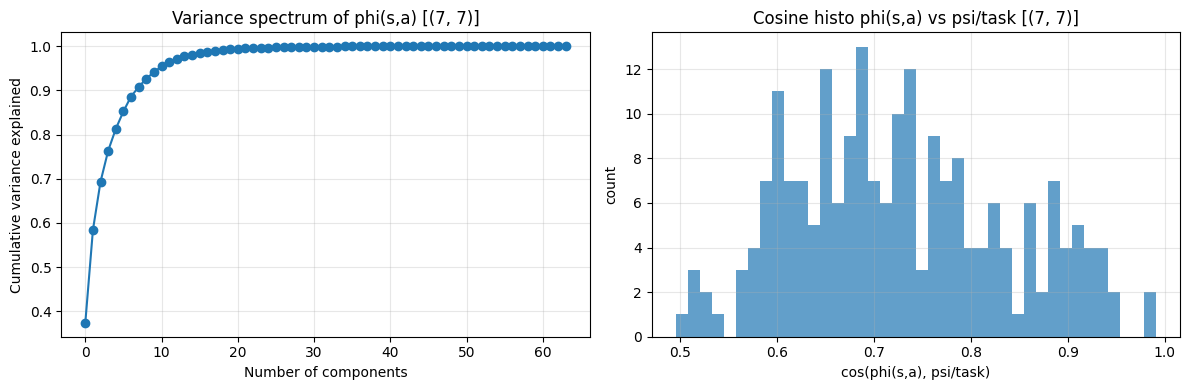


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)
  (9, 9)      1.000      0.672
  (7, 7)      0.672      1.000

Off-diagonal mean similarity: 0.672
Off-diagonal min similarity: 0.672
Off-diagonal max similarity: 0.672

----- seed=42, goal=(3, 5) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-8.600 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.850 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-8.512 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.953 | eval_return=-7.137 | eval_len=75.2| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-facto

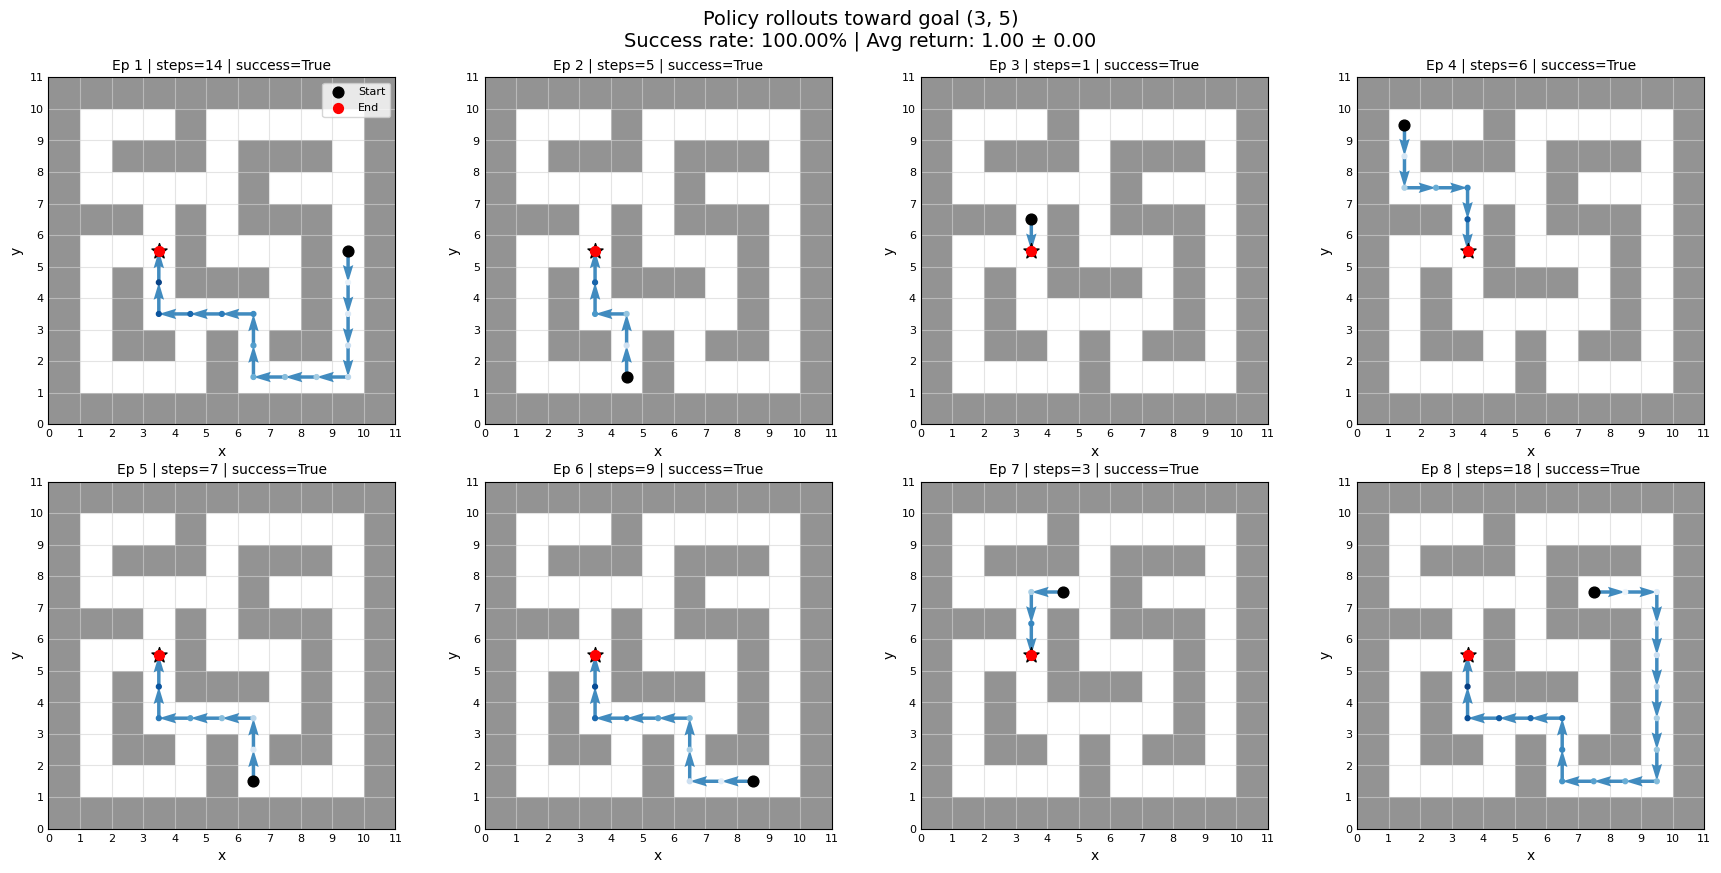

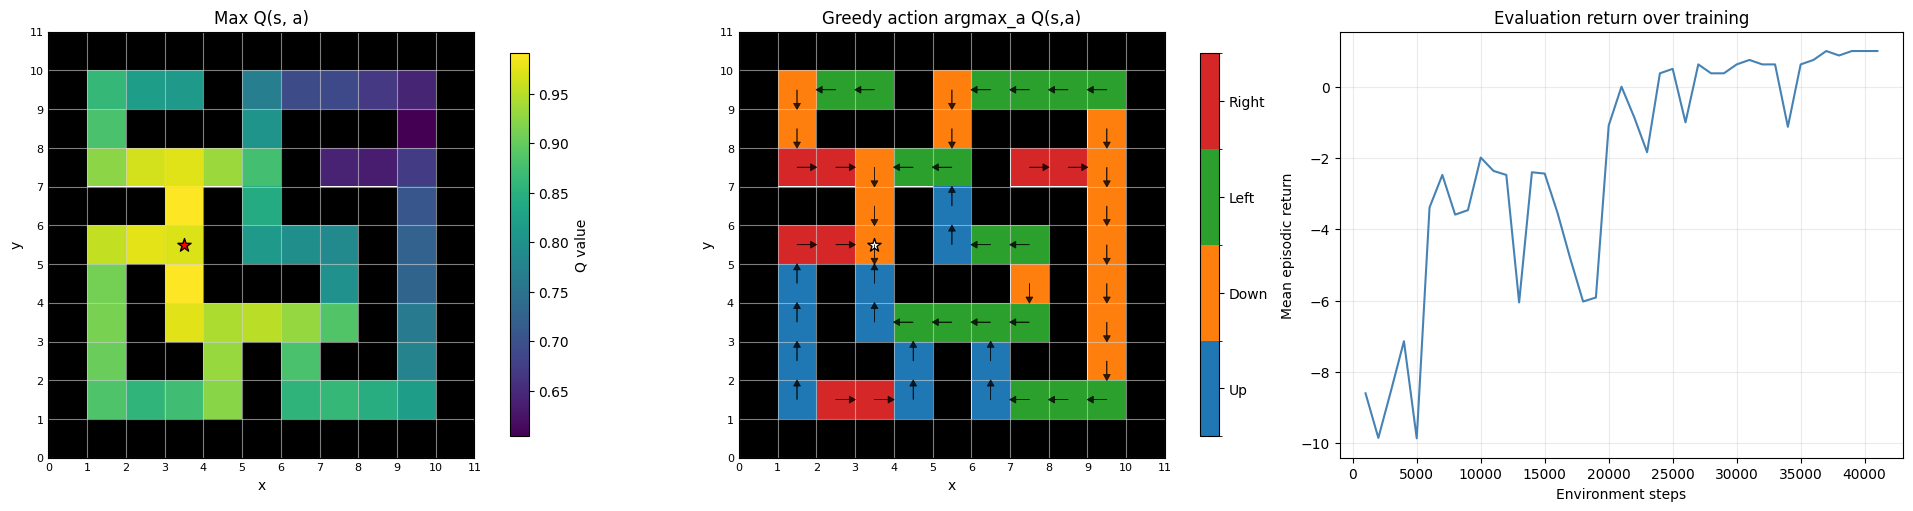

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.890912  3.7696562 3.3370056 2.582817  1.7541887]
cumulative variance (first 5 dims): [0.34354576 0.5476295  0.70755535 0.80336124 0.8475546 ]
cos(phi(s,a), psi/task): mean=0.7789, std=0.1136


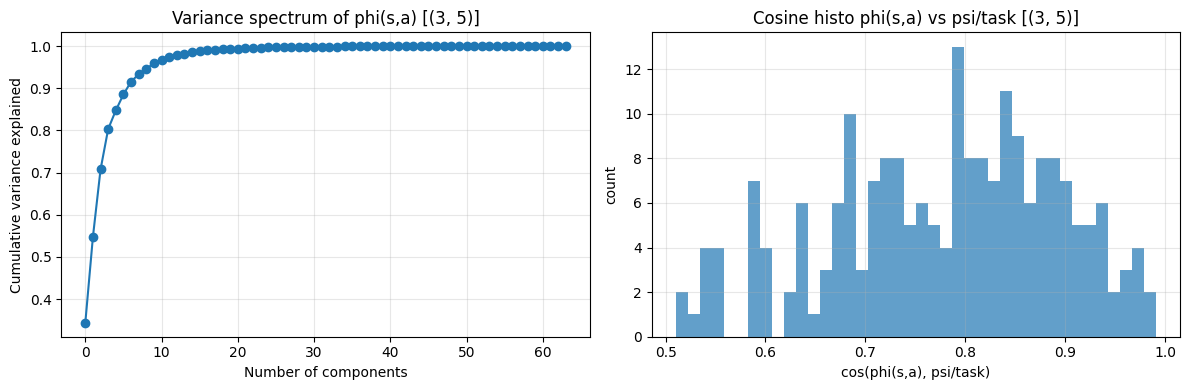


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.672      0.447
  (7, 7)      0.672      1.000      0.520
  (3, 5)      0.447      0.520      1.000

Off-diagonal mean similarity: 0.546
Off-diagonal min similarity: 0.447
Off-diagonal max similarity: 0.672

----- seed=42, goal=(3, 9) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-8.512 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.825 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-8.500 | eval_len=87.6| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   4000 | eps=0.953 | eval_return=-9.925 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.0

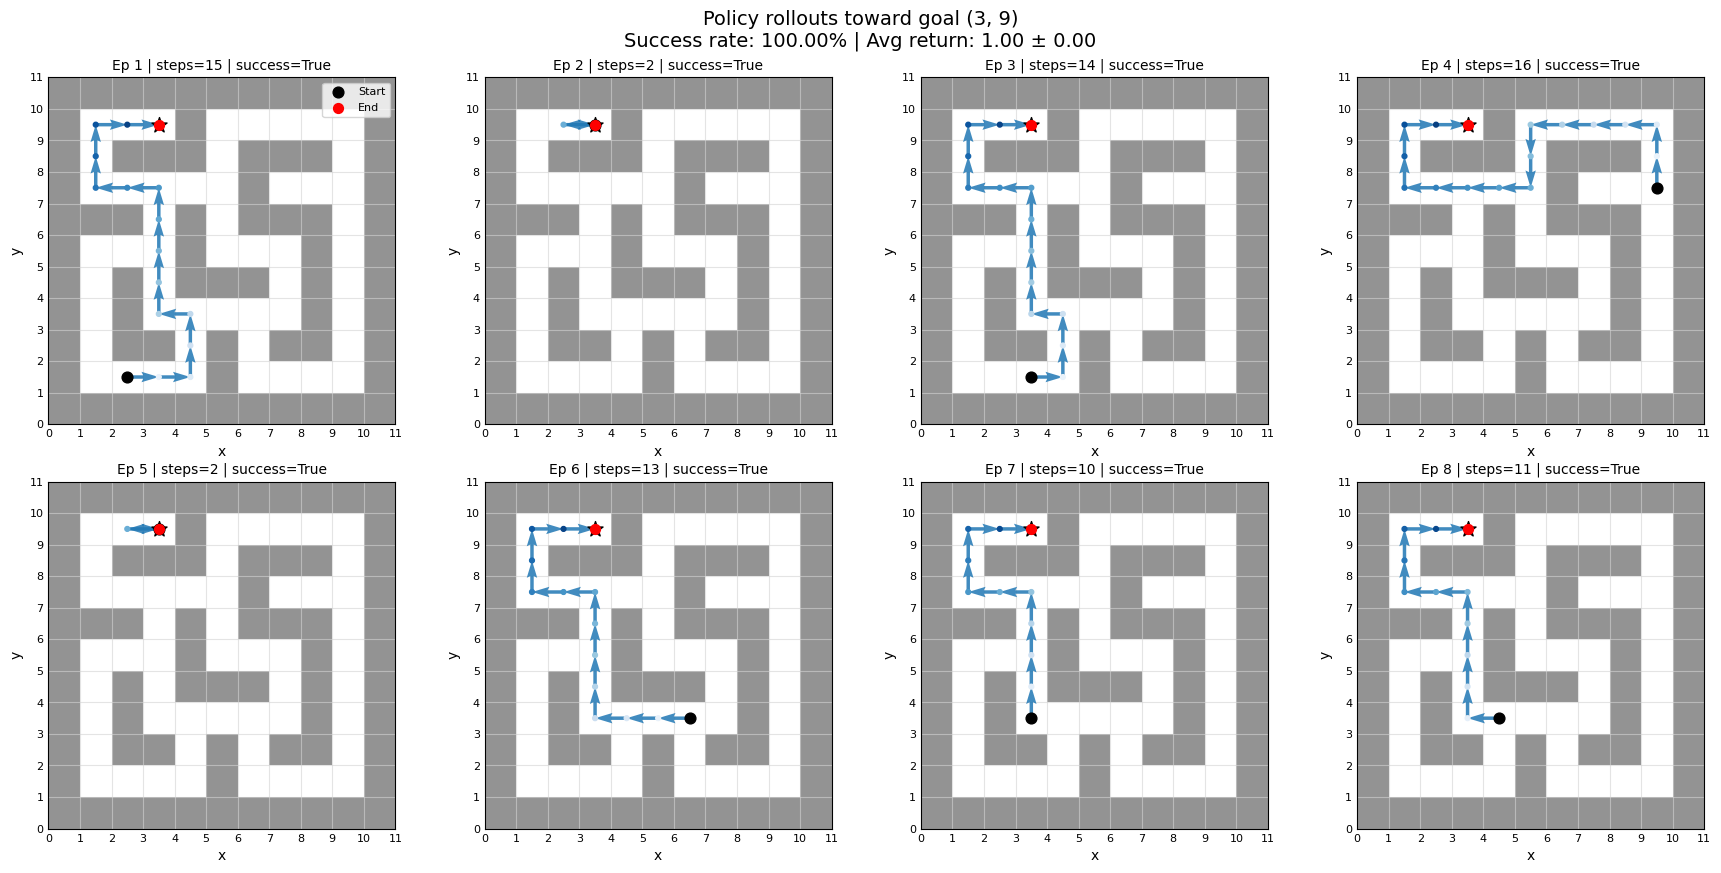

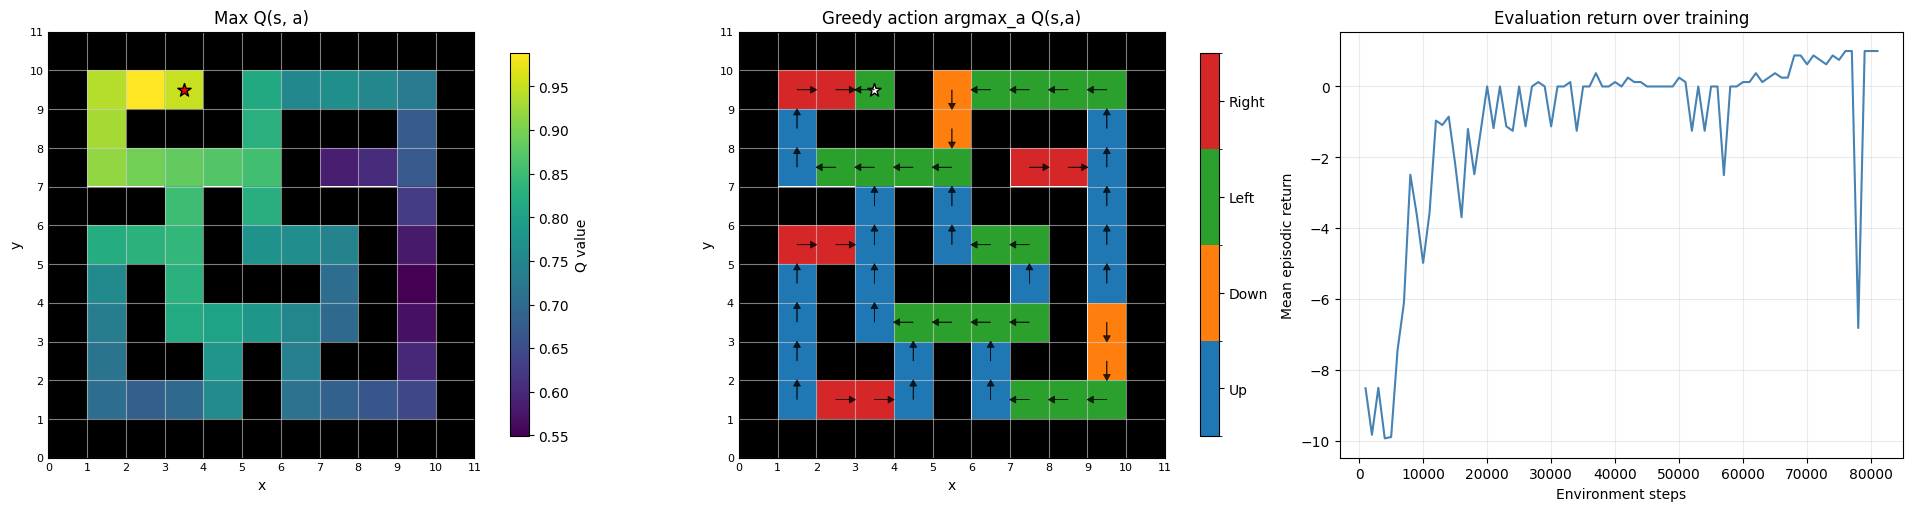

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.5624623 3.6609504 3.5817113 2.7060478 2.2977839]
cumulative variance (first 5 dims): [0.26084918 0.42879862 0.5895564  0.68131816 0.7474803 ]
cos(phi(s,a), psi/task): mean=0.6956, std=0.1159


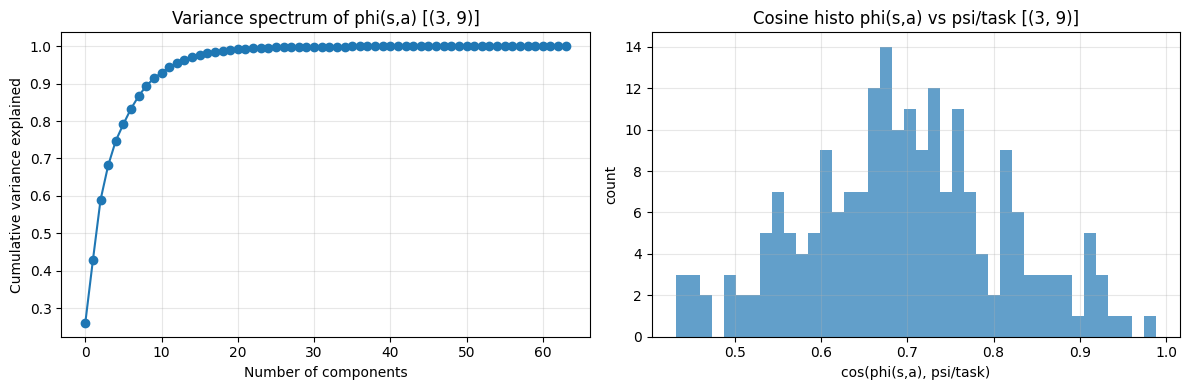


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.672      0.447      0.207
  (7, 7)      0.672      1.000      0.520      0.296
  (3, 5)      0.447      0.520      1.000      0.099
  (3, 9)      0.207      0.296      0.099      1.000

Off-diagonal mean similarity: 0.374
Off-diagonal min similarity: 0.099
Off-diagonal max similarity: 0.672

----- seed=42, goal=(5, 5) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-9.962 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.937 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-9.862 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised]

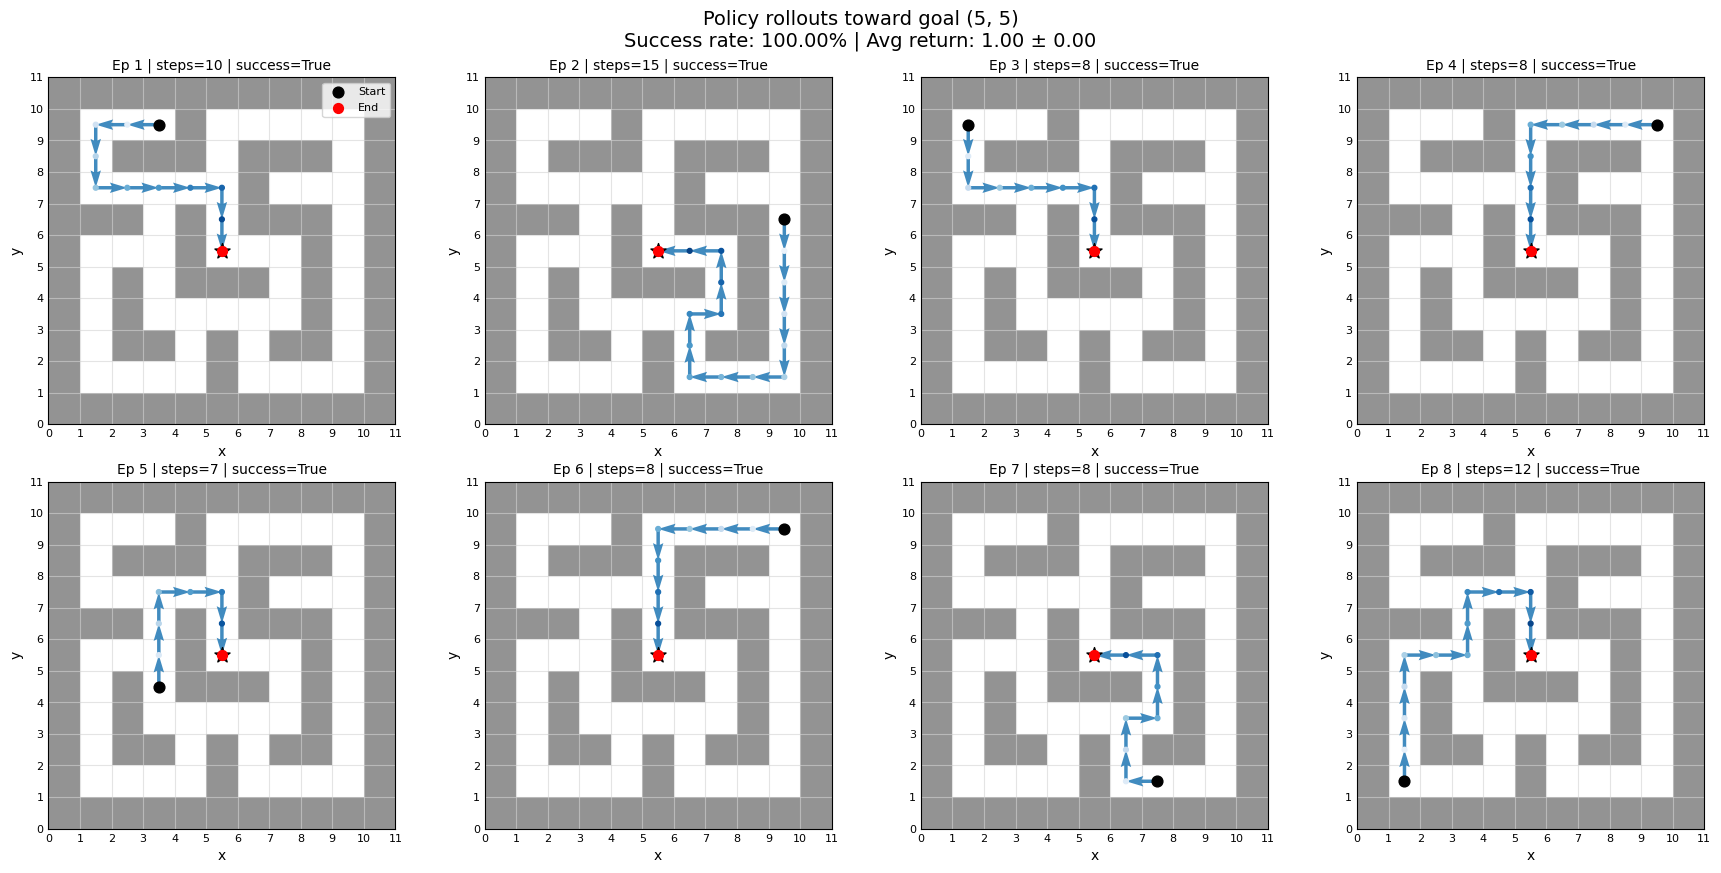

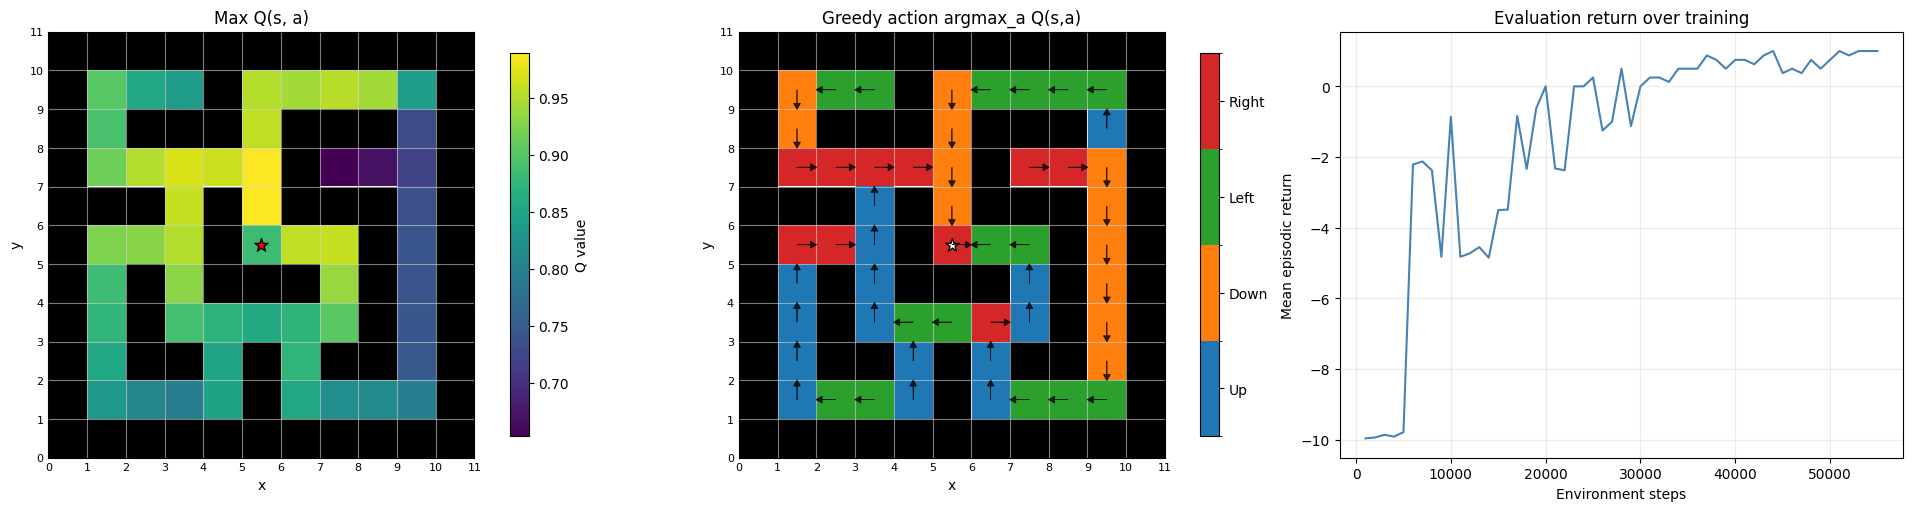

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.8191905 3.7832854 2.392725  2.2757695 2.1122553]
cumulative variance (first 5 dims): [0.36827064 0.5952347  0.6860177  0.7681427  0.8388903 ]
cos(phi(s,a), psi/task): mean=0.8068, std=0.1020


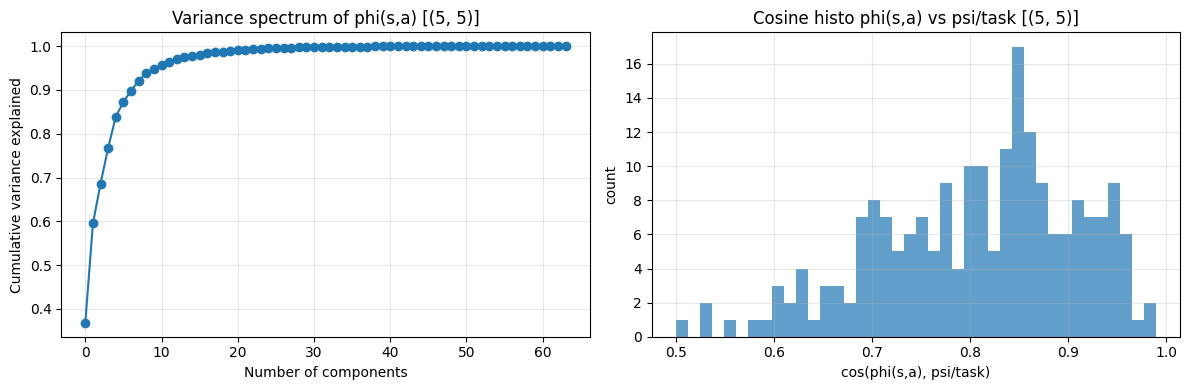


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.672      0.447      0.207      0.495
  (7, 7)      0.672      1.000      0.520      0.296      0.544
  (3, 5)      0.447      0.520      1.000      0.099      0.289
  (3, 9)      0.207      0.296      0.099      1.000      0.506
  (5, 5)      0.495      0.544      0.289      0.506      1.000

Off-diagonal mean similarity: 0.408
Off-diagonal min similarity: 0.099
Off-diagonal max similarity: 0.672

----- seed=42, goal=(3, 6) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-9.887 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.862 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   3000 | eps=0.964 | eval_return=-9.975 | eval_len=100.

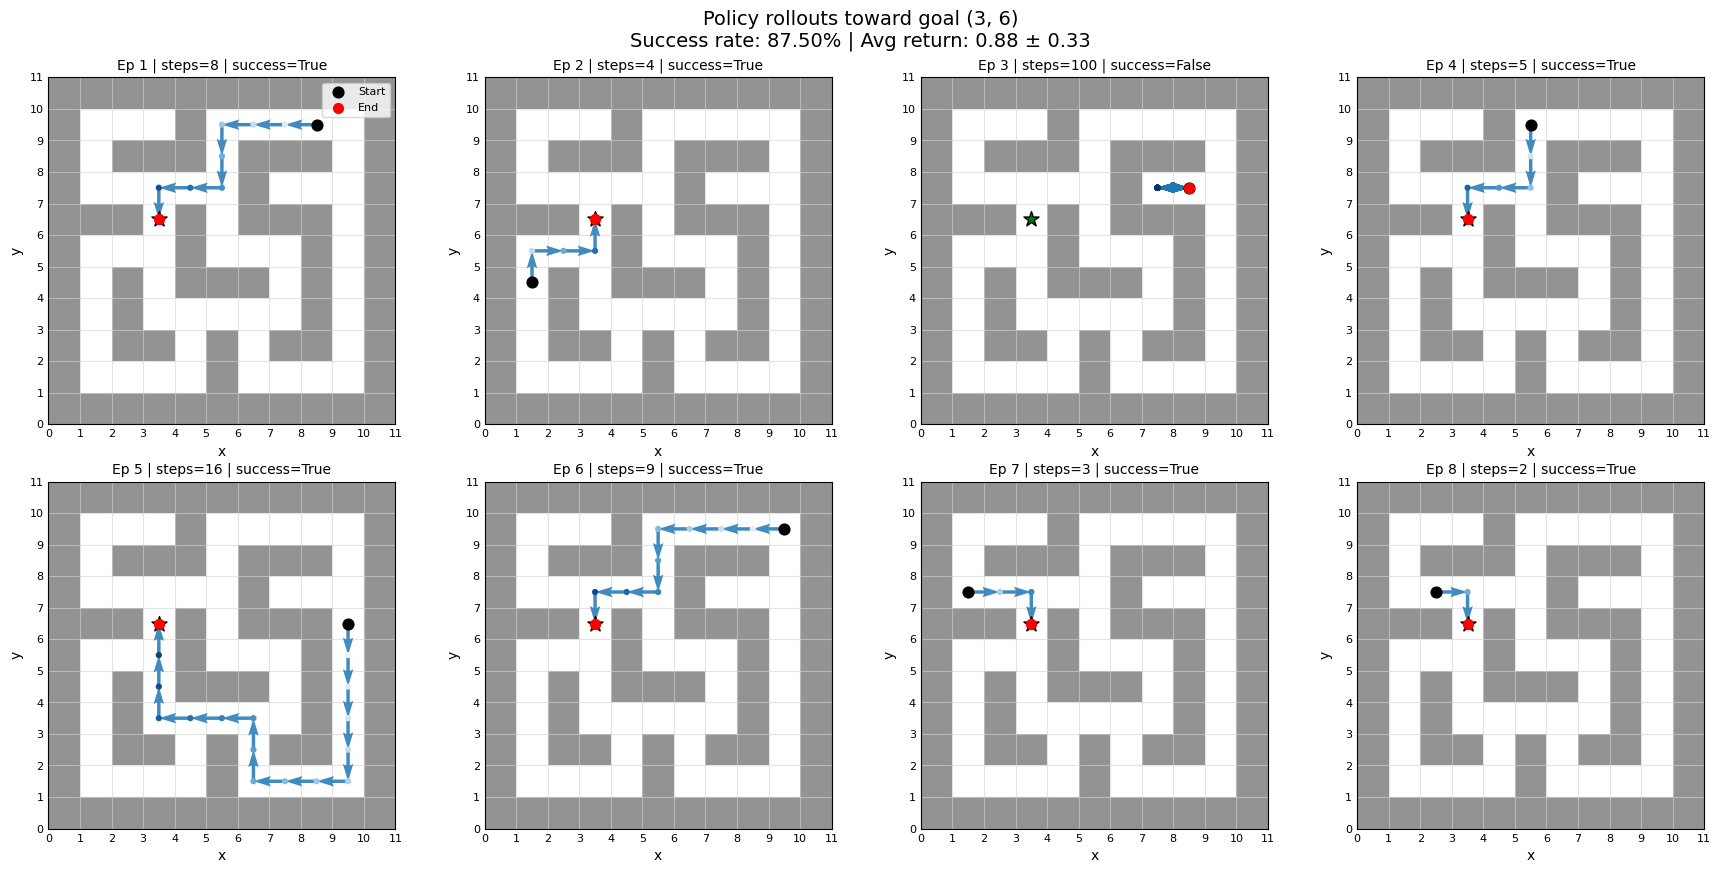

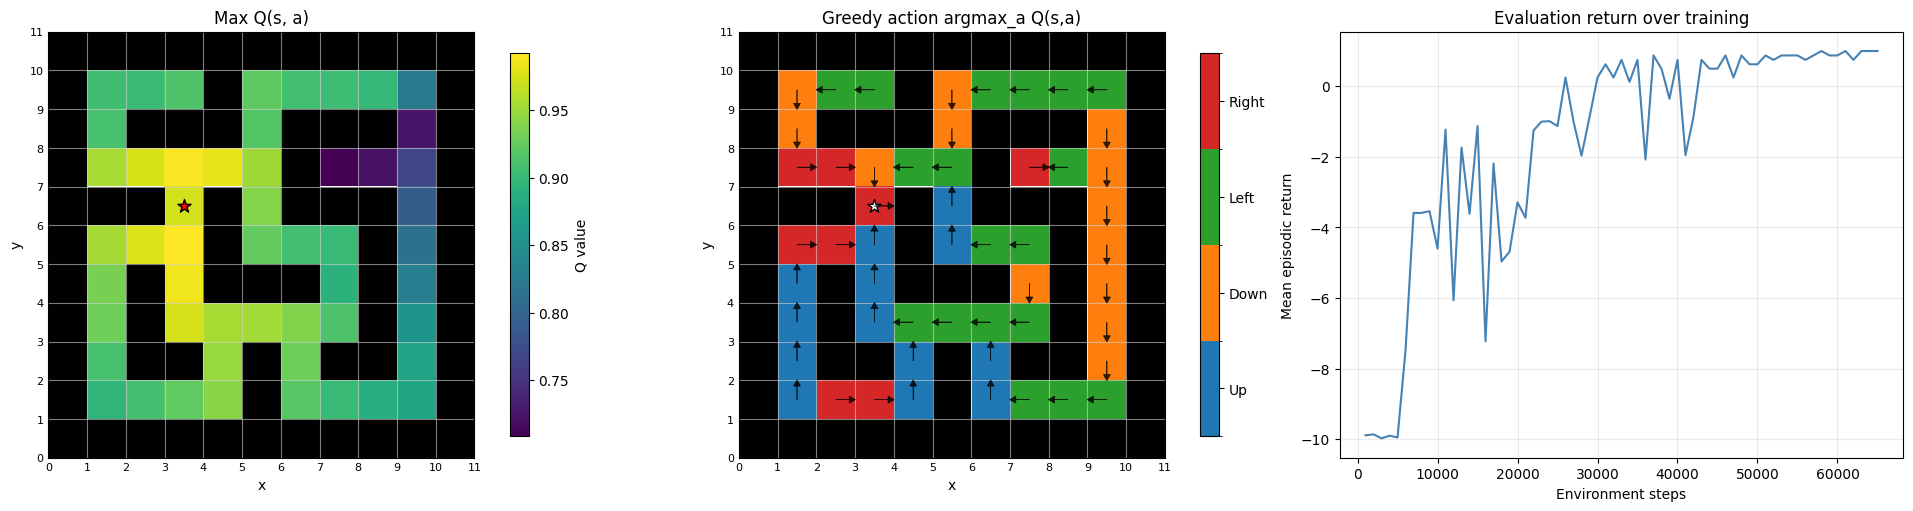

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6267023 3.331729  2.6172004 2.4208074 1.9111496]
cumulative variance (first 5 dims): [0.25688484 0.47368222 0.60746145 0.72191656 0.79325175]
cos(phi(s,a), psi/task): mean=0.8449, std=0.0841


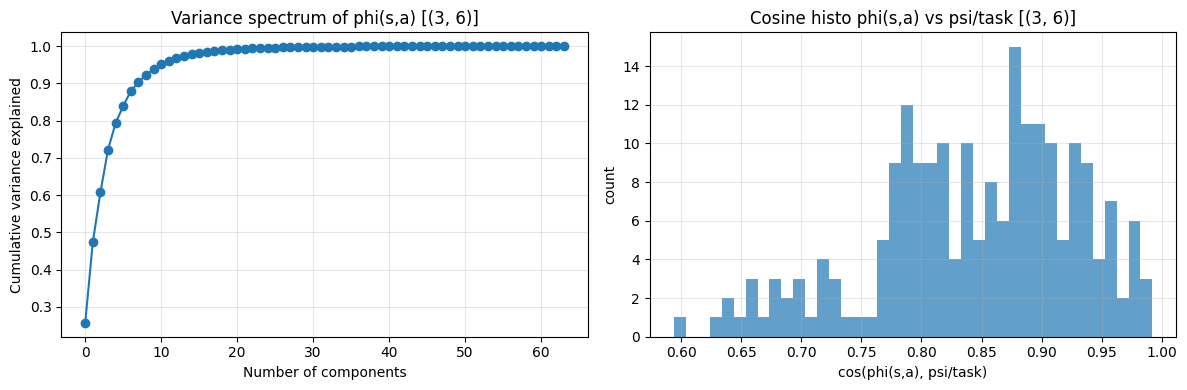


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000

Off-diagonal mean similarity: 0.382
Off-diagonal min similarity: 0.099
Off-diagonal max similarity: 0.672

----- seed=42, goal=(9, 1) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-9.850 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weight loss=0.0000000000 | EWC loss=0.0000000000
[DQN-factorised] step=   2000 | eps=0.976 | eval_return=-9.875 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 

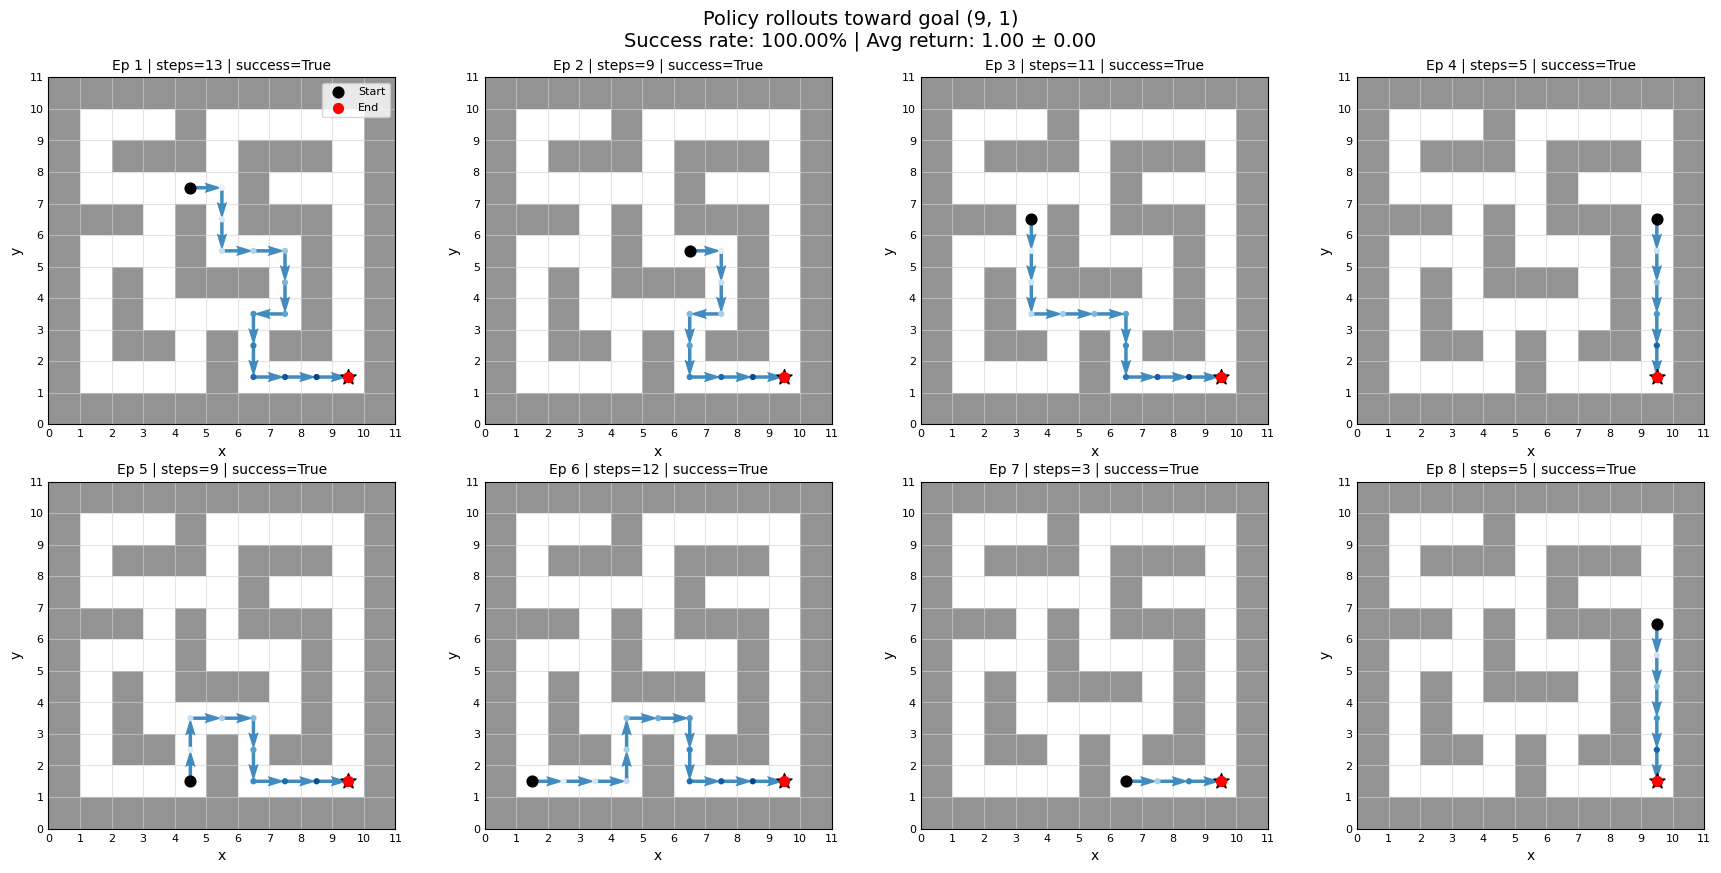

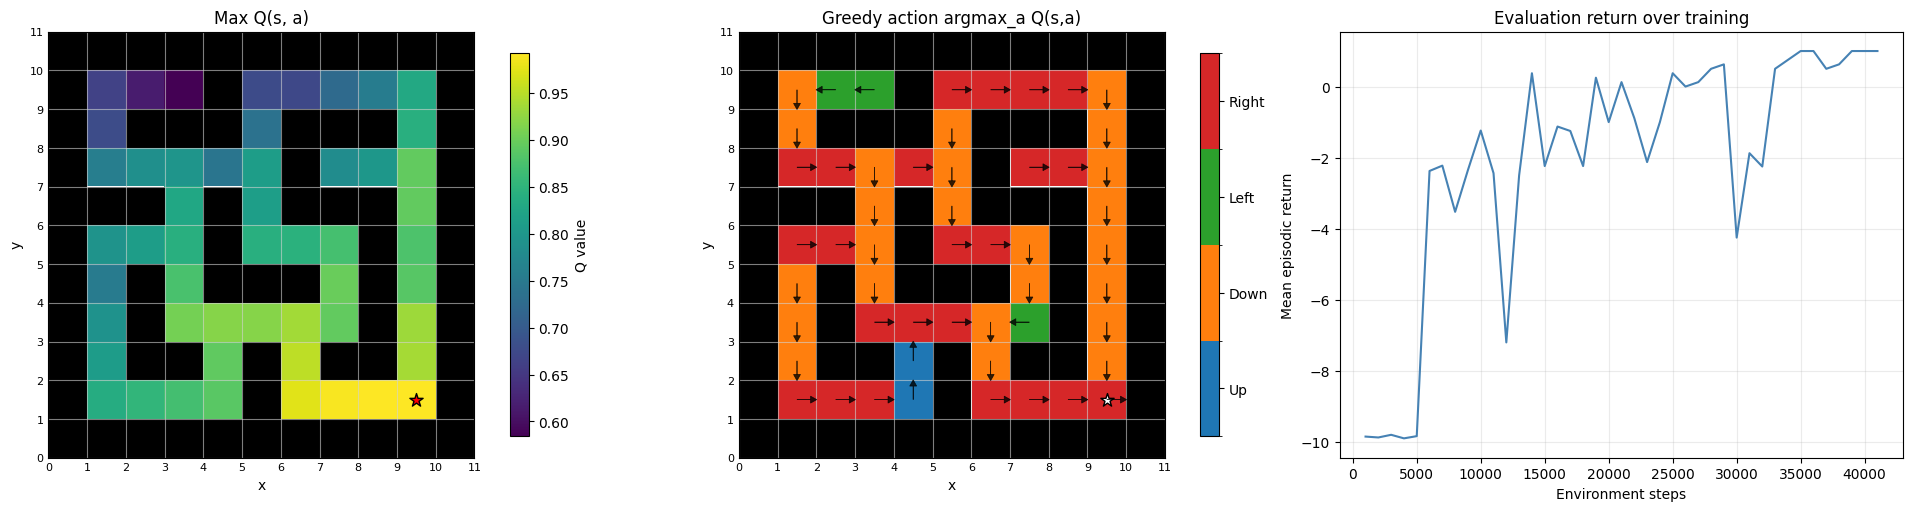

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.399866  3.8794098 3.2303102 2.5053415 1.9717877]
cumulative variance (first 5 dims): [0.28366864 0.50419664 0.65710133 0.7490756  0.8060464 ]
cos(phi(s,a), psi/task): mean=0.7665, std=0.1079


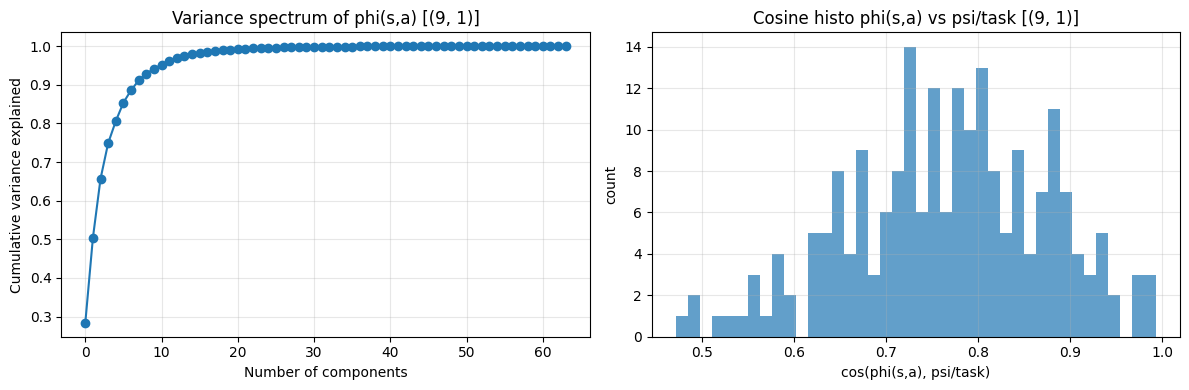


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443
  (9, 1)      0.518      0.658      0.523      0.430      0.653      0.443      1.000

Off-diagonal mean similarity: 0.426
Off-diagonal min similarity: 0.099
Off-diagonal max similarity: 0.672

----- seed=42, goal=(1, 1) -----

[DQN-factorised] step=   1000 | eps=0.988 | eval_return=-7.450 | eval_len=100.0| Ortho loss=0.000 | SigReg loss=0.000 | Loss=0.000| Weig

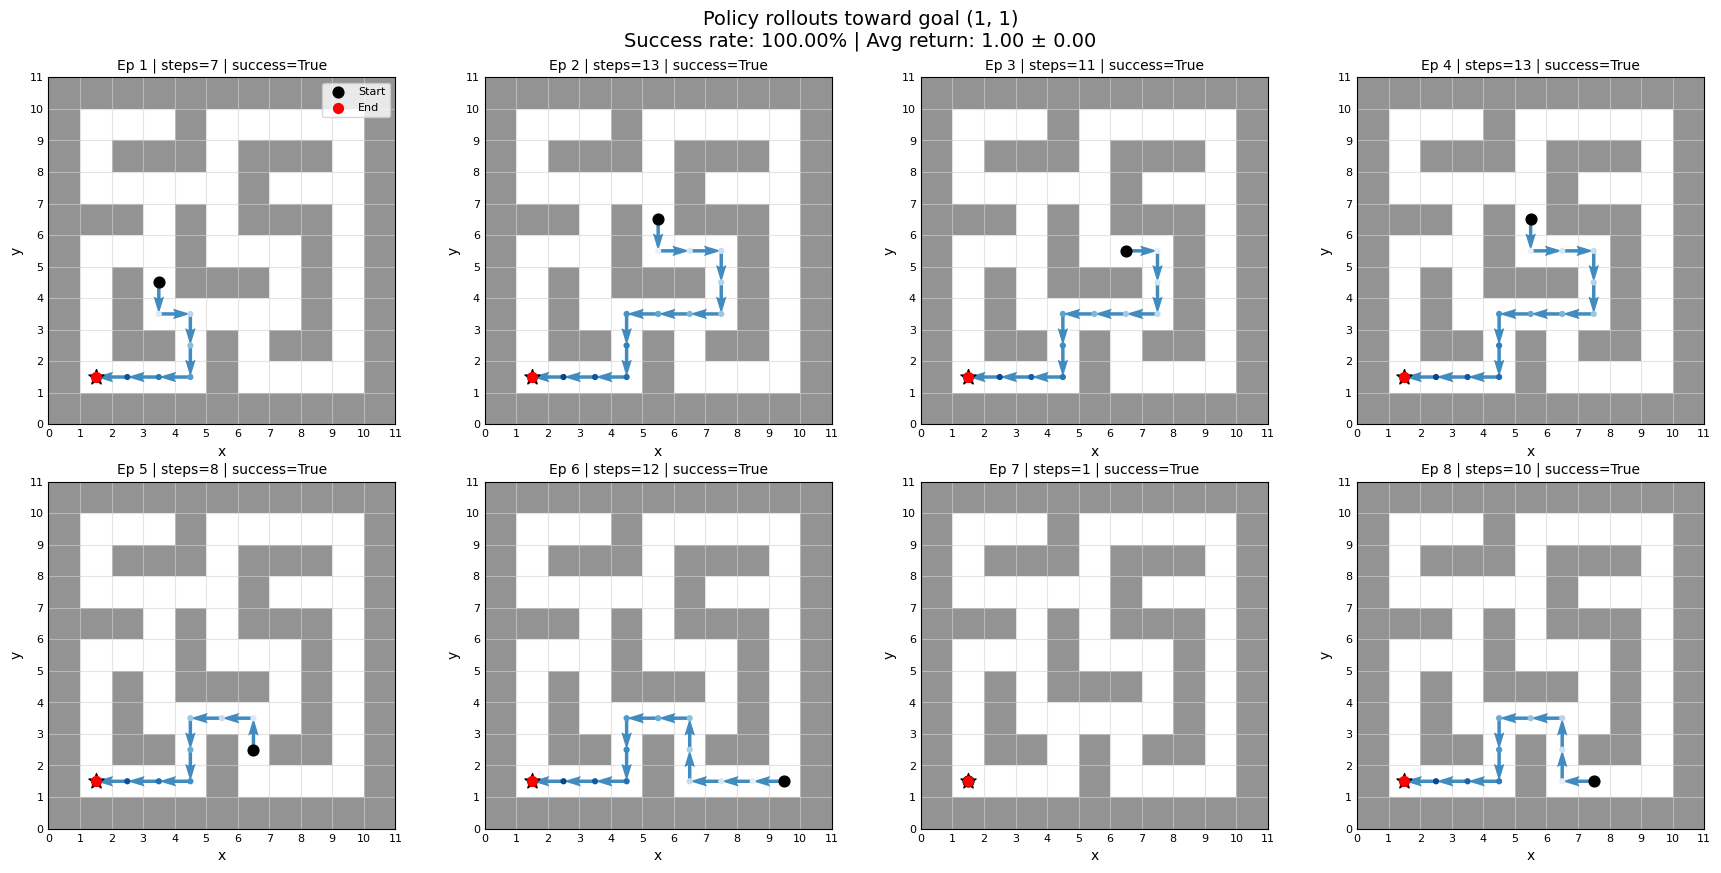

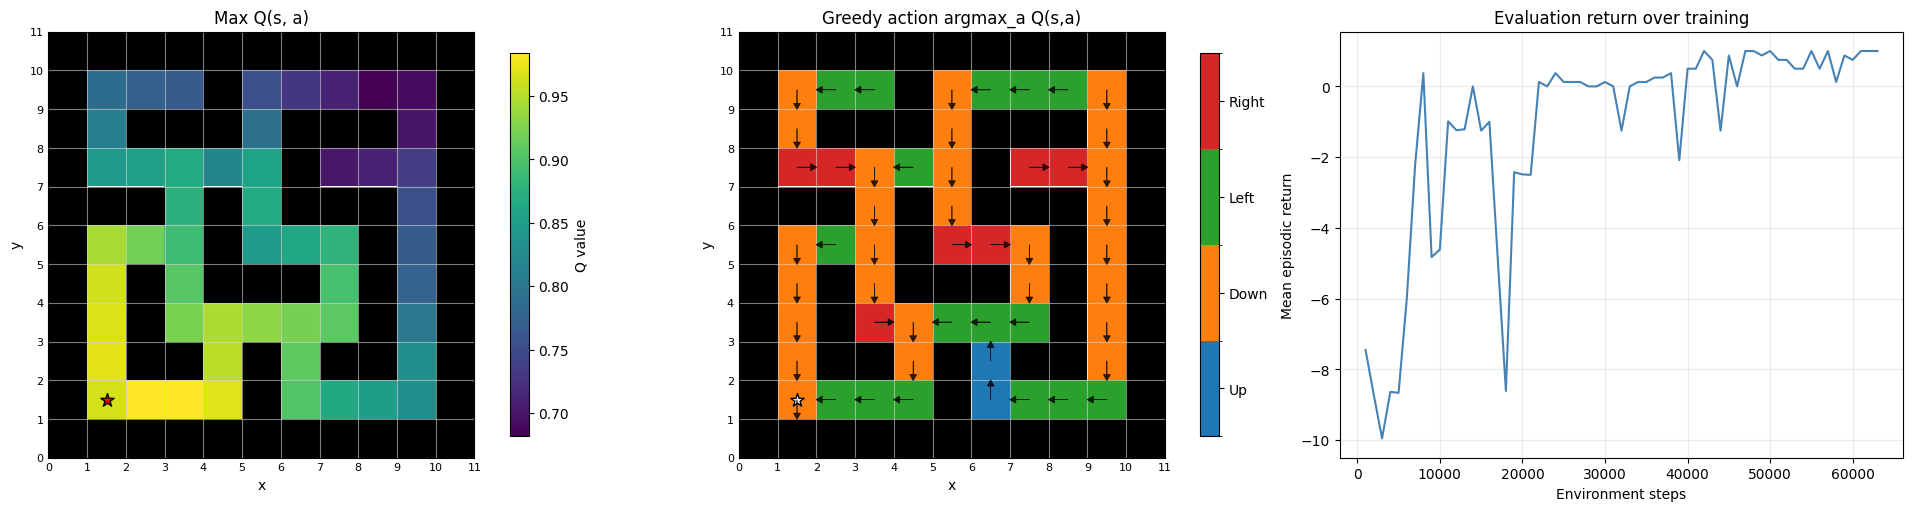

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.7475877 3.0160925 2.8332174 2.3028264 1.9401557]
cumulative variance (first 5 dims): [0.36788028 0.5163541  0.64736885 0.733922   0.79535955]
cos(phi(s,a), psi/task): mean=0.7926, std=0.0985


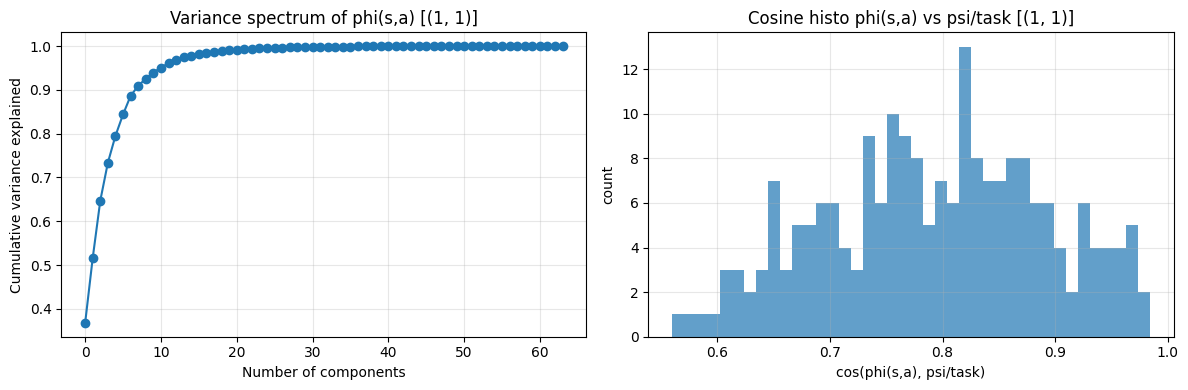


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443      0.436
  (9, 1)      0.518      0.658      0.523      0.430      0.653      0.443      1.000      0.811
  (1, 1)      0.529      0.611      0.382      0.473      0.573      0.436      0.811      1.000

Off-diagonal mean similarity: 0.456
Off-diagonal min similarity: 0.099
Off-diagonal max simi

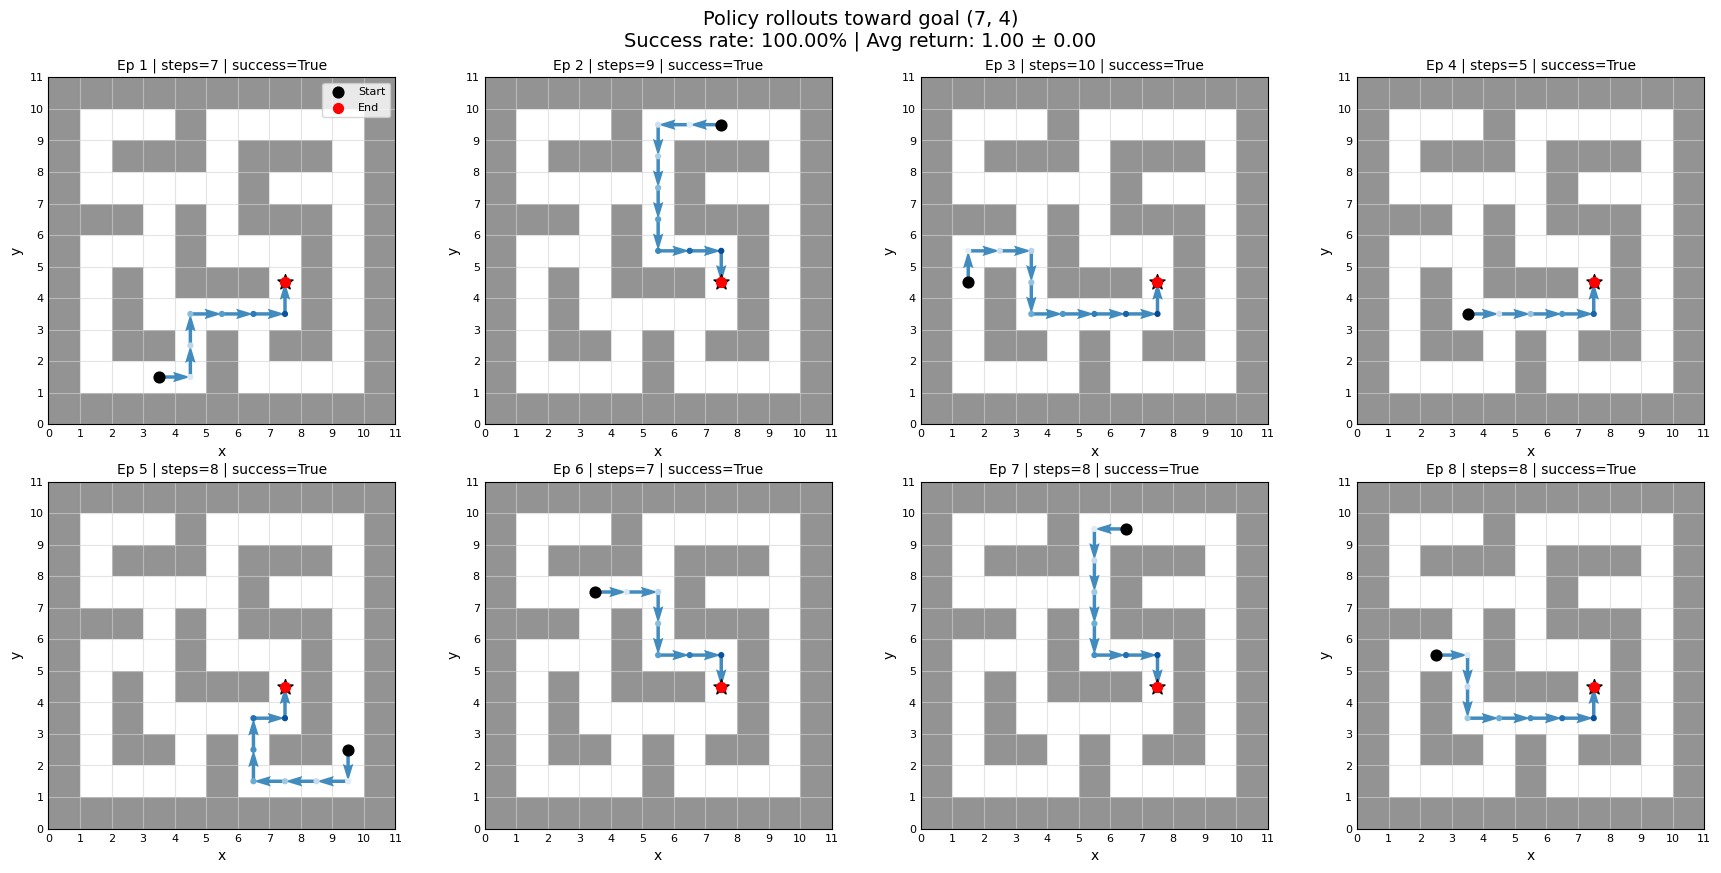

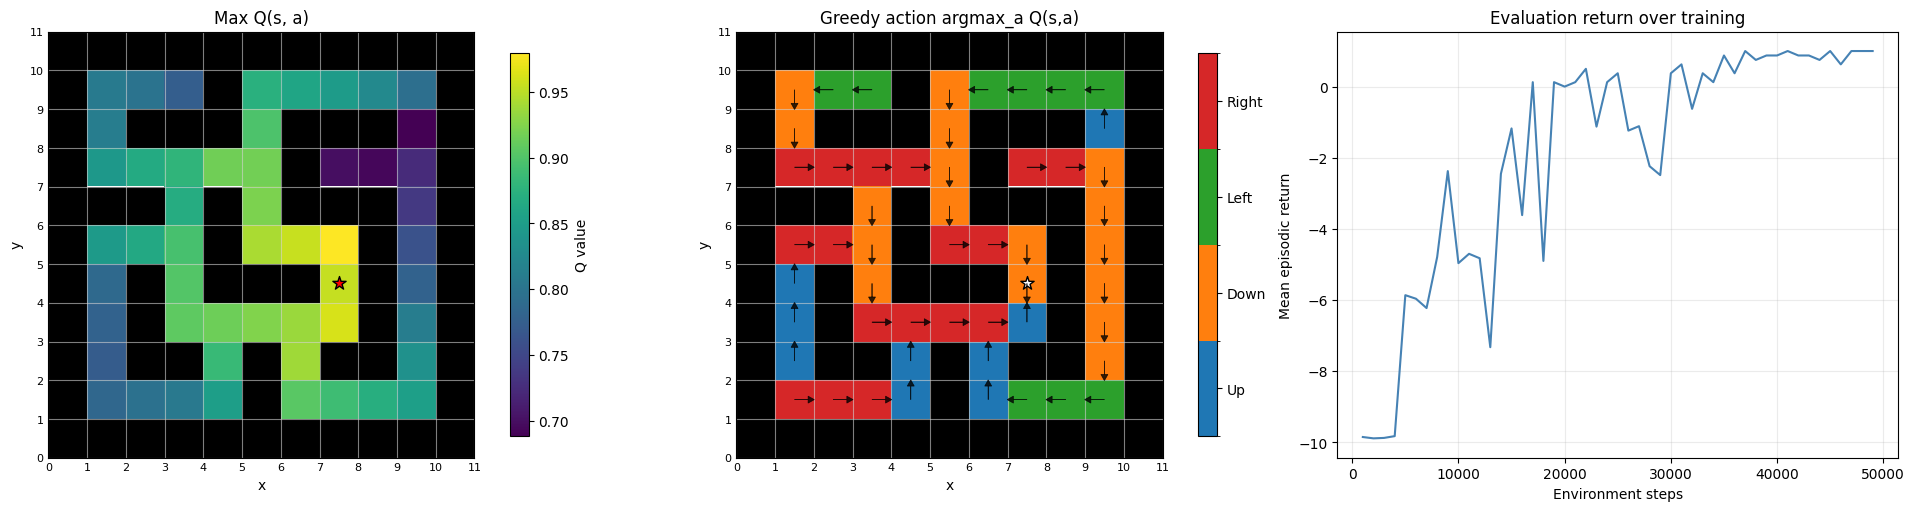

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.8842916 3.3483305 3.2593758 2.5401366 2.3185022]
cumulative variance (first 5 dims): [0.32587764 0.47902447 0.62414217 0.71228063 0.78570944]
cos(phi(s,a), psi/task): mean=0.7880, std=0.0879


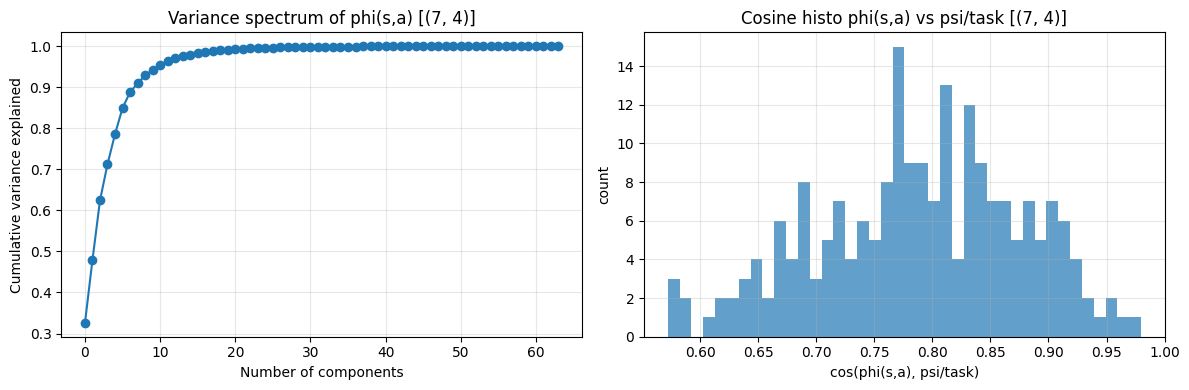


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443      0.436      0.457
  (9, 1)      0.518      0.658      0.523      0.430      0.653      0.443      1.000      0.811      0.554
  (1, 1)      0.529      0.611      0.382      0.473      0.573      0.436      0.811      1.000      

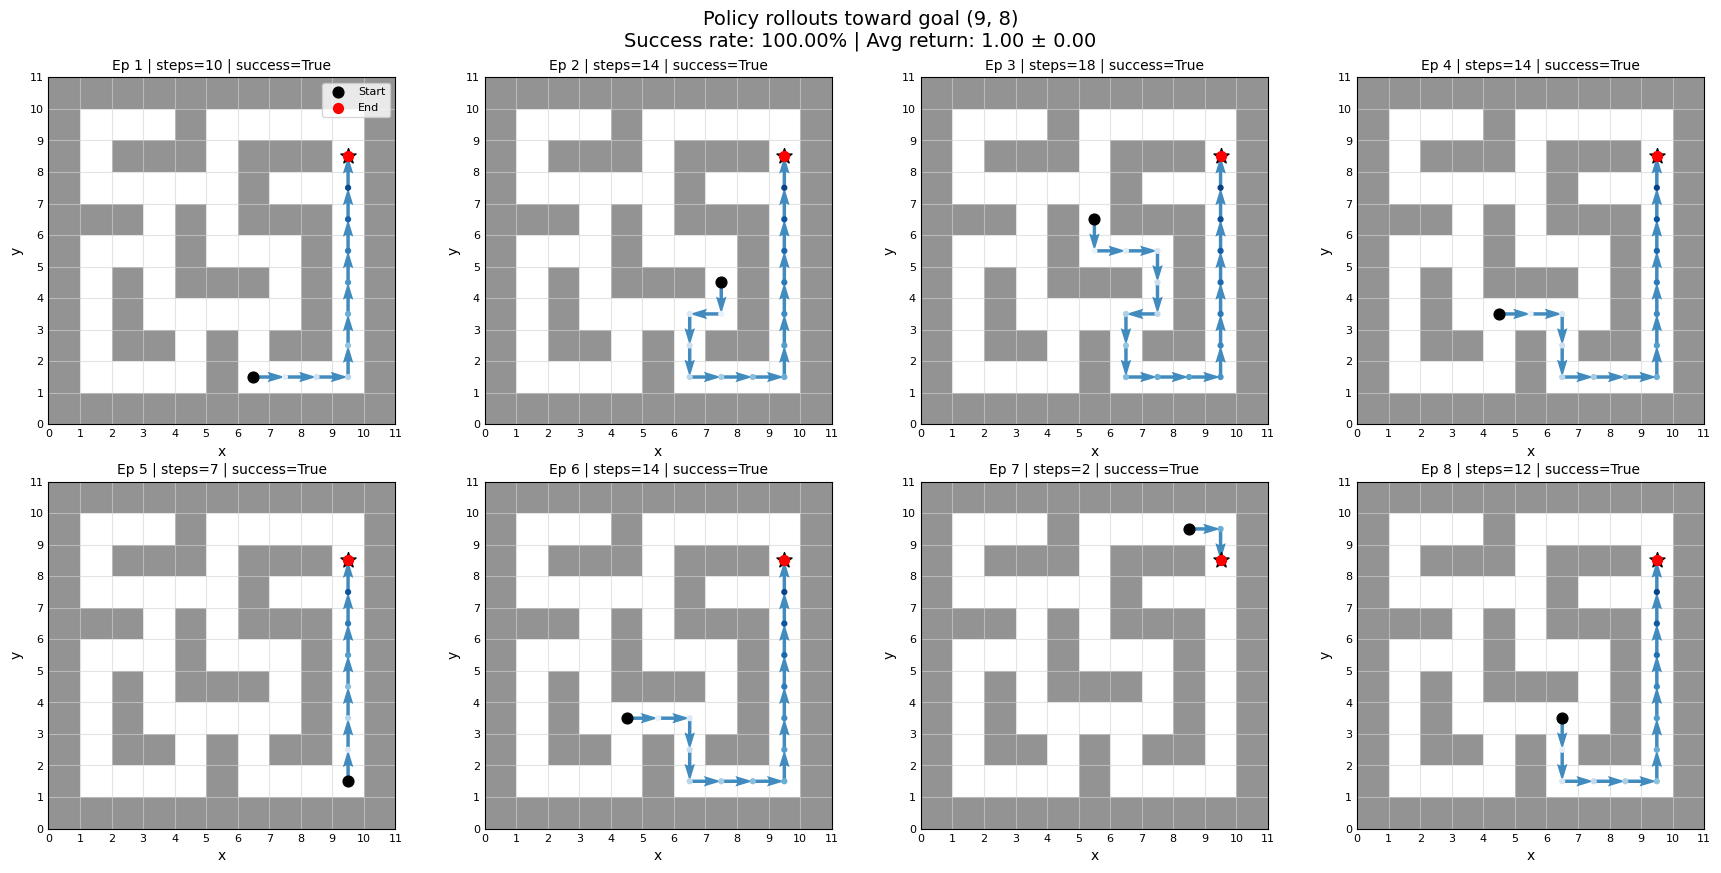

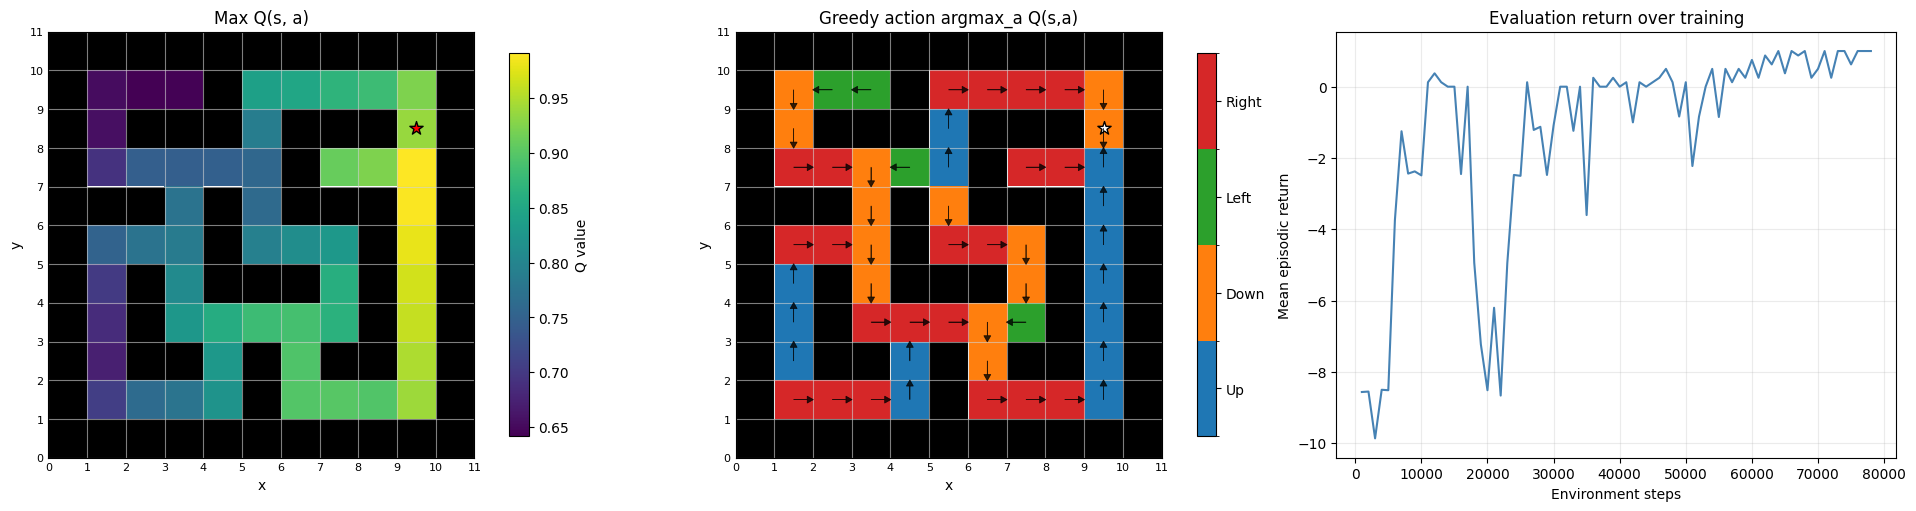

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.8672013 3.8837013 3.0727148 2.3769245 2.2119622]
cumulative variance (first 5 dims): [0.32545343 0.53266877 0.66237915 0.7399969  0.8072149 ]
cos(phi(s,a), psi/task): mean=0.7634, std=0.1081


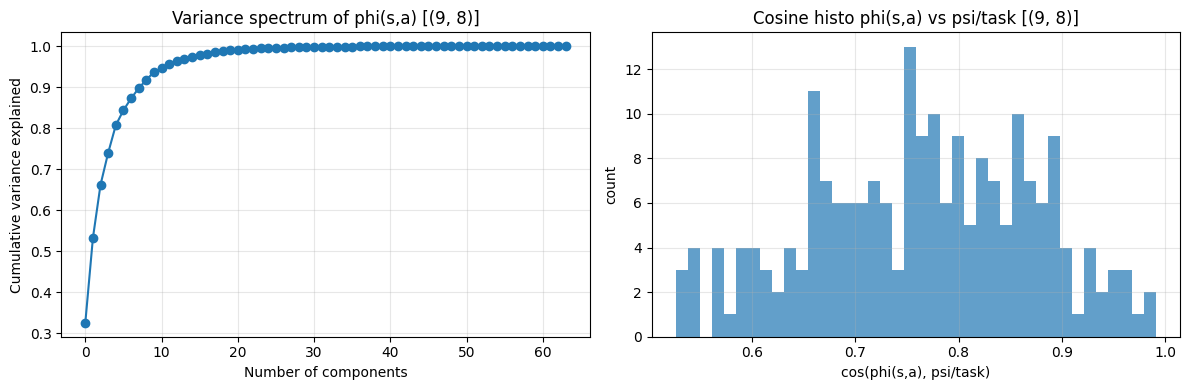


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434      0.375
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443      0.436      0.457      0.142
  (9, 1)      0.518      0.658      0.523      0.430      0.653      0.443      1.000      0.811      0.554      0.518
  (1, 1)      

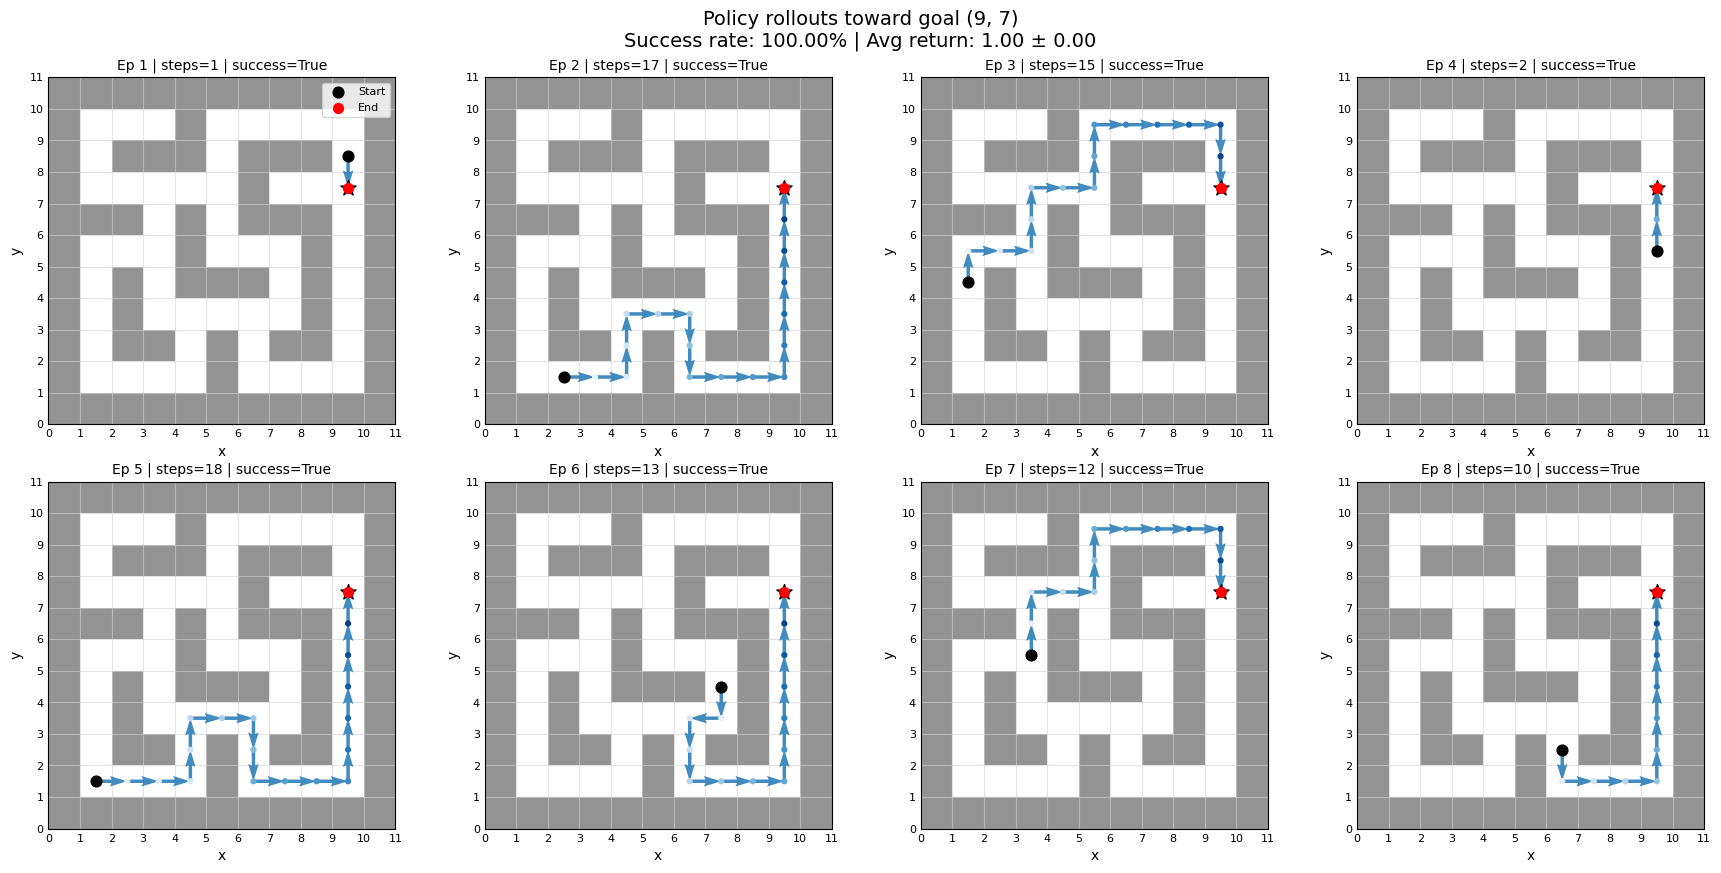

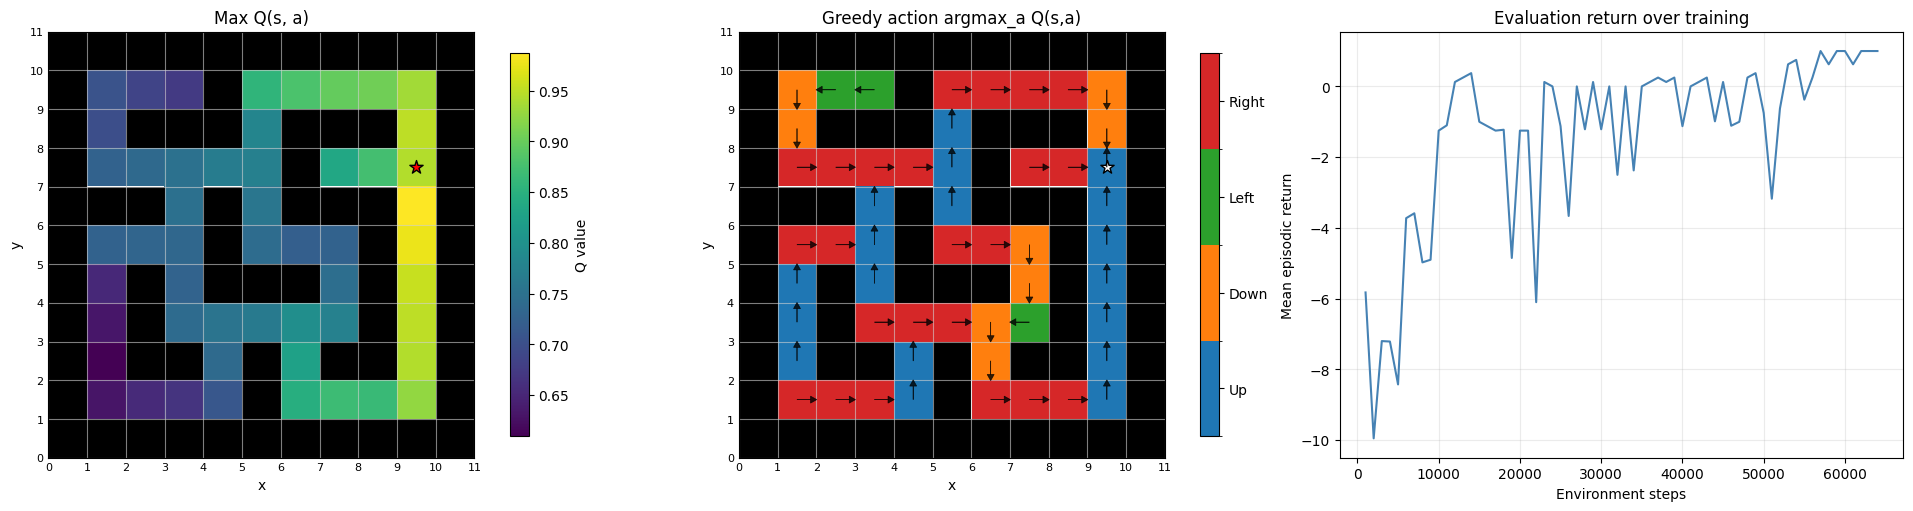

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.2584834 3.5559835 3.3516014 2.5885377 1.8983837]
cumulative variance (first 5 dims): [0.37256044 0.54293126 0.69428056 0.78455913 0.8331152 ]
cos(phi(s,a), psi/task): mean=0.7281, std=0.1130


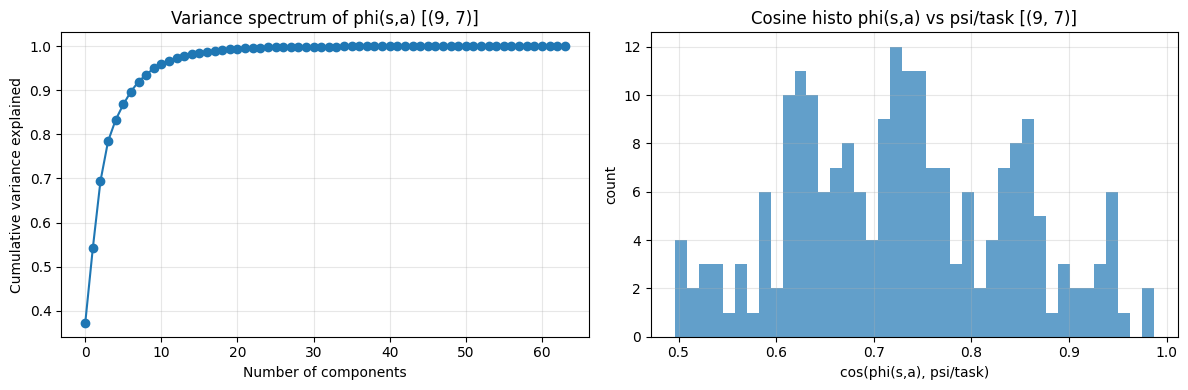


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434      0.375      0.672
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443      0.436      0.457      0.142      0.363
  (9, 1)      0.518      0.658      0.523      0.430    

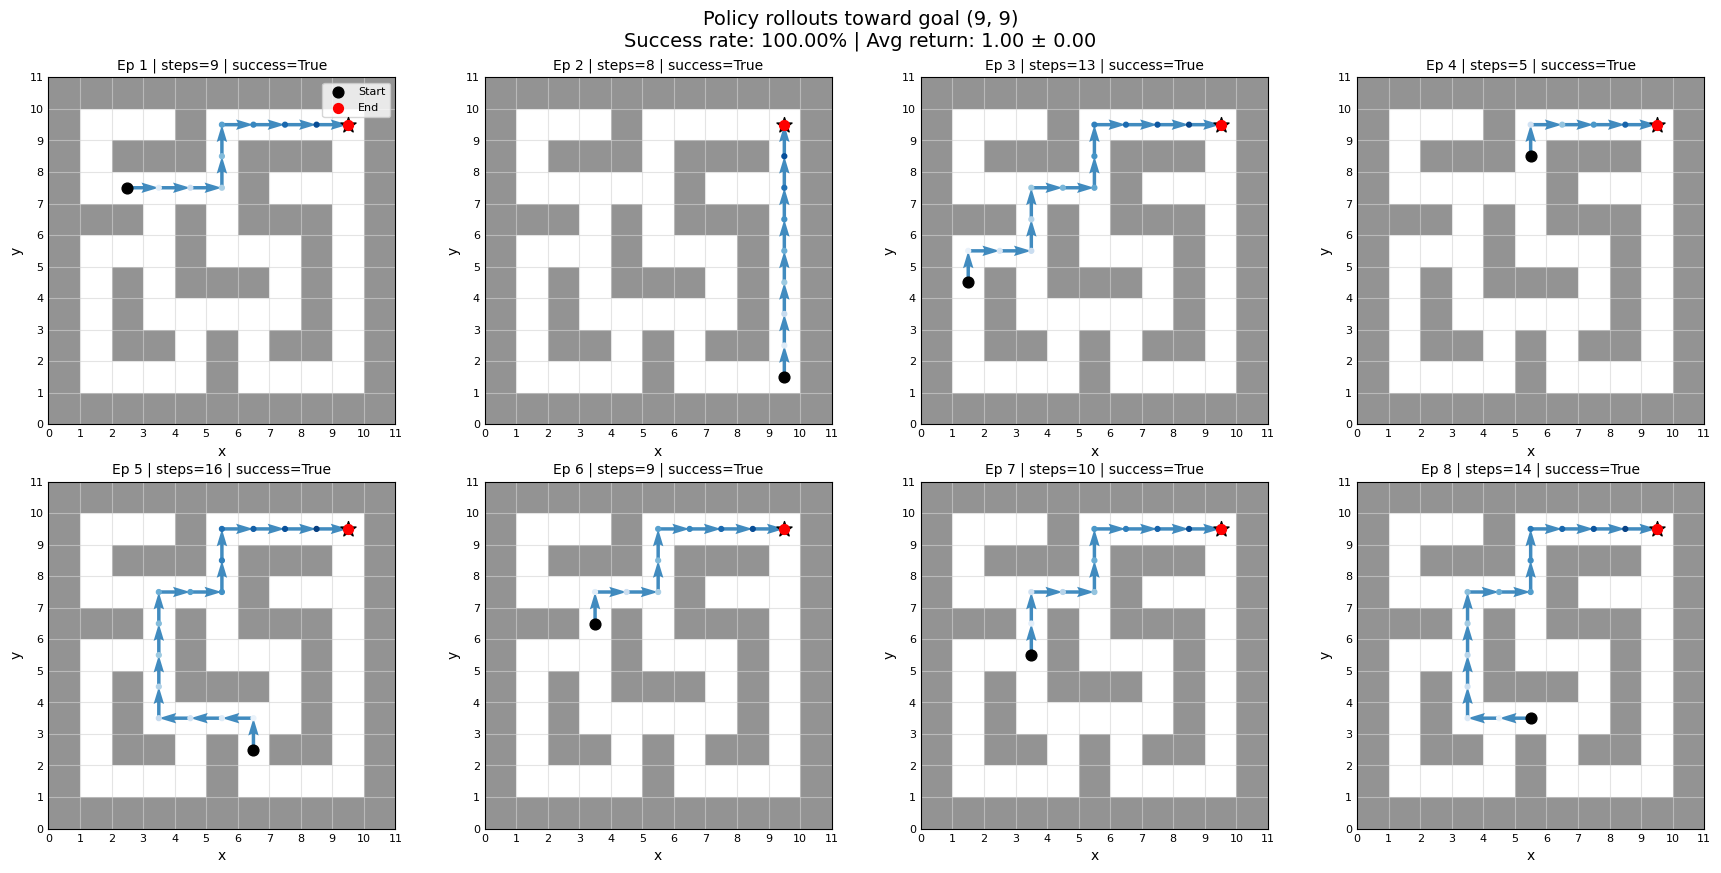

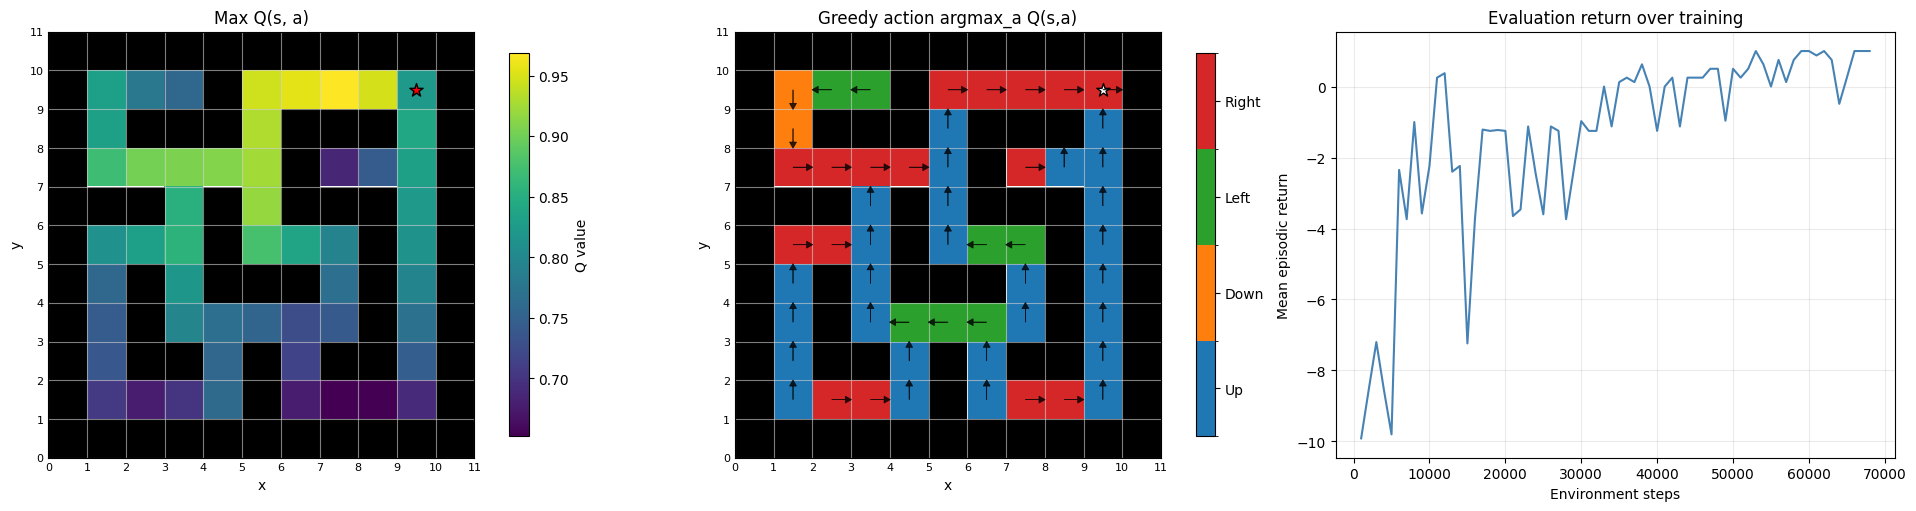

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.745787  3.958146  3.3391974 2.585978  2.4530473]
cumulative variance (first 5 dims): [0.28979945 0.49138746 0.63485885 0.7209048  0.7983319 ]
cos(phi(s,a), psi/task): mean=0.7315, std=0.0995


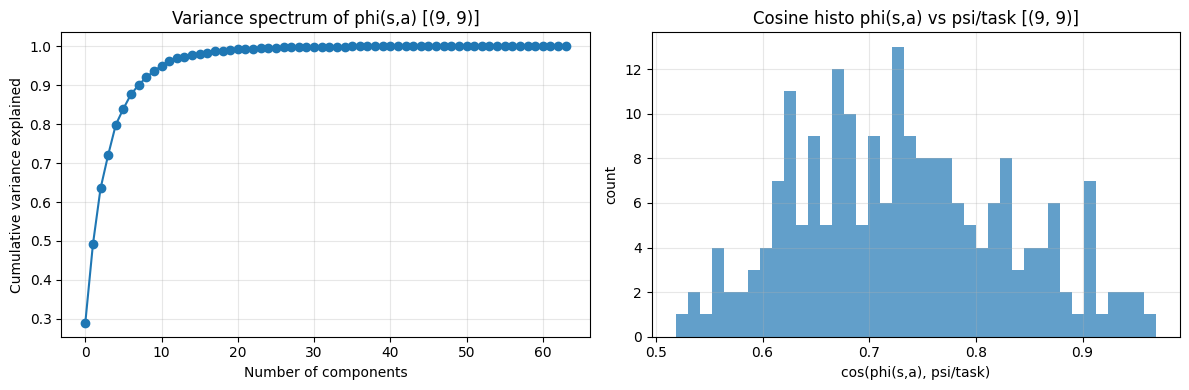


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434      0.375      0.672      0.644
  (3, 6)      0.232      0.480      0.458      0.229      0.257      1.000      0.443      0.436      0.457      0.142  

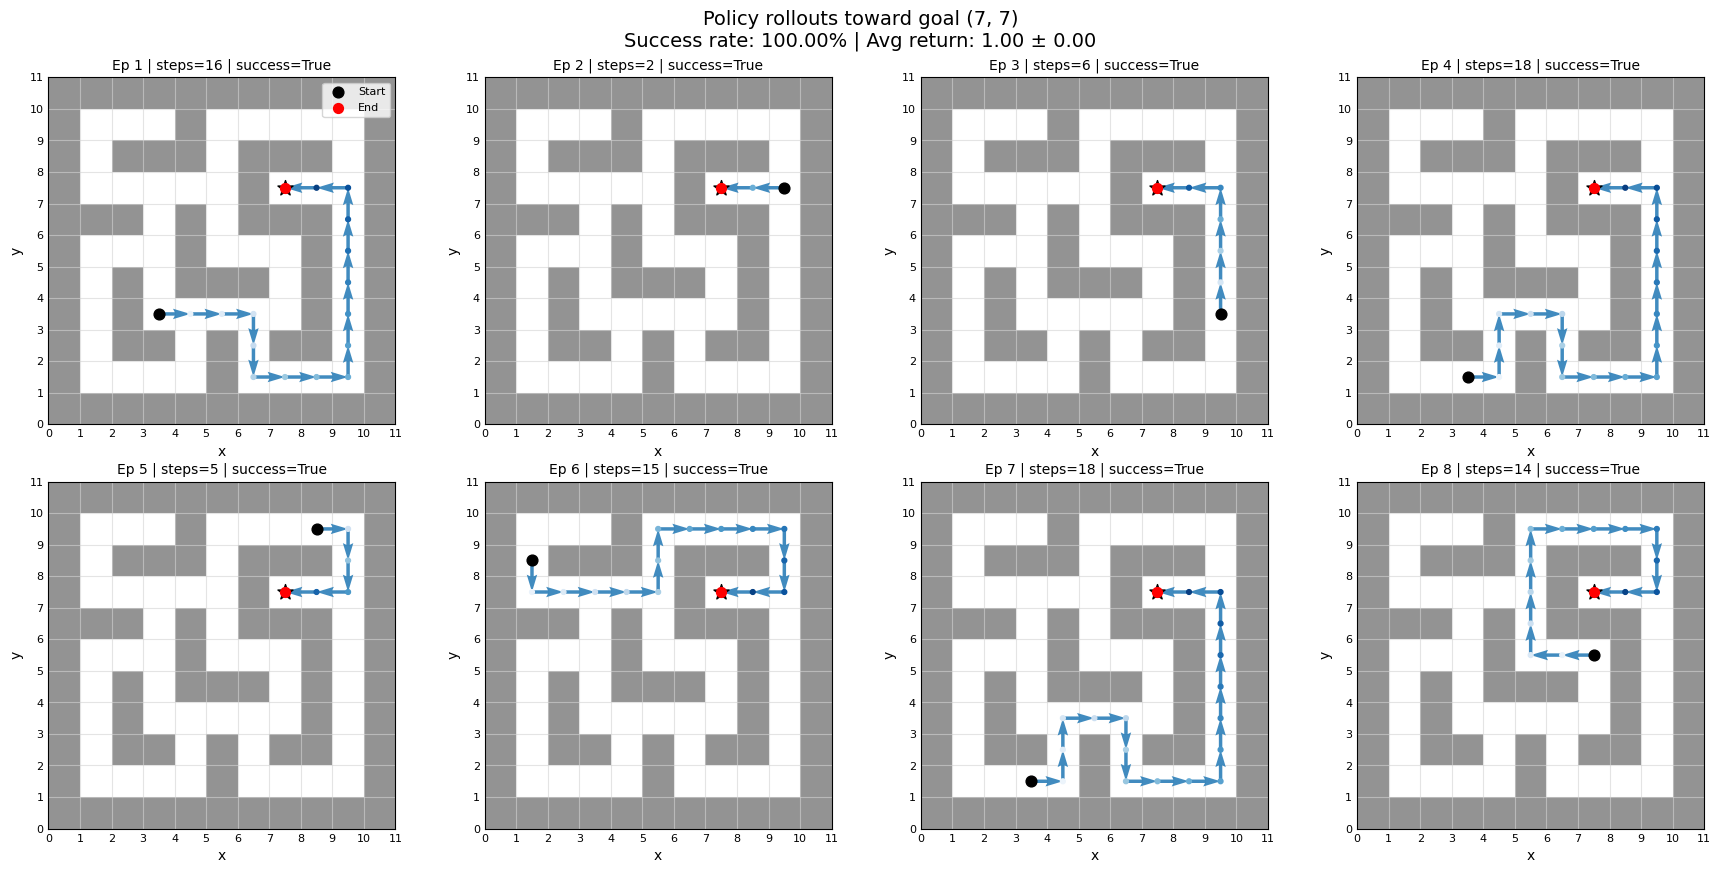

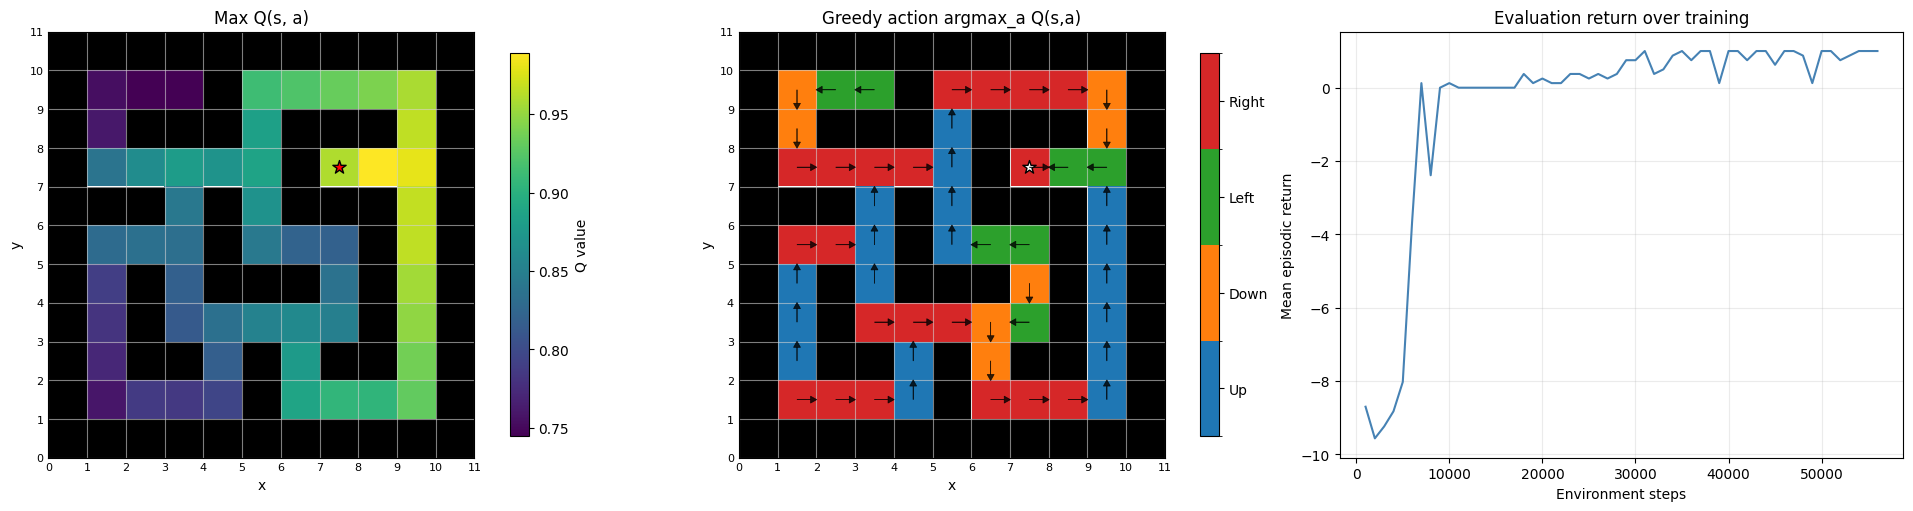

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.3008814 3.2758477 3.0636754 2.3766332 2.1026165]
cumulative variance (first 5 dims): [0.29318112 0.4632671  0.6120341  0.7015593  0.77163076]
cos(phi(s,a), psi/task): mean=0.8065, std=0.0820


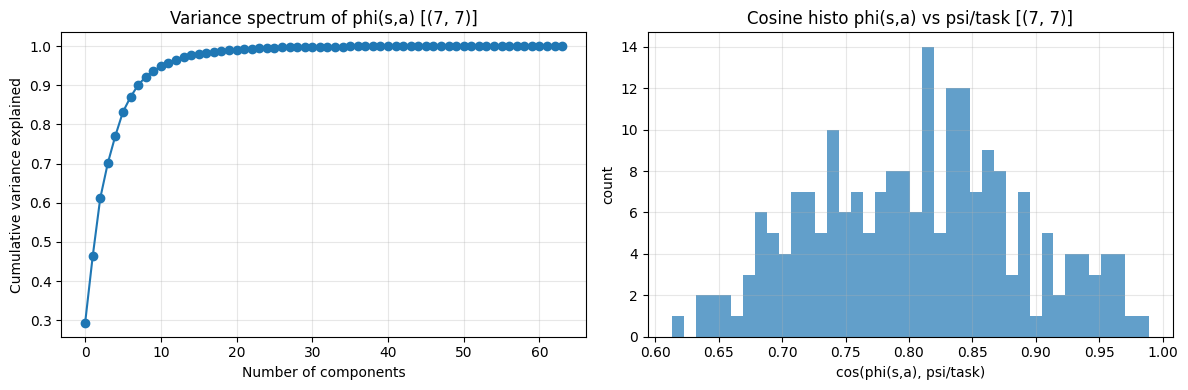


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491      0.524
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434      0.375      0.672      0.644      0.646
  (3, 6)      0.232      0.480      0.458      0.229  

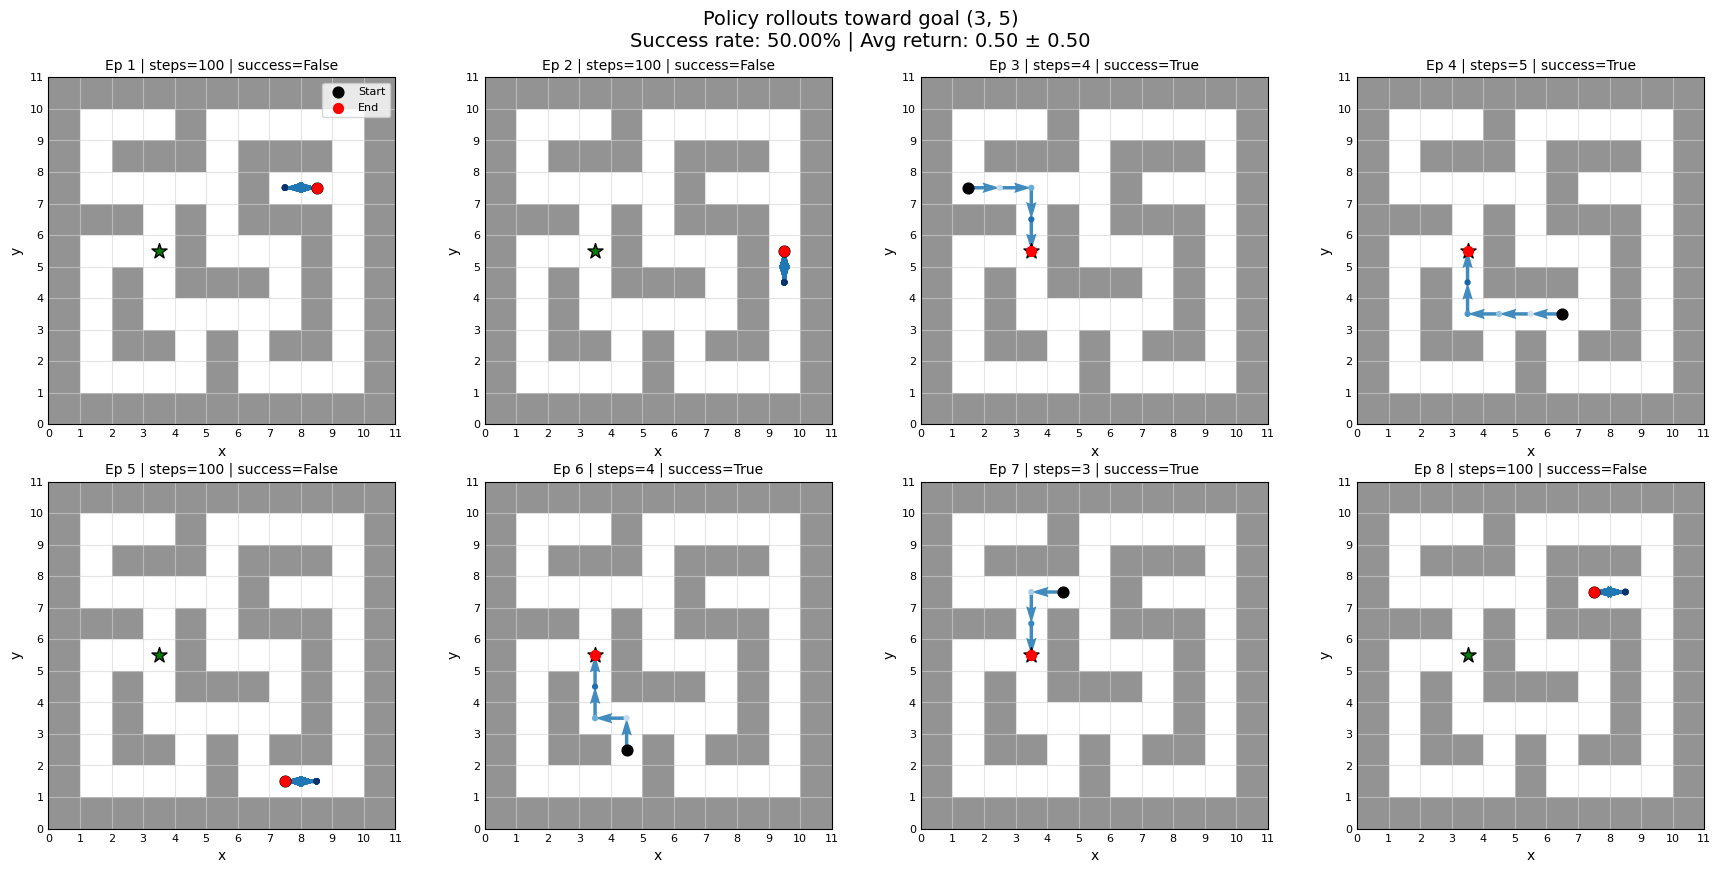

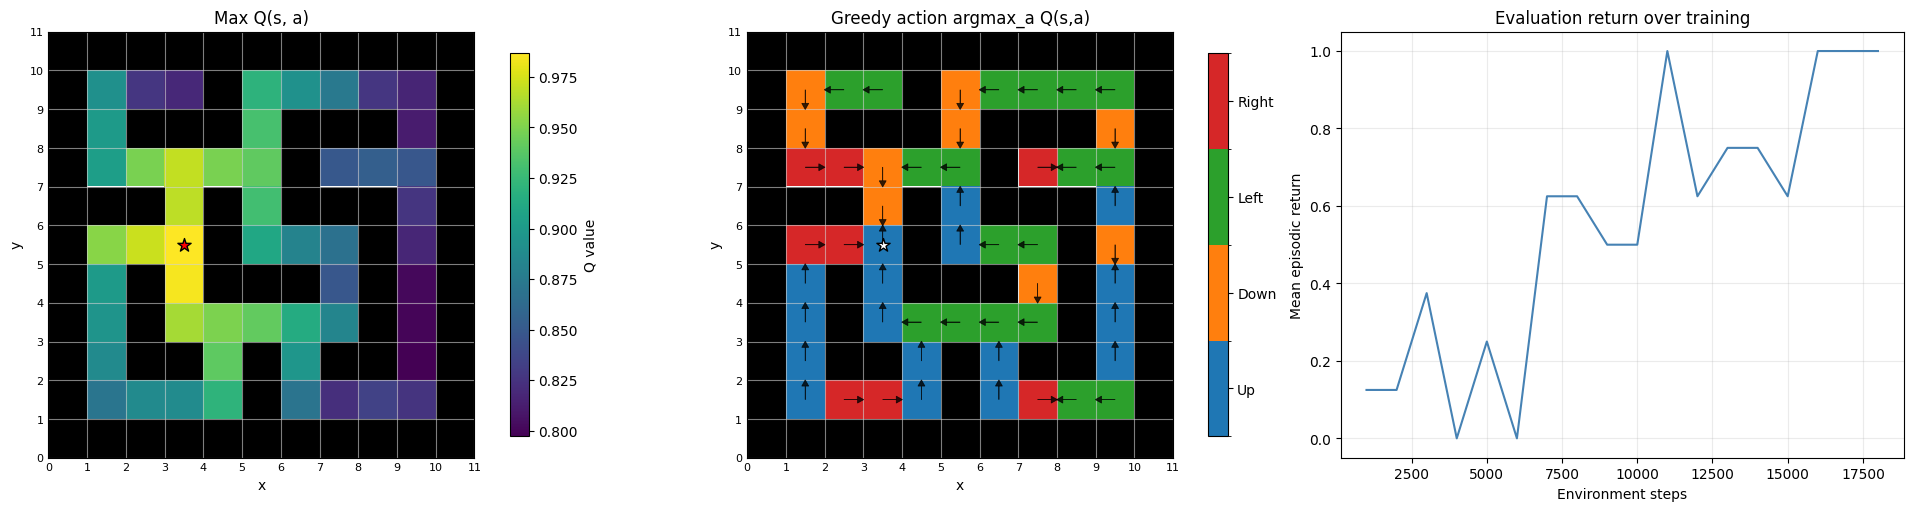

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.8447475 3.6522574 2.9496958 2.1948066 2.1638606]
cumulative variance (first 5 dims): [0.24592136 0.46783468 0.6125835  0.6927242  0.77062094]
cos(phi(s,a), psi/task): mean=0.8269, std=0.0729


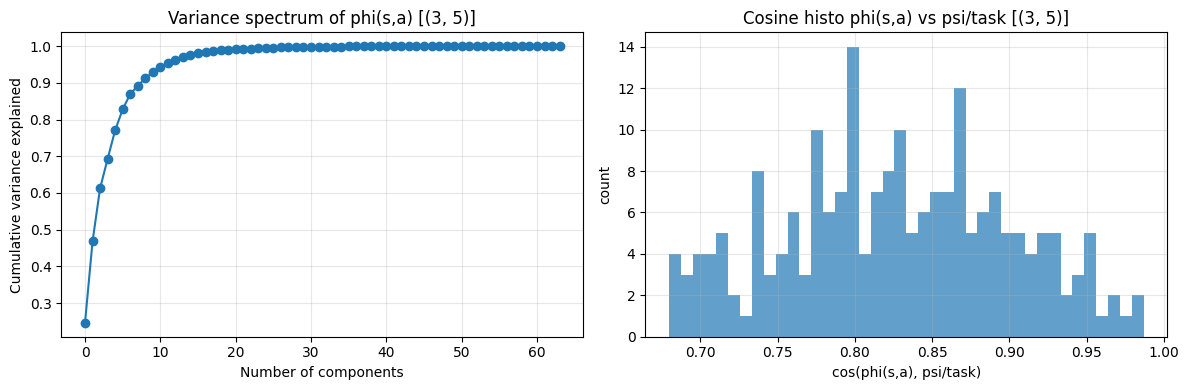


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491      0.524      0.485
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573      0.434      0.375      0.672      0.644      0.646

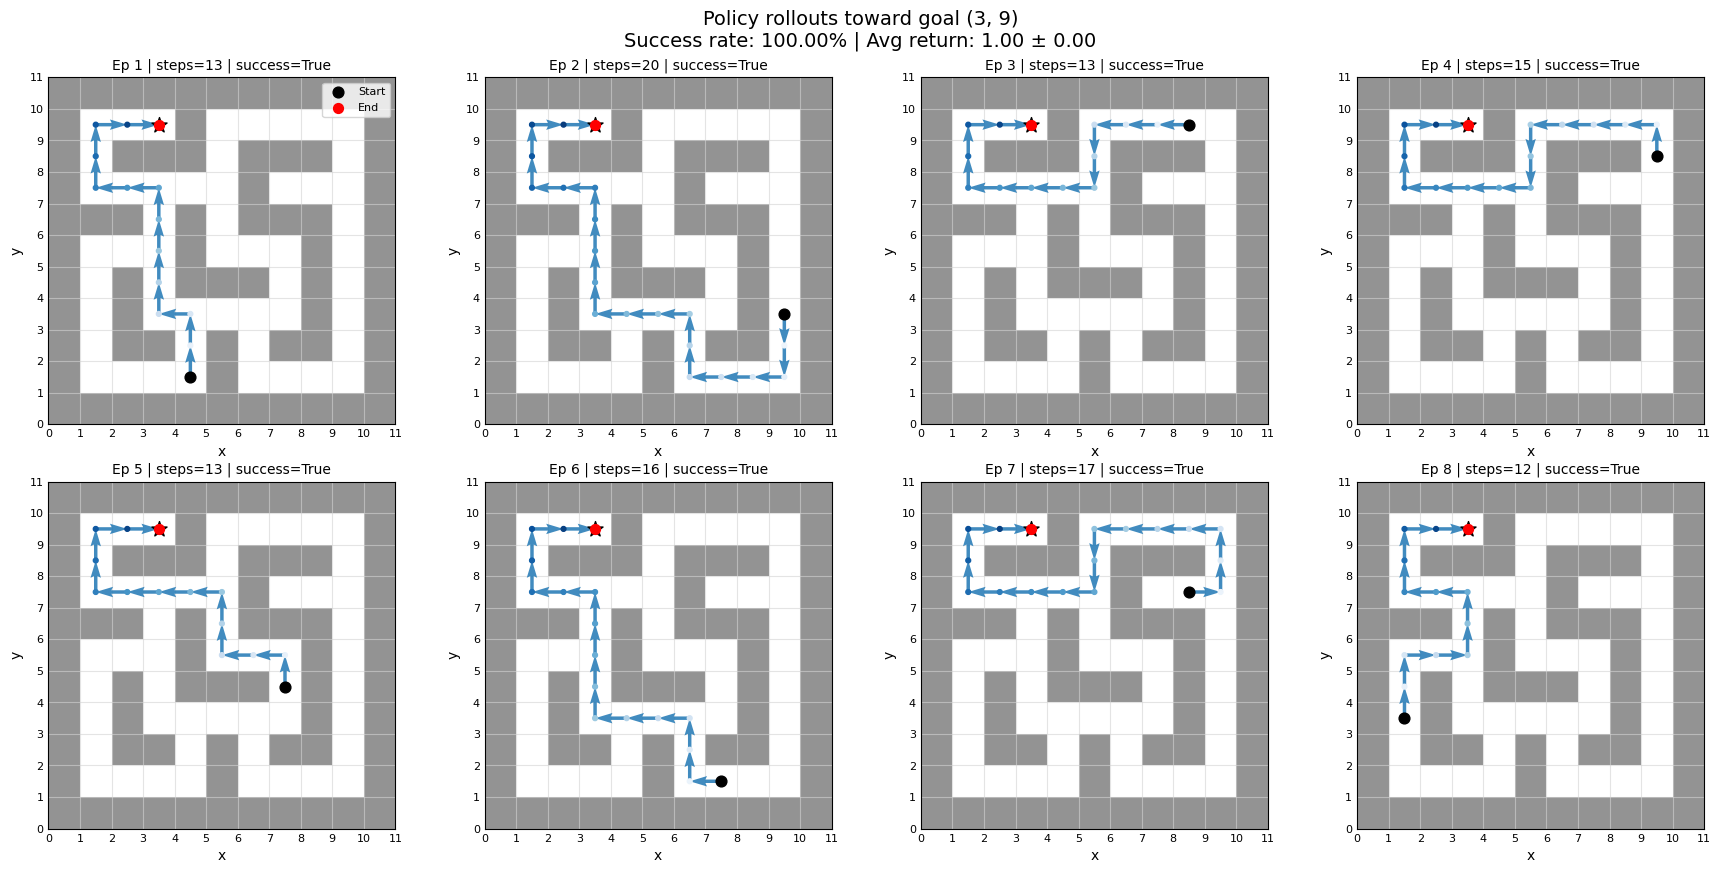

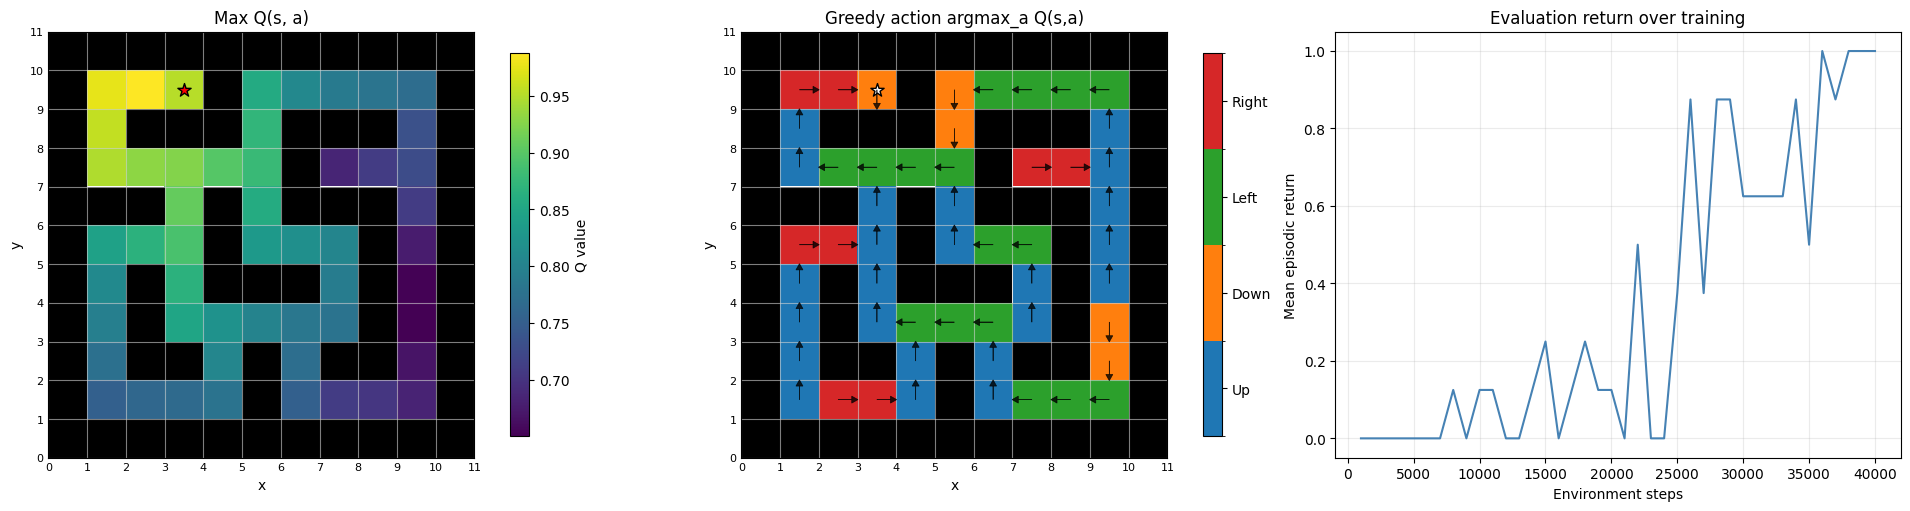

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.705545  3.9513085 3.2671173 2.790525  2.5327358]
cumulative variance (first 5 dims): [0.26890337 0.45851207 0.58814216 0.682711   0.7606144 ]
cos(phi(s,a), psi/task): mean=0.7414, std=0.1029


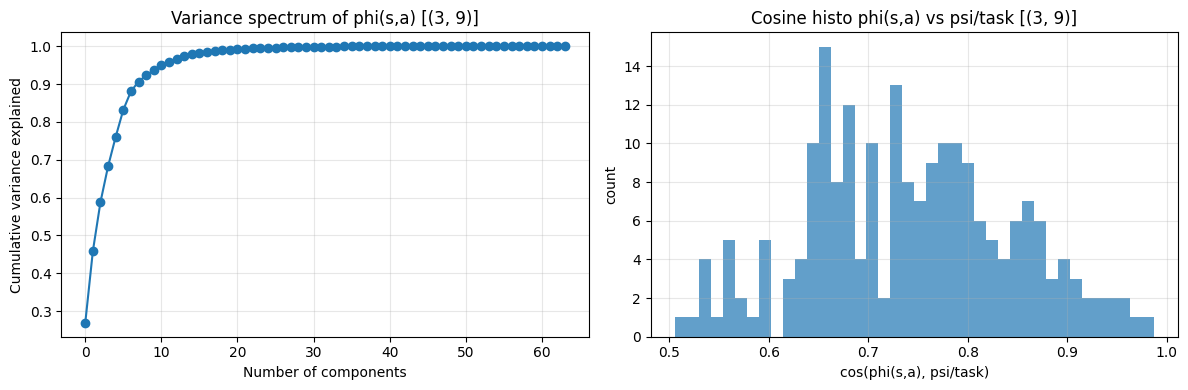


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491      0.524      0.485      0.474
  (5, 5)      0.495      0.544      0.289      0.506      1.000      0.257      0.653      0.573

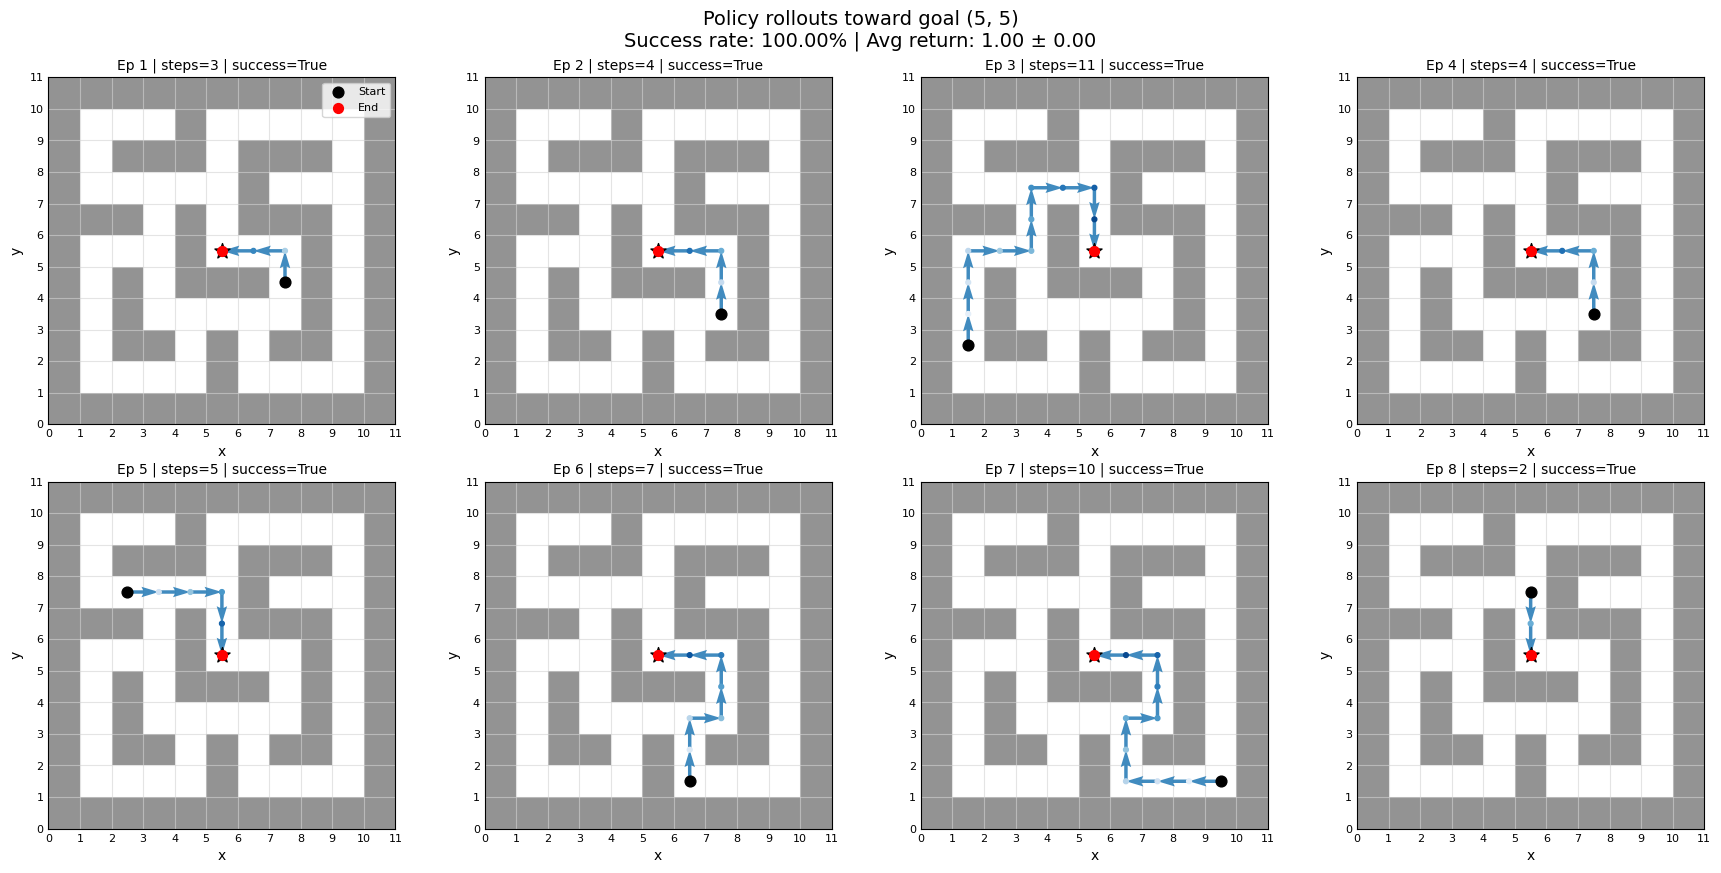

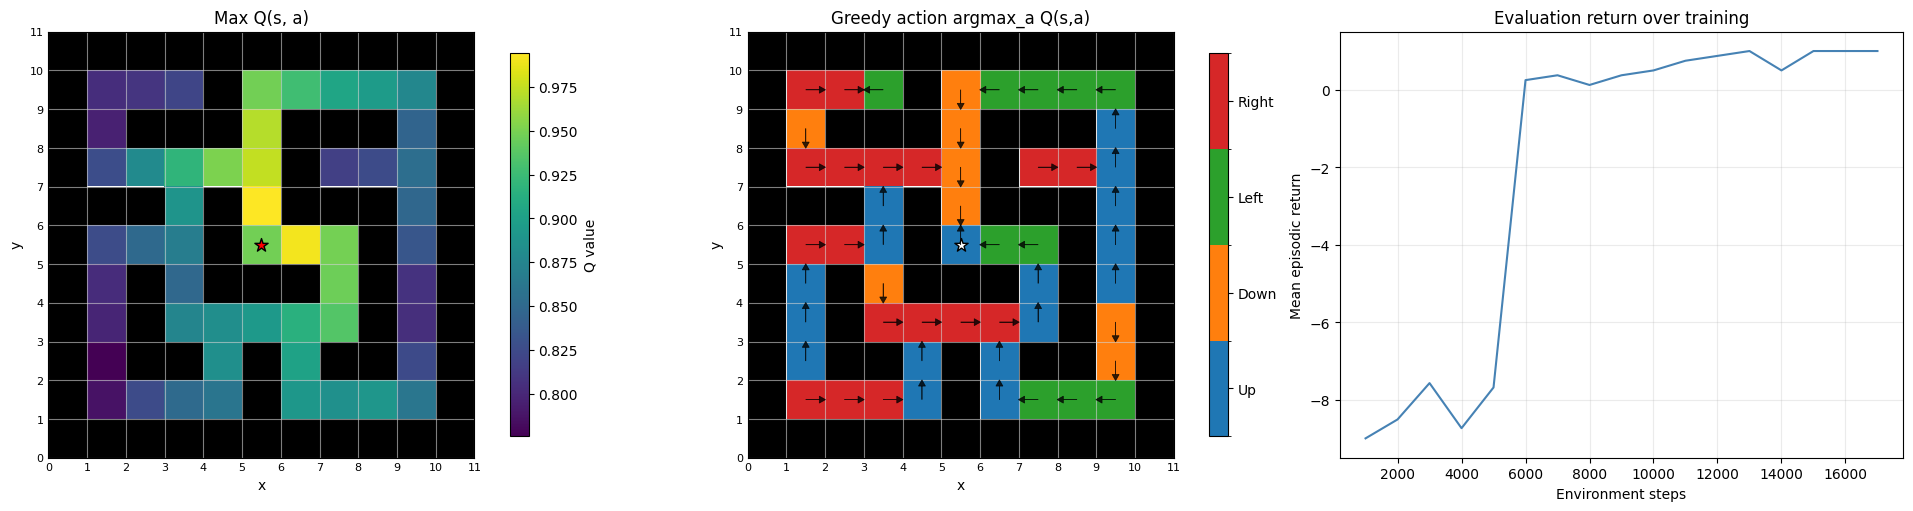

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9874415 3.768513  2.9925675 2.6058245 2.4792342]
cumulative variance (first 5 dims): [0.23572768 0.44628096 0.579054   0.67972684 0.7708559 ]
cos(phi(s,a), psi/task): mean=0.8105, std=0.0772


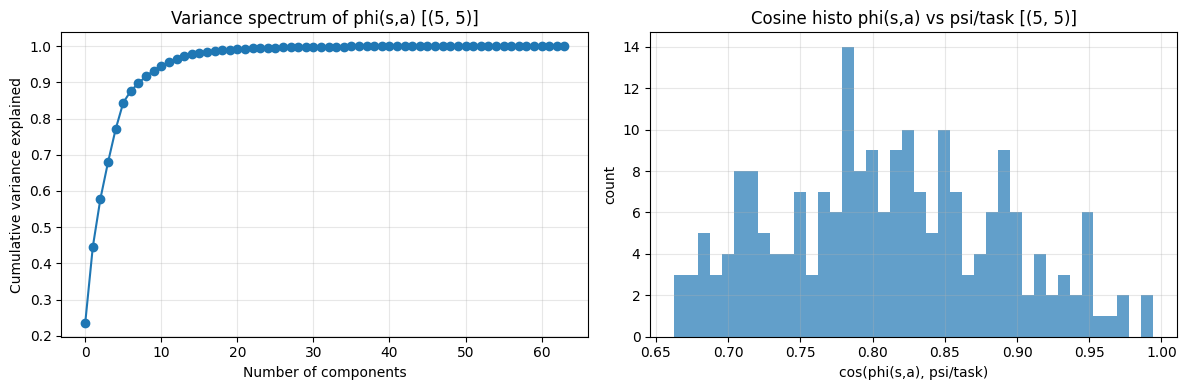


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491      0.524      0.485      0.474      0.446
  (5, 5)      0.495      0.544      0.289

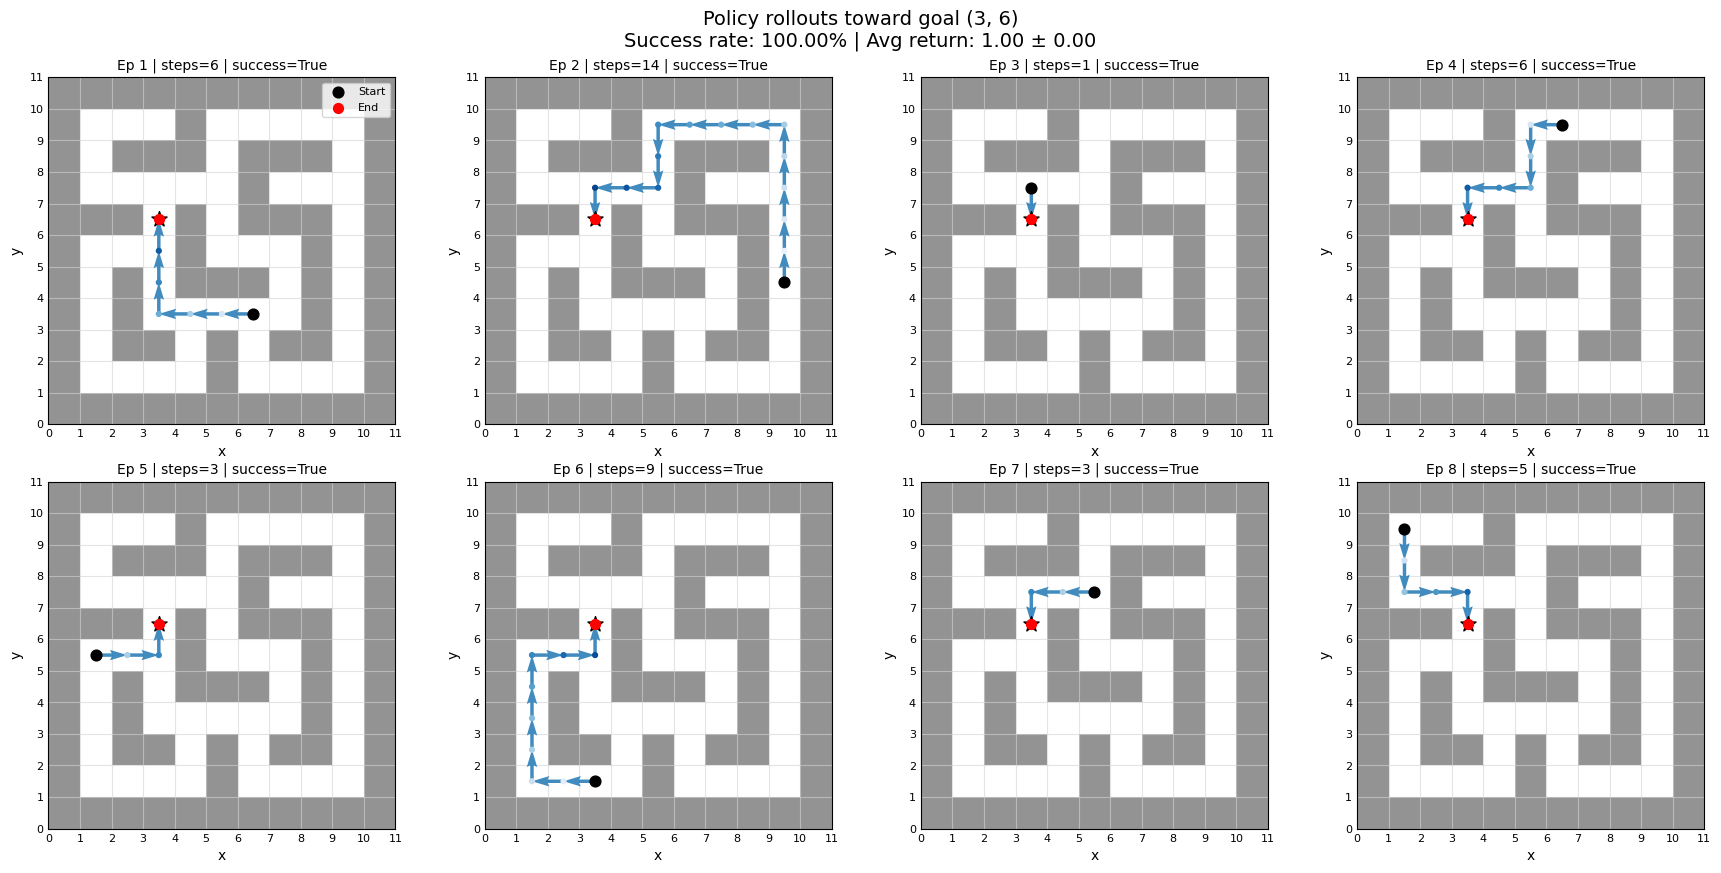

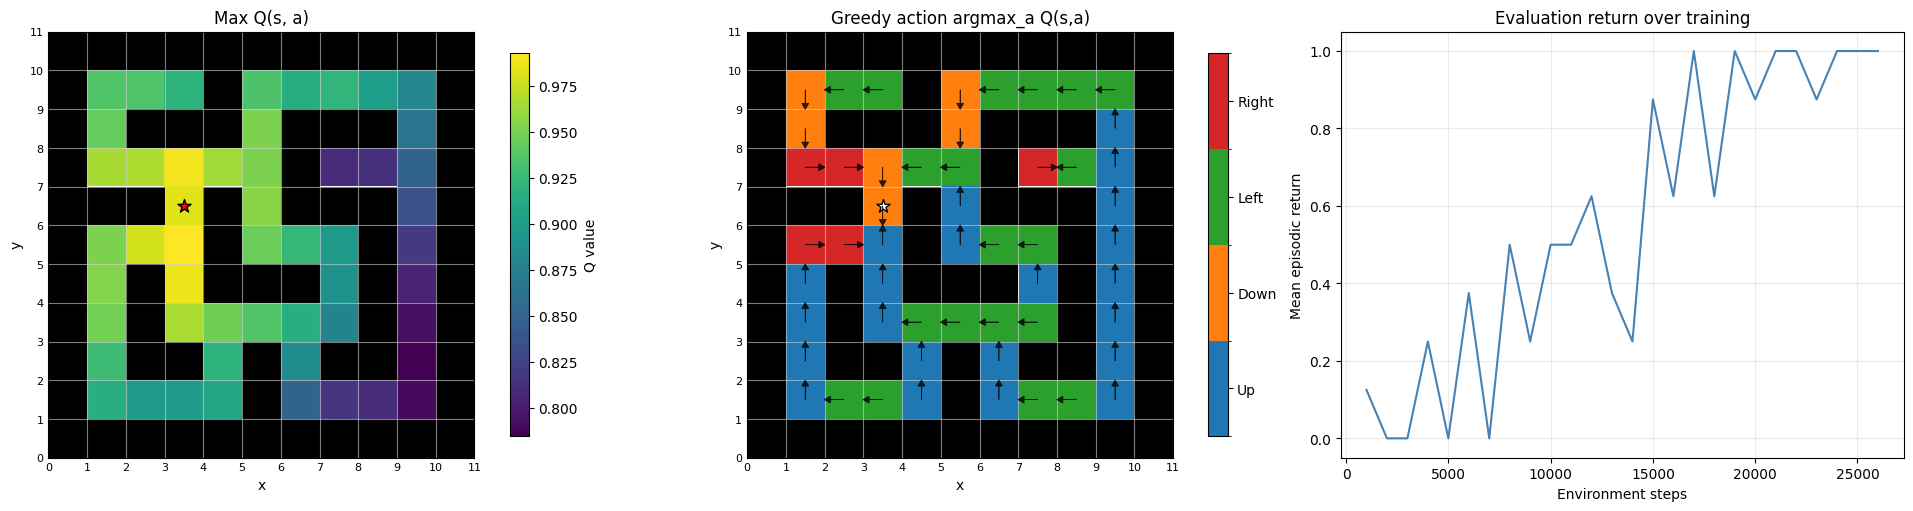

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.9181843 3.1366014 2.6512332 2.3081203 2.1493645]
cumulative variance (first 5 dims): [0.27693933 0.45441288 0.5812104  0.67731225 0.7606487 ]
cos(phi(s,a), psi/task): mean=0.8441, std=0.0826


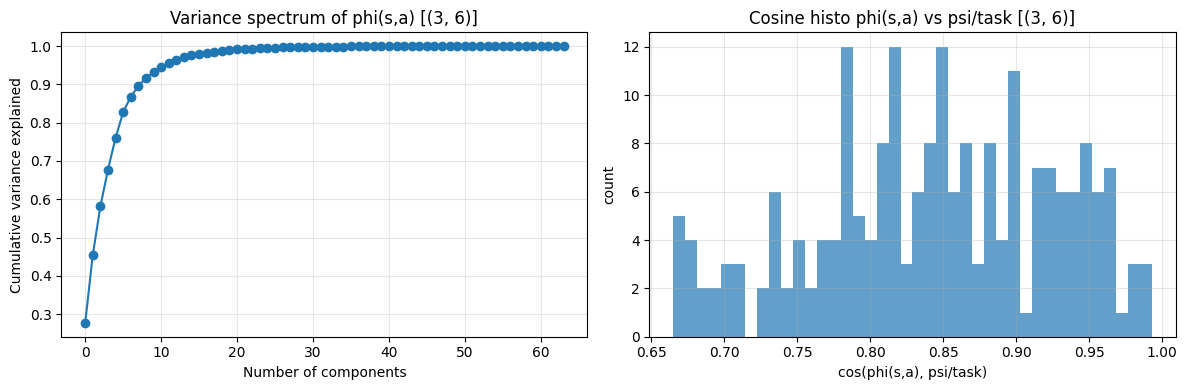


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.491      0.524      0.485      0.474      0.4

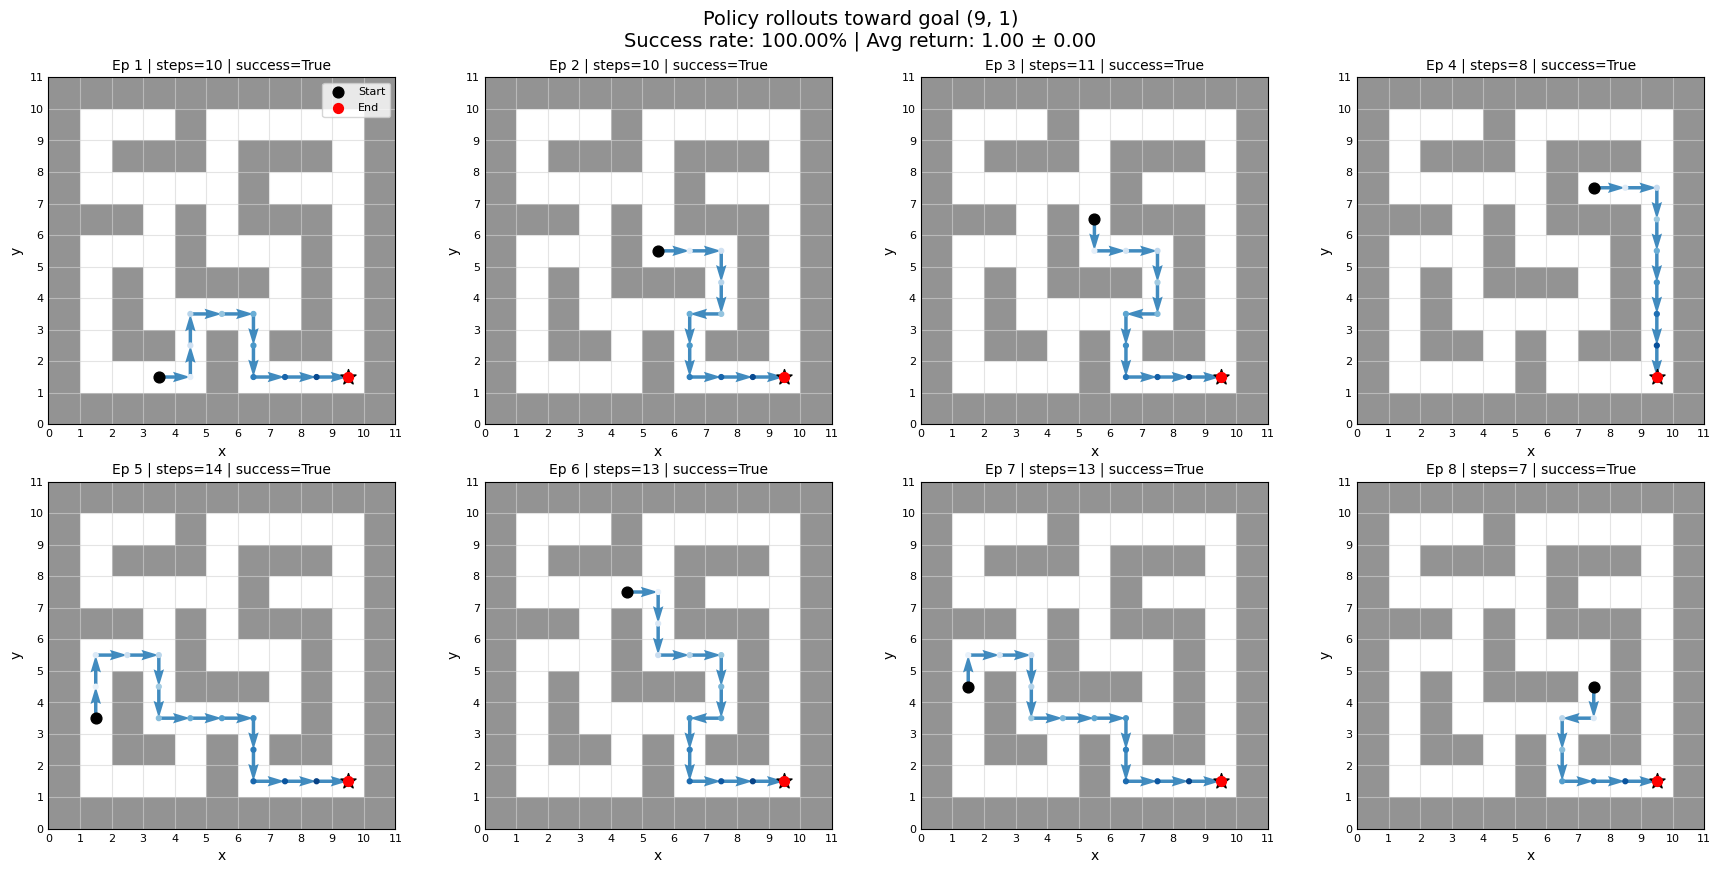

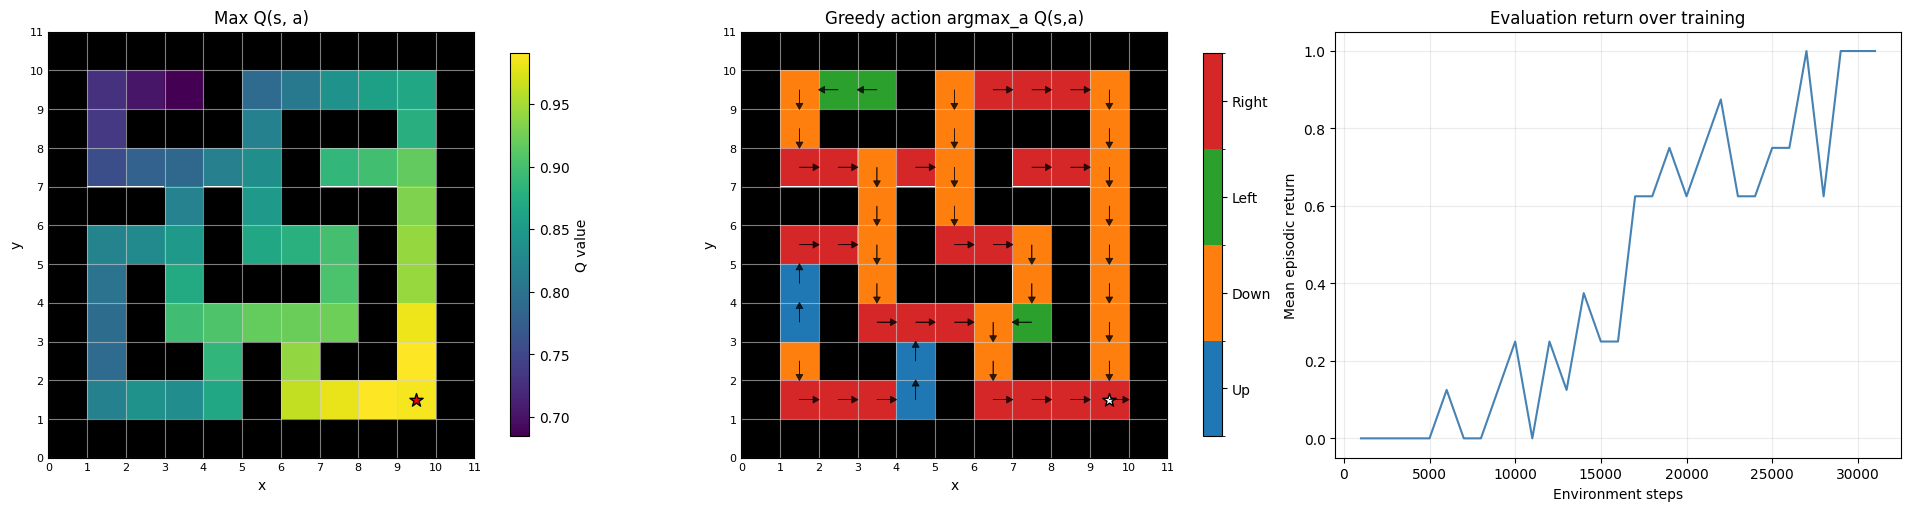

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.642396  3.1438117 3.0492644 2.6945462 2.258865 ]
cumulative variance (first 5 dims): [0.2217882  0.38701373 0.54245067 0.66382736 0.7491265 ]
cos(phi(s,a), psi/task): mean=0.7989, std=0.0914


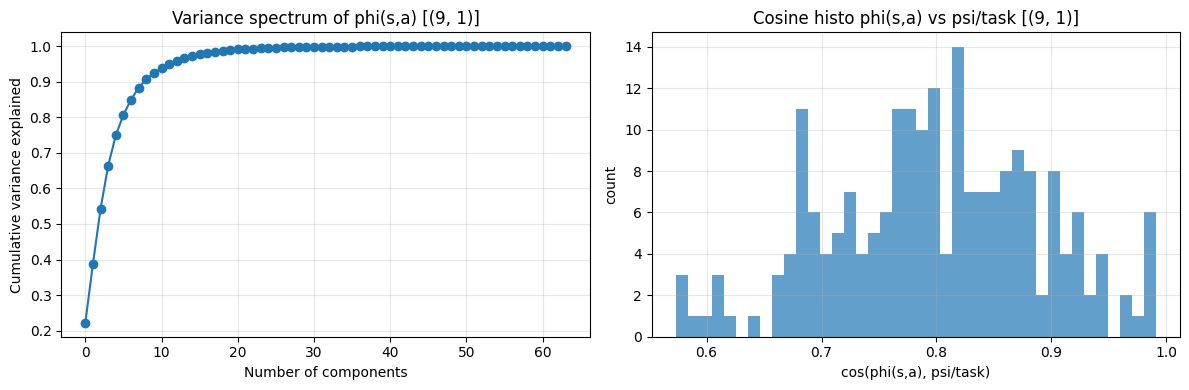


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393      0.387
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.473      0.486      0.434      0.350      0.4

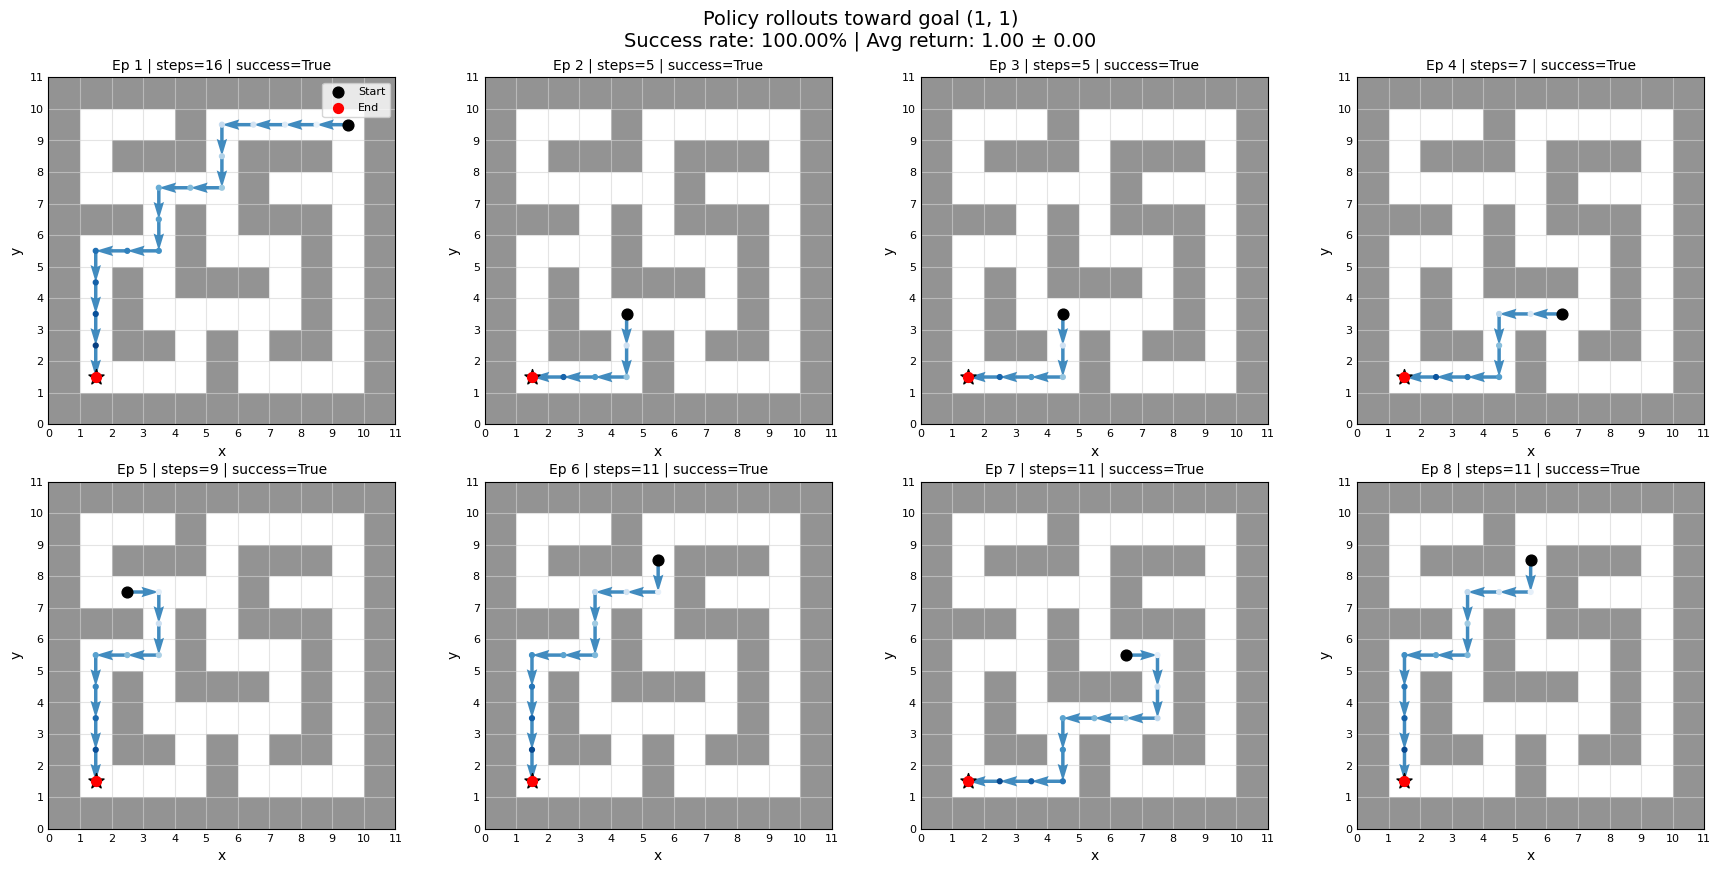

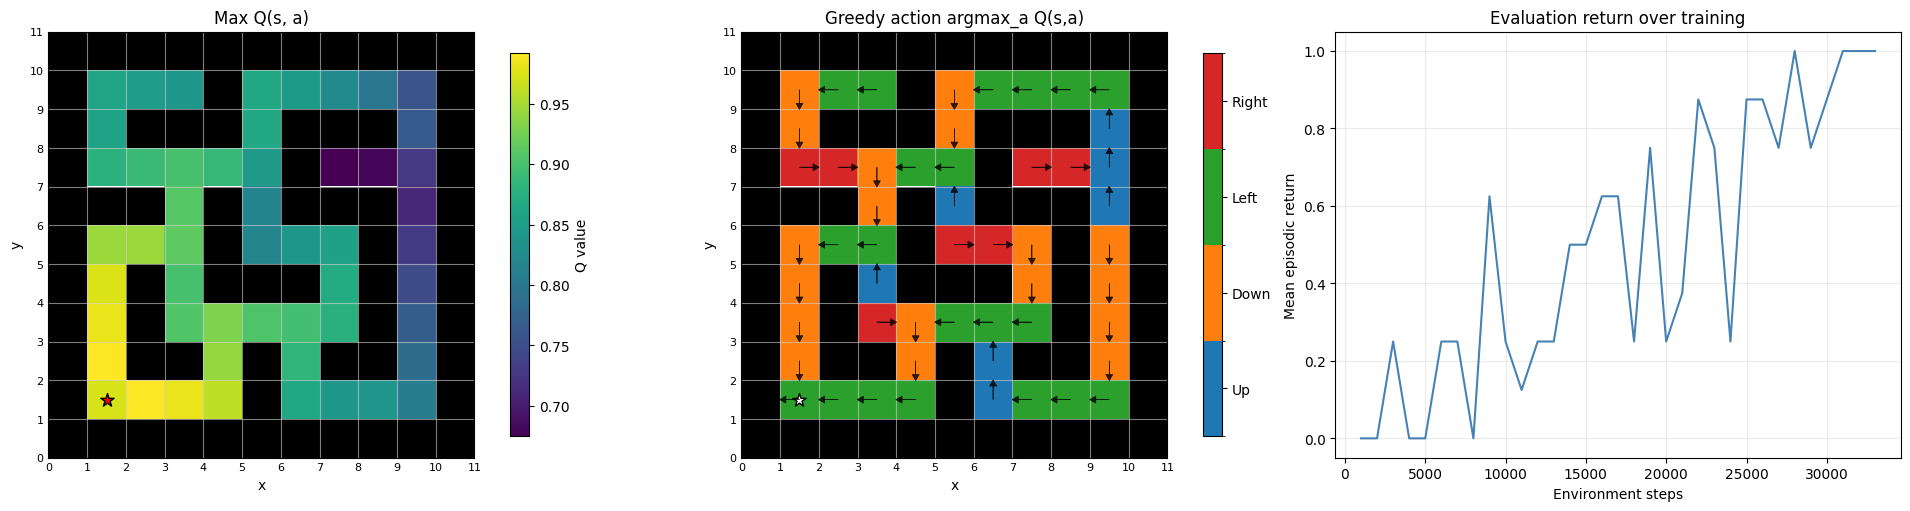

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.845503  3.433324  3.039838  2.5623024 2.2088144]
cumulative variance (first 5 dims): [0.22978954 0.4129592  0.55654943 0.6585693  0.73438203]
cos(phi(s,a), psi/task): mean=0.7988, std=0.0972


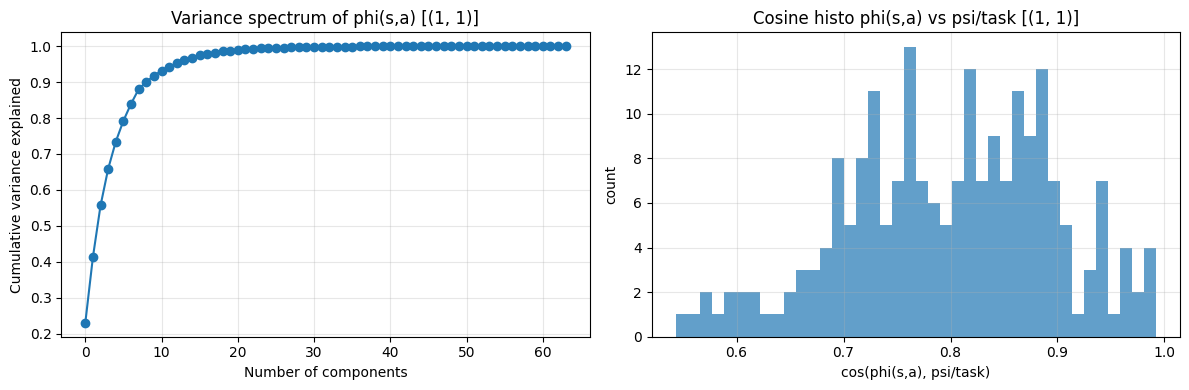


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393      0.387      0.367
  (3, 9)      0.207      0.296      0.099      1.000      0.506      0.229      0.430      0.4

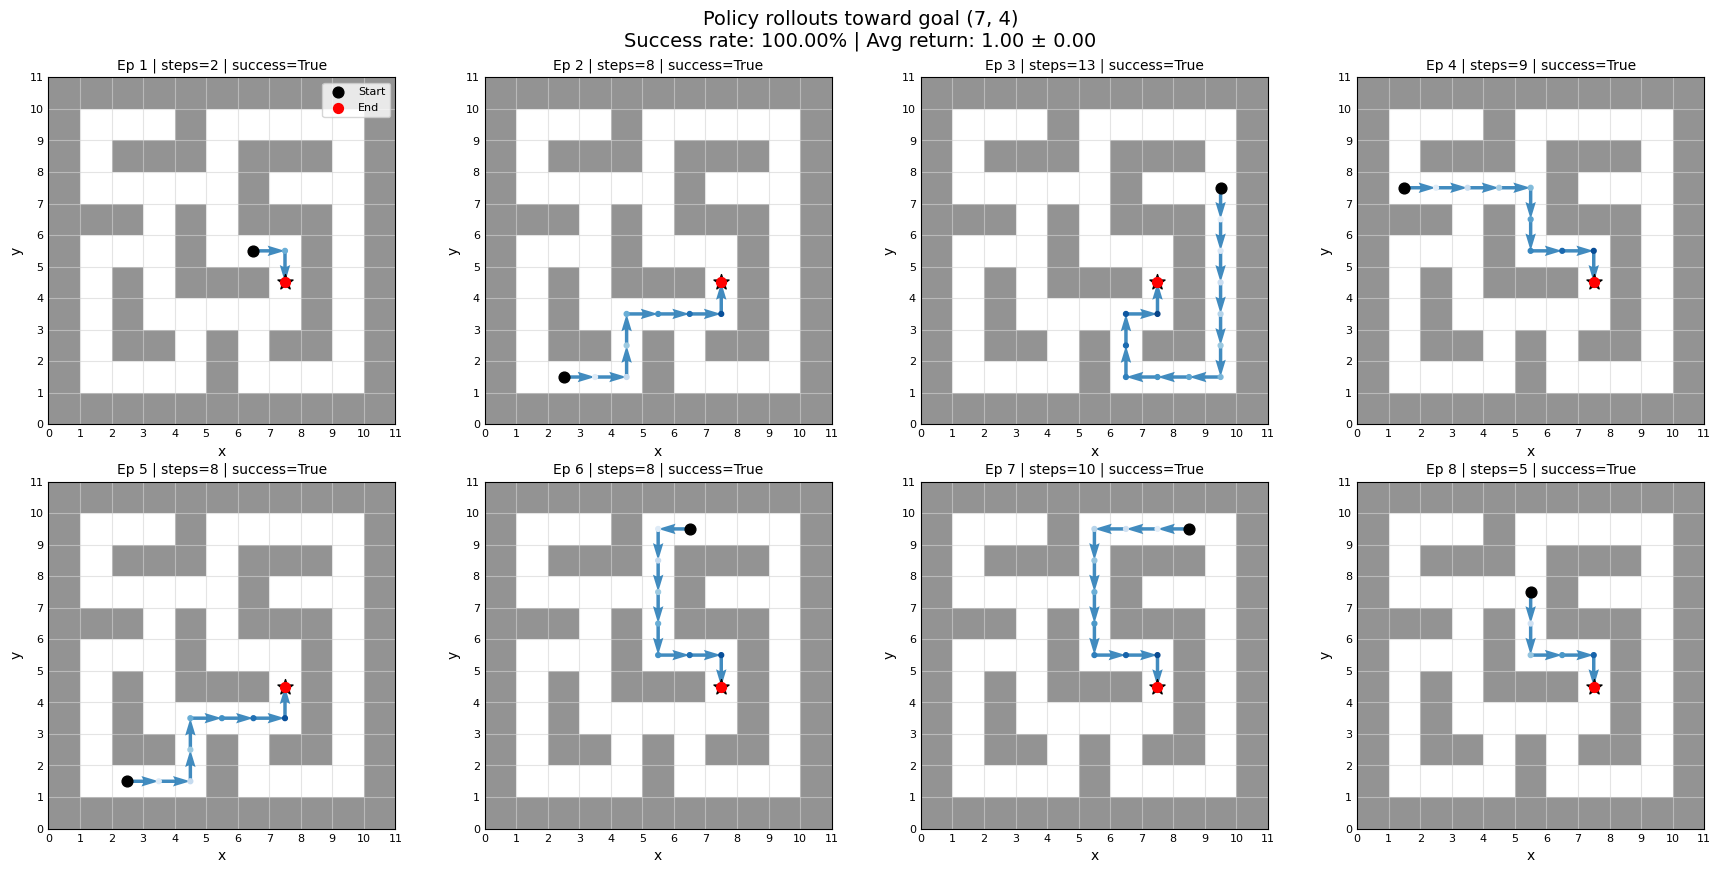

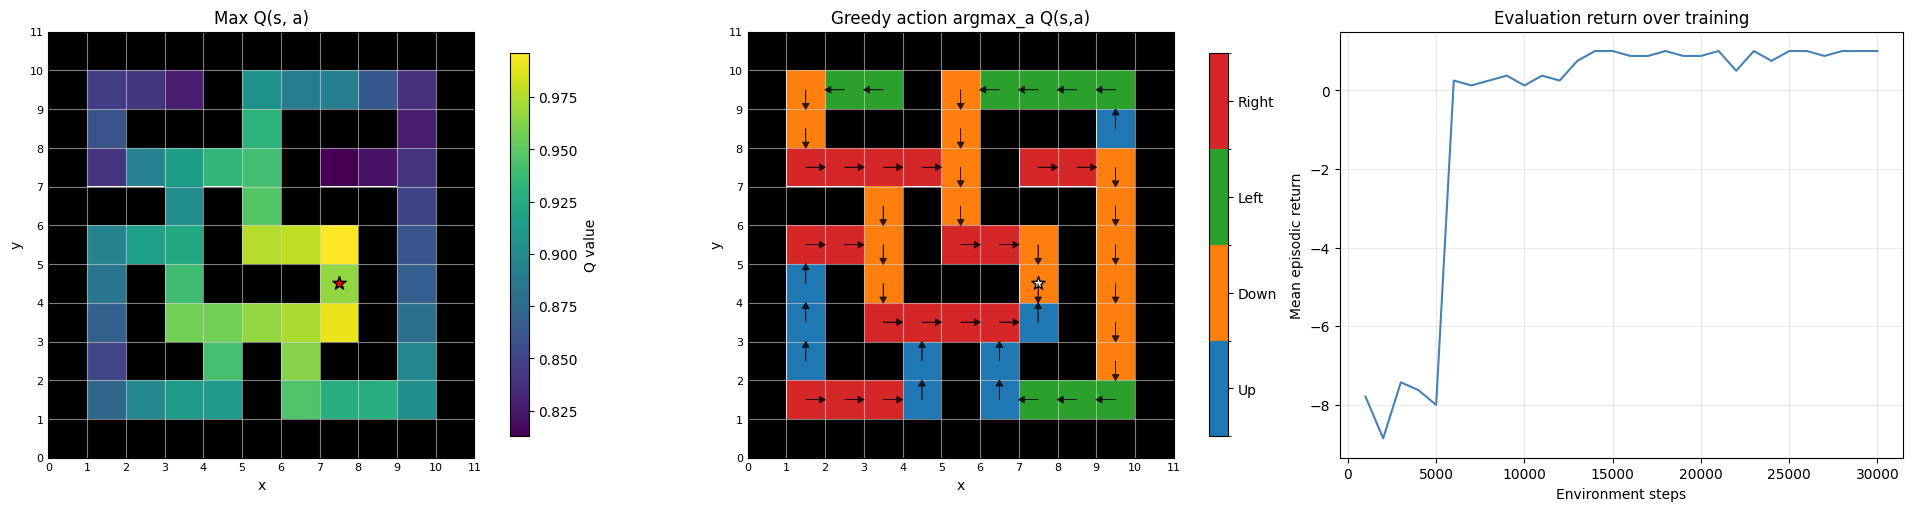

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4281538 3.2348177 2.8233206 2.4714026 2.320769 ]
cumulative variance (first 5 dims): [0.20707749 0.39145666 0.5319102  0.63953173 0.7344339 ]
cos(phi(s,a), psi/task): mean=0.8432, std=0.0725


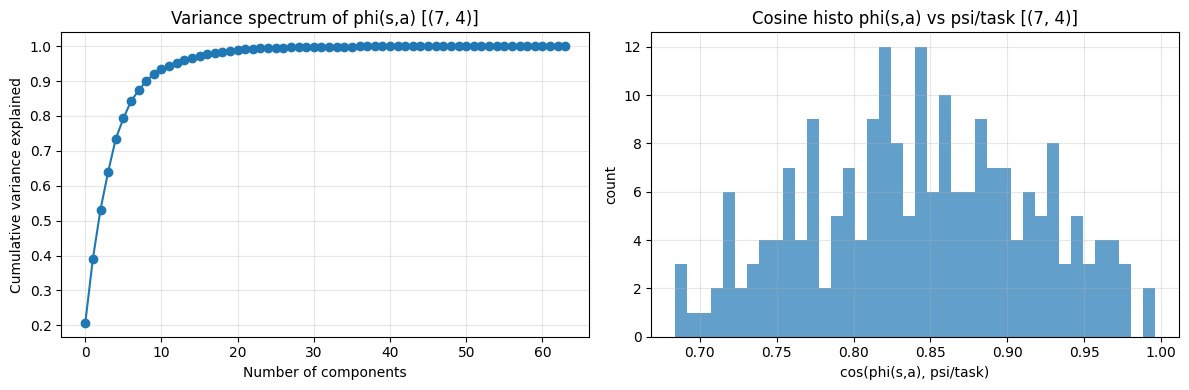


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393      0.387      0.367      0.393
  (3, 9)      0.207      0.296      0.099      1.0

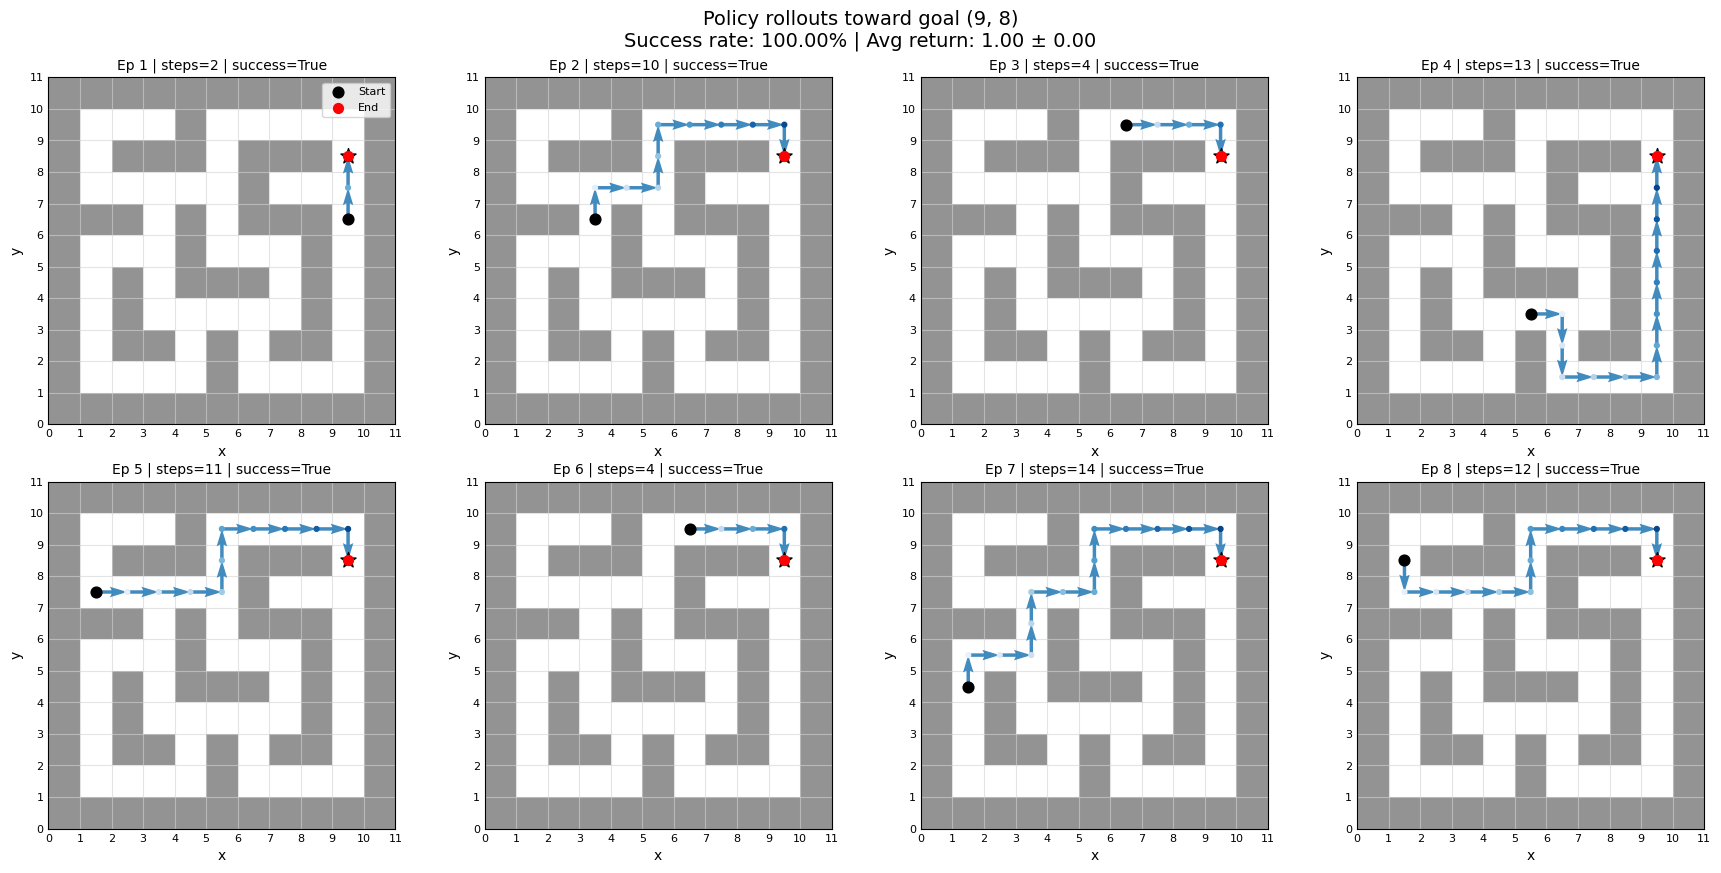

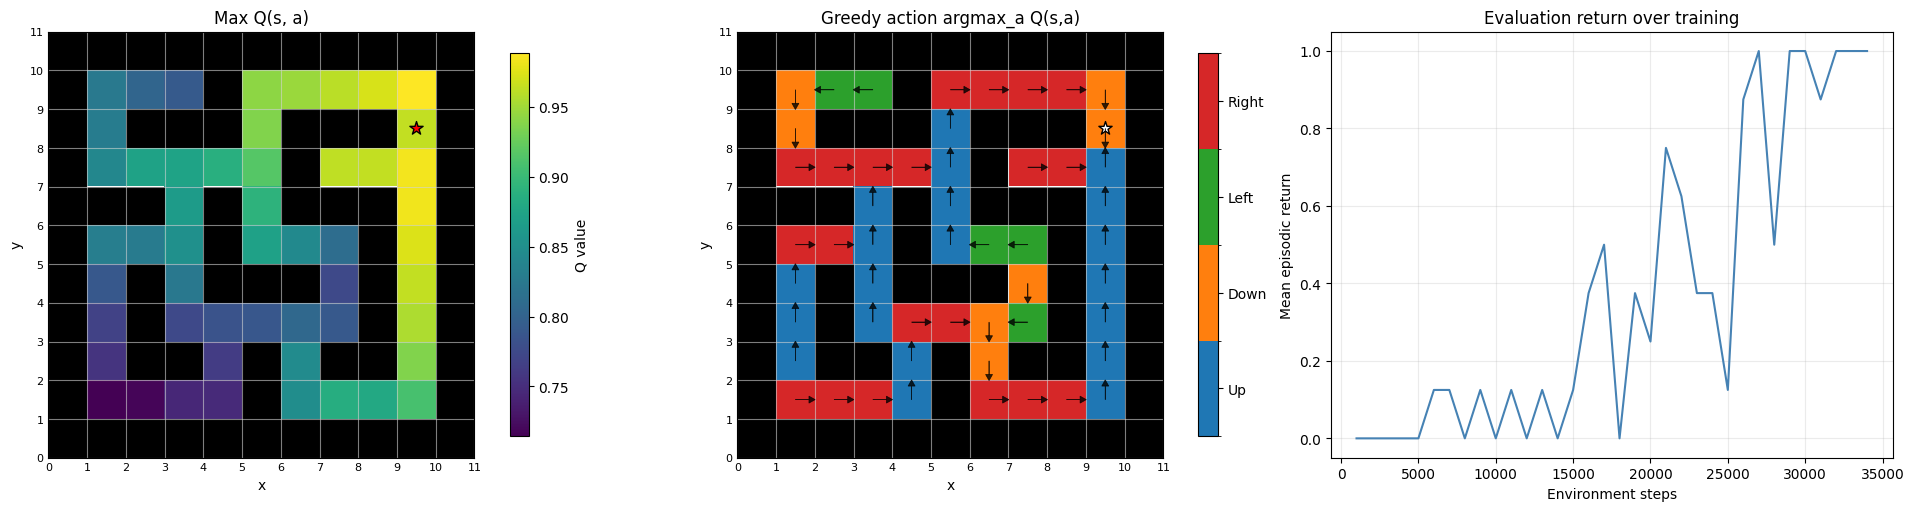

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.111381  3.432628  2.869364  2.5734582 2.380082 ]
cumulative variance (first 5 dims): [0.2537322  0.43060195 0.55418855 0.6535995  0.7386318 ]
cos(phi(s,a), psi/task): mean=0.7954, std=0.0960


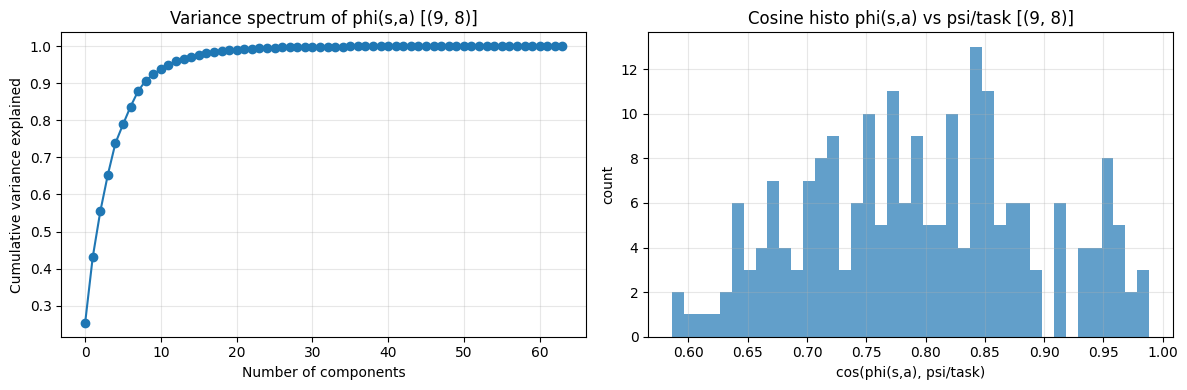


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393      0.387      0.367      0.393      0.406
  (3, 

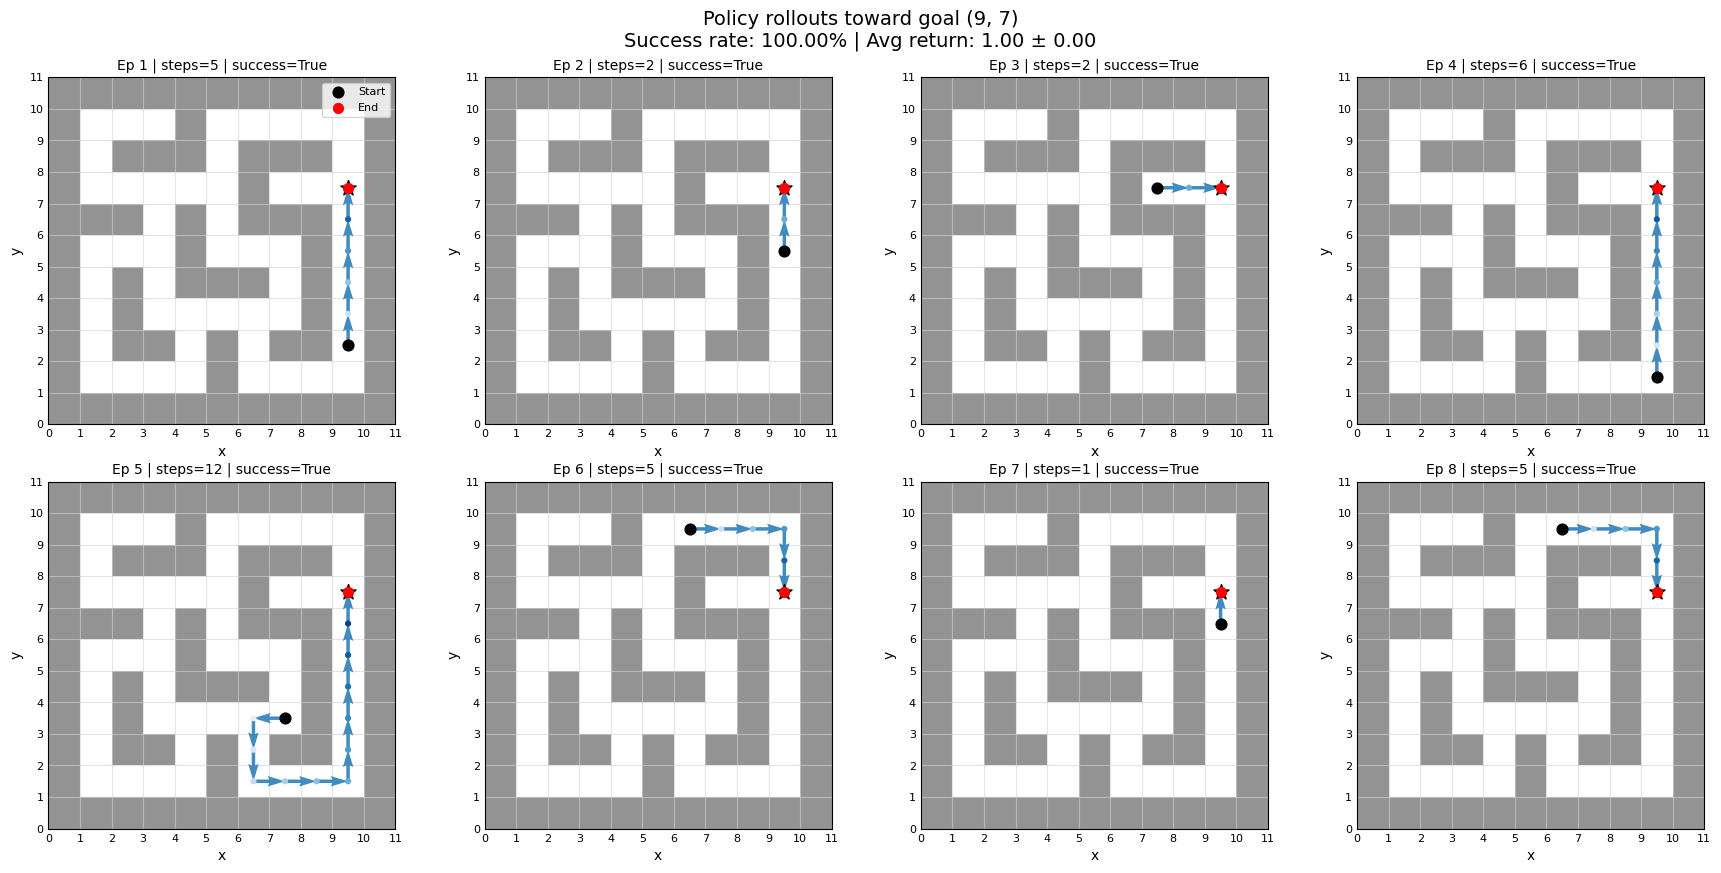

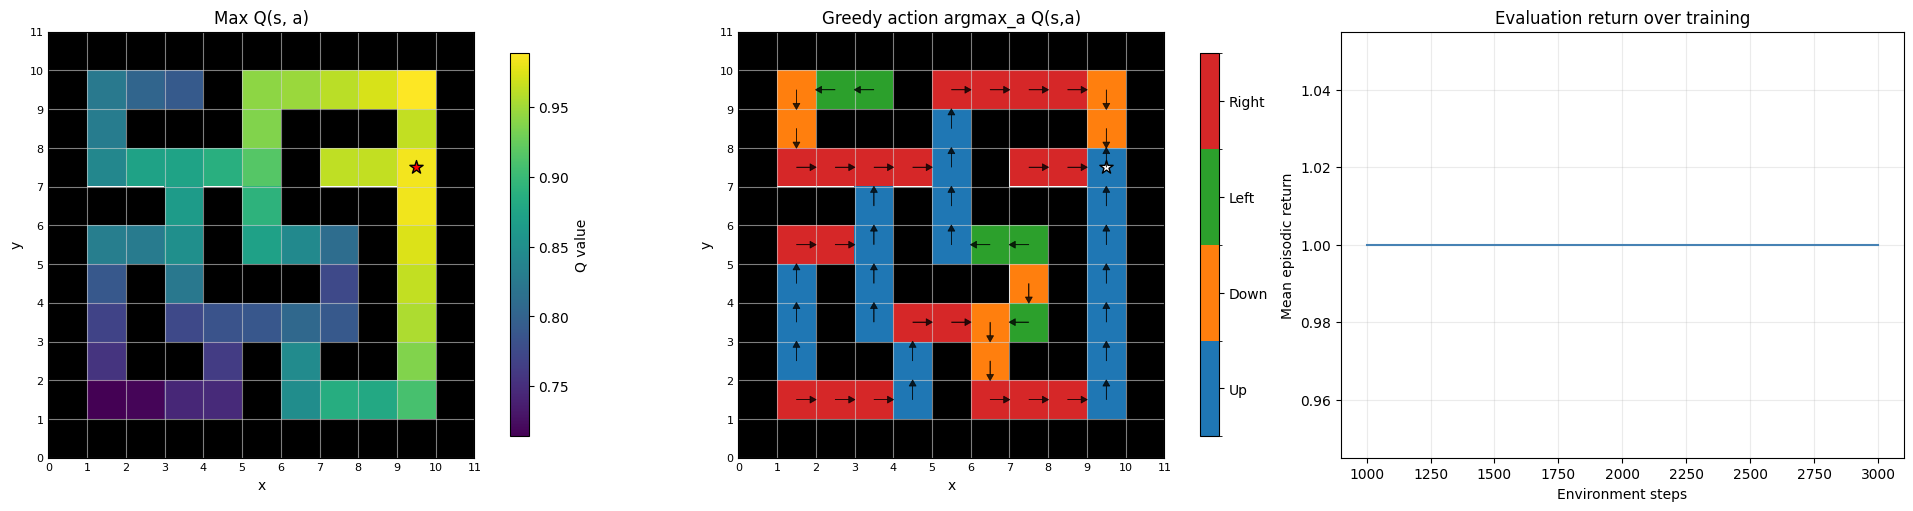

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.111381  3.432628  2.869364  2.5734582 2.380082 ]
cumulative variance (first 5 dims): [0.2537322  0.43060195 0.55418855 0.6535995  0.7386318 ]
cos(phi(s,a), psi/task): mean=0.7954, std=0.0960


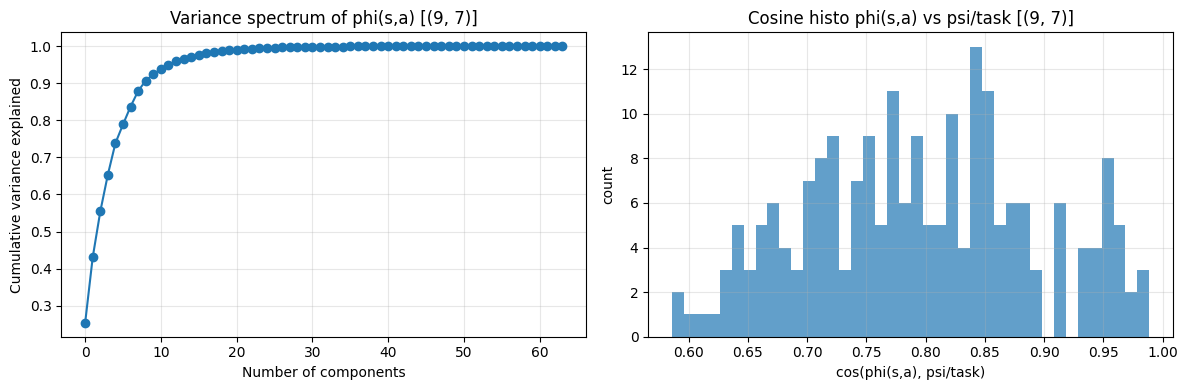


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0.410      0.393      0.387      0

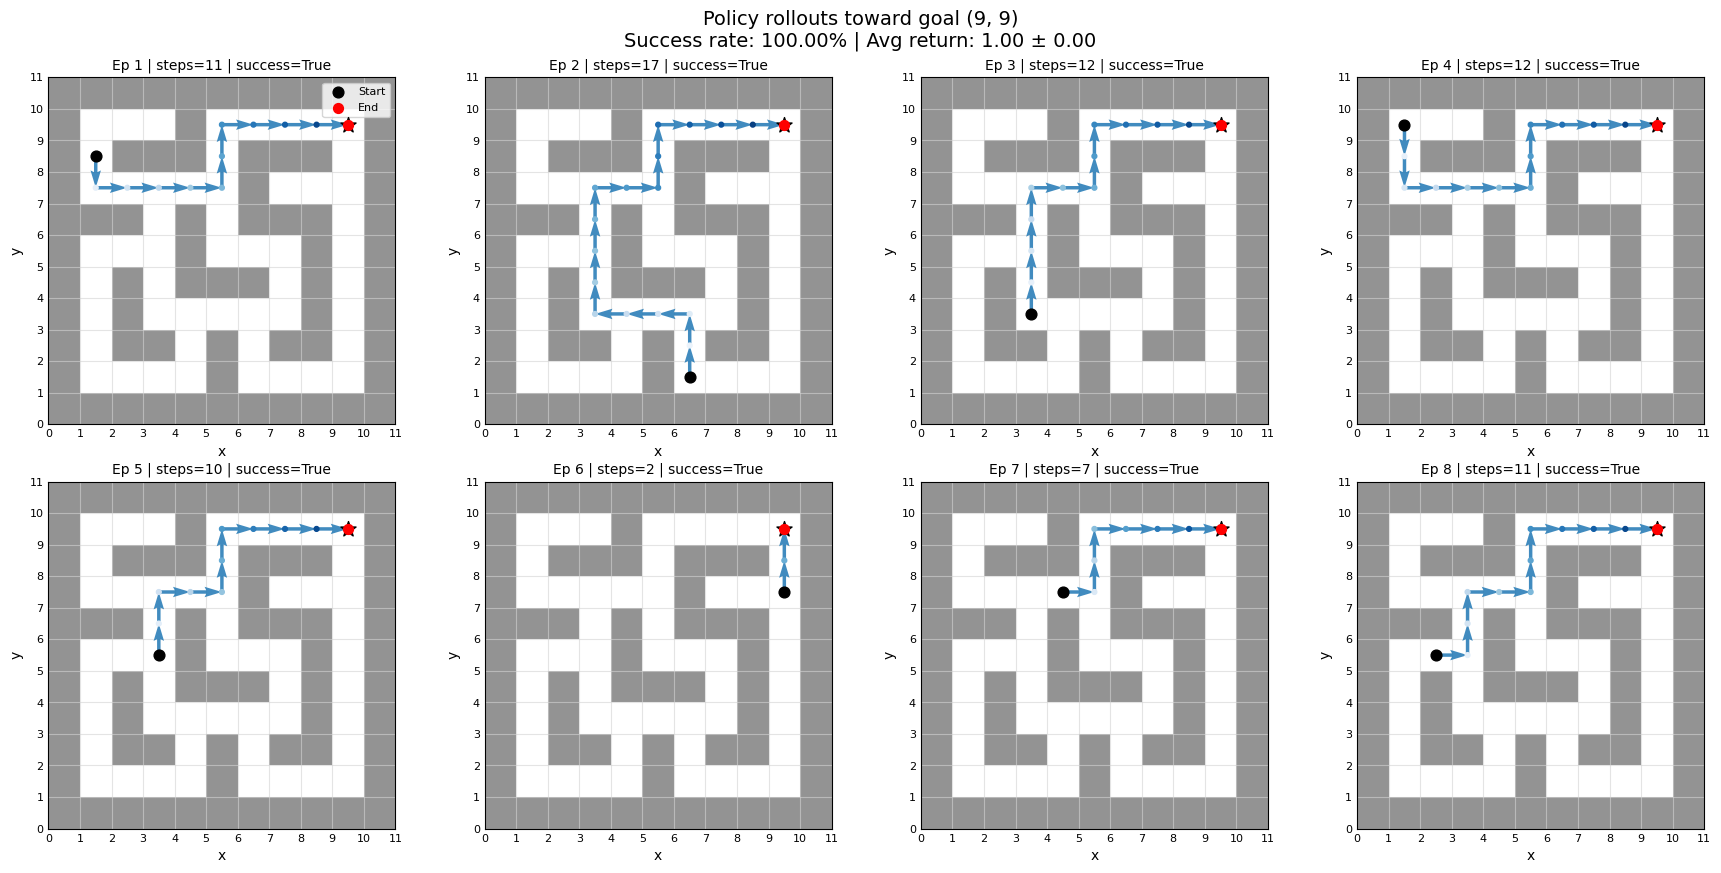

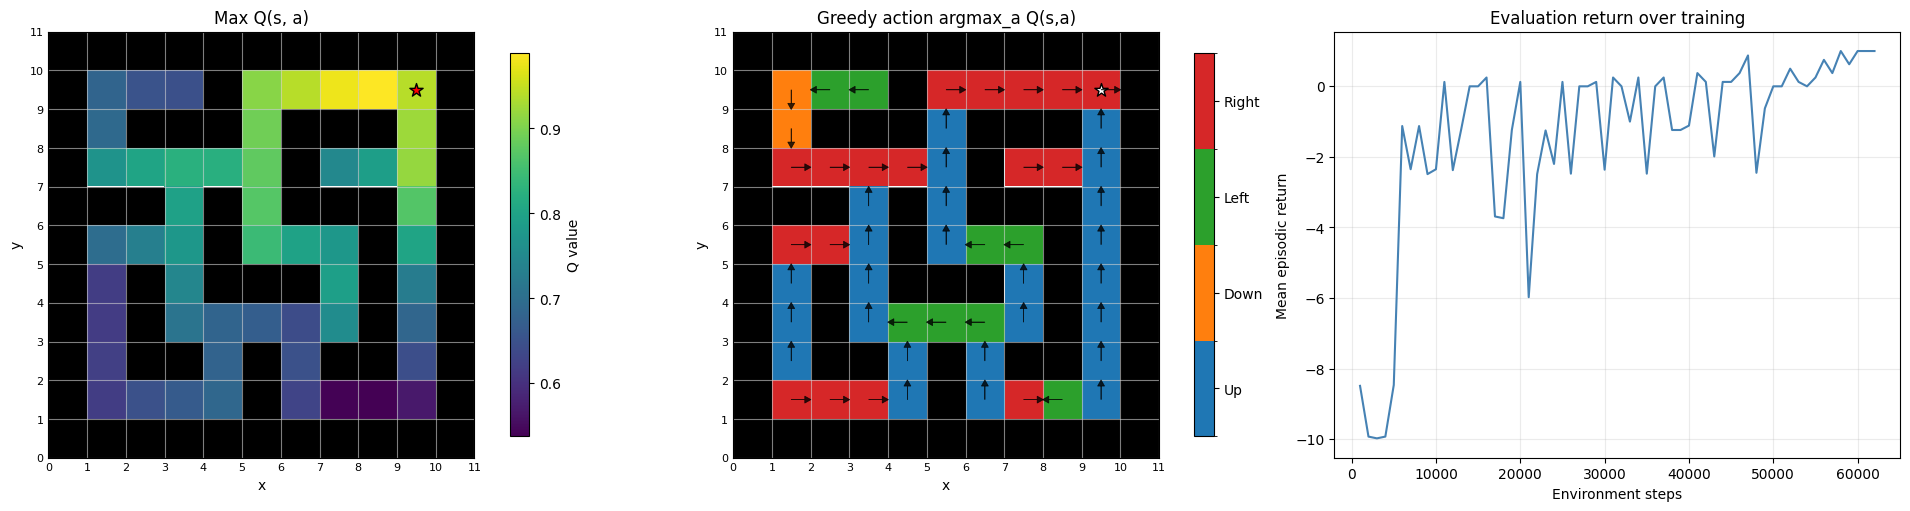

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [5.135107  3.793966  3.6297855 2.6972575 2.2980294]
cumulative variance (first 5 dims): [0.31468058 0.48645473 0.6436838  0.73050296 0.7935235 ]
cos(phi(s,a), psi/task): mean=0.6766, std=0.1216


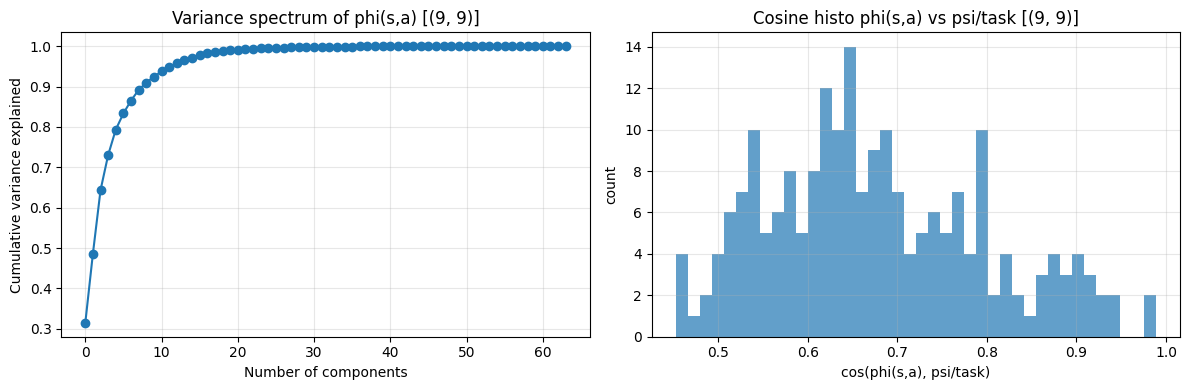


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0.373      0.390      0.403      0

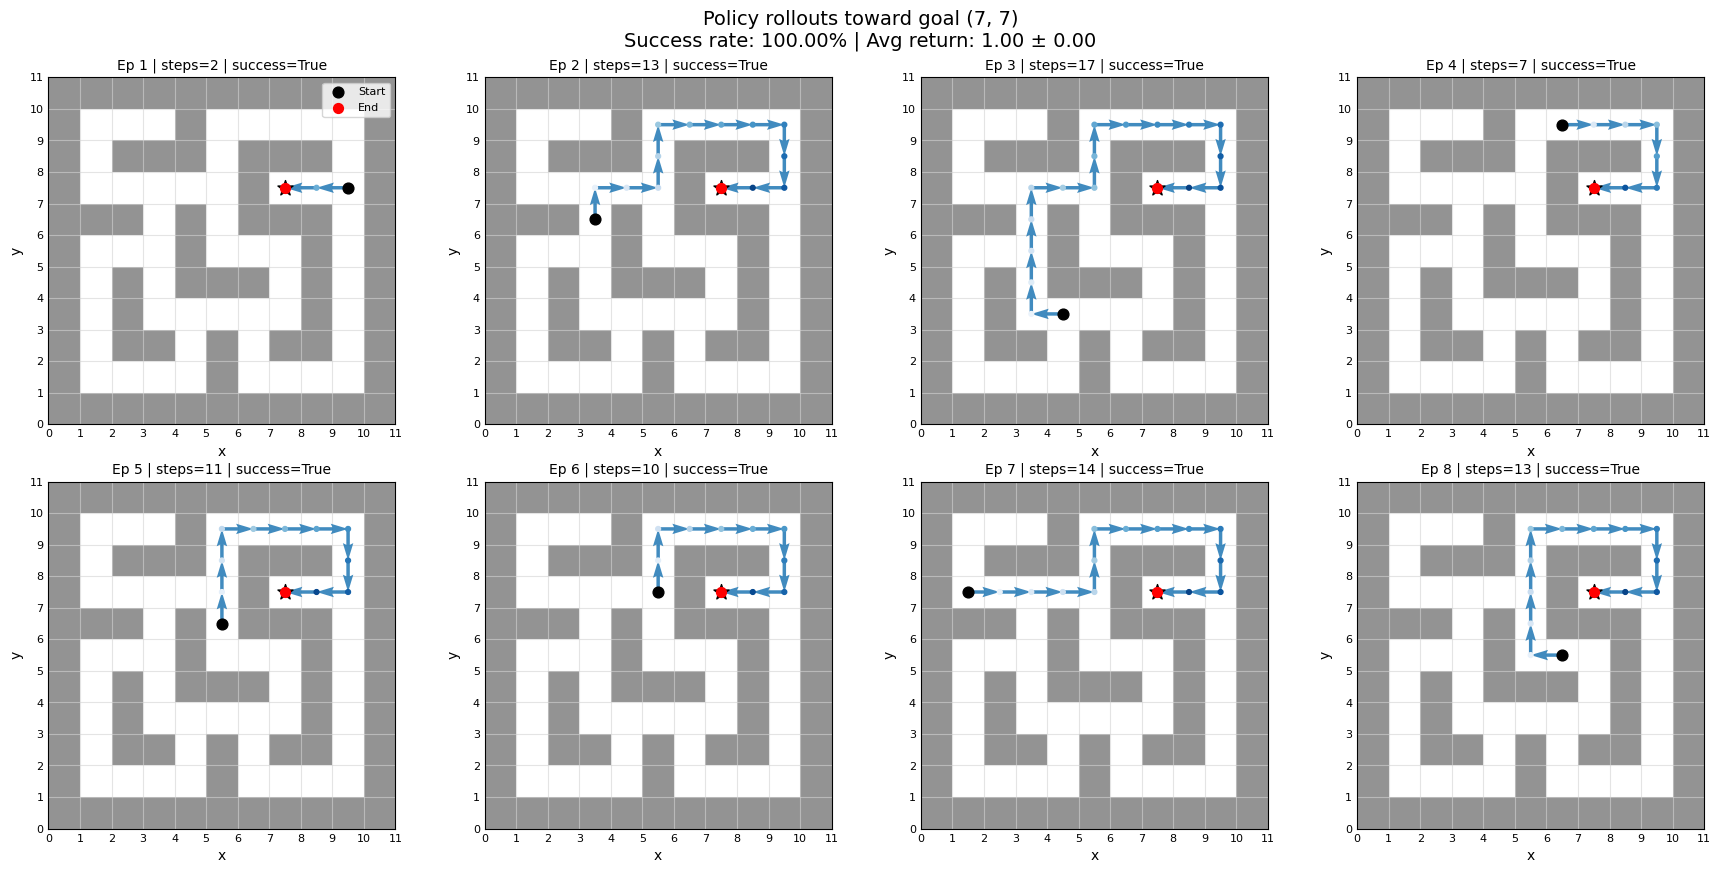

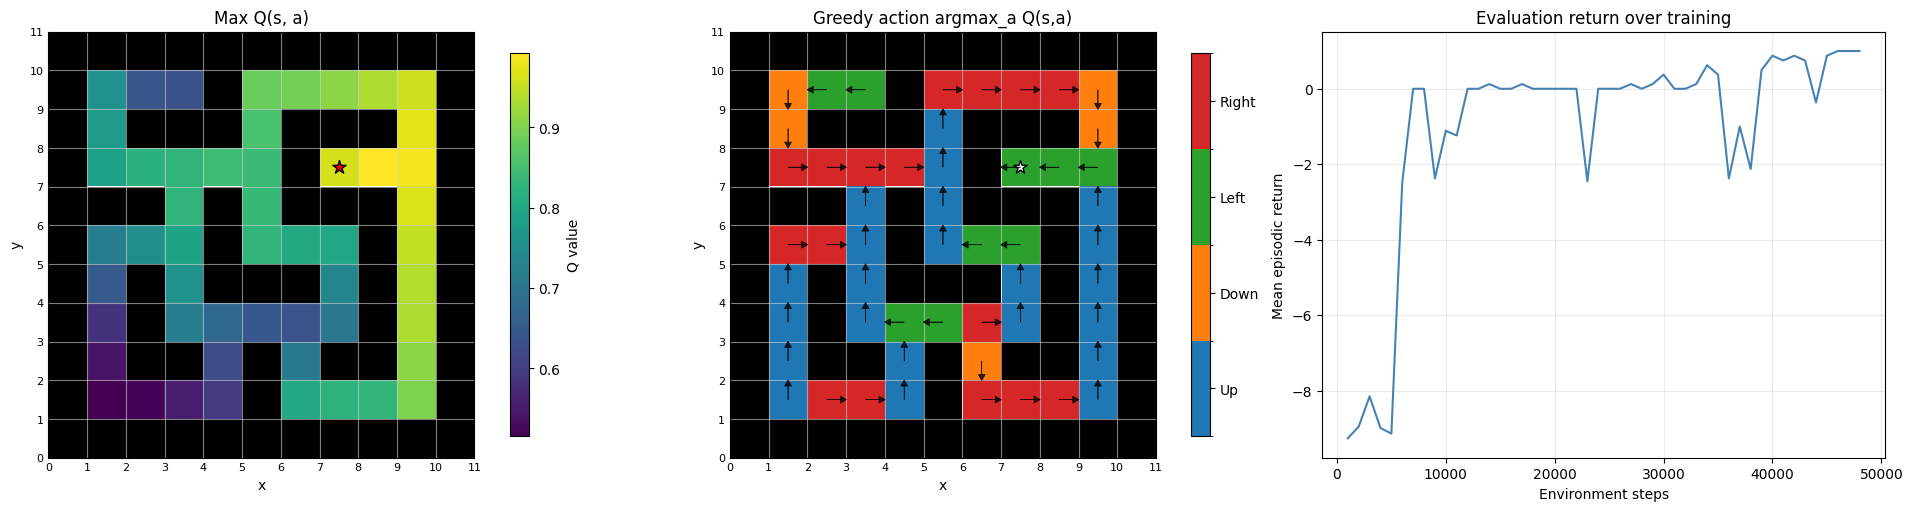

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.6306396 4.1897373 3.0572803 2.5141501 2.189198 ]
cumulative variance (first 5 dims): [0.28220075 0.51322085 0.6362326  0.7194202  0.7824936 ]
cos(phi(s,a), psi/task): mean=0.7202, std=0.1398


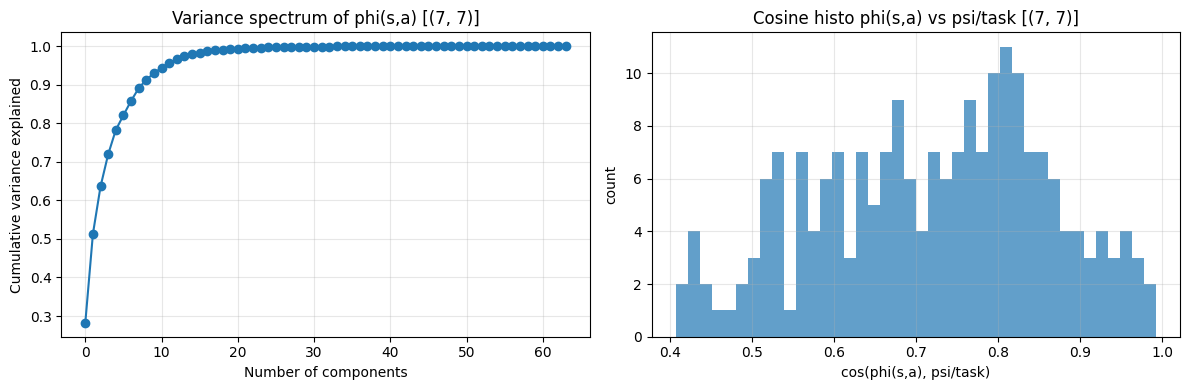


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0.237      0.544      0.363      0

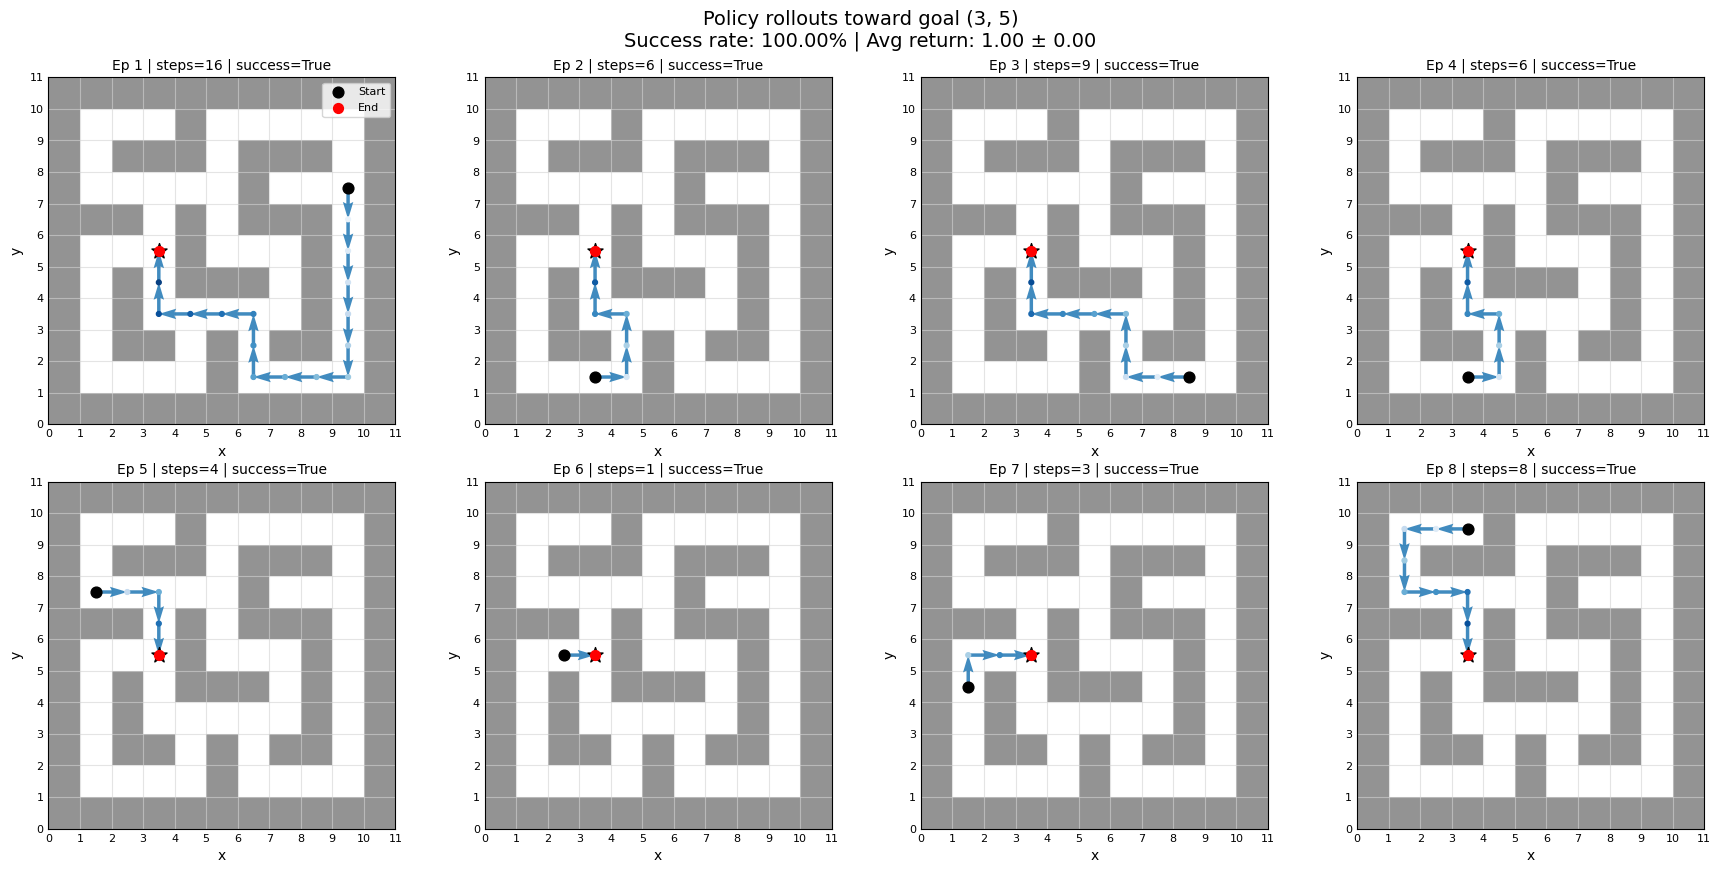

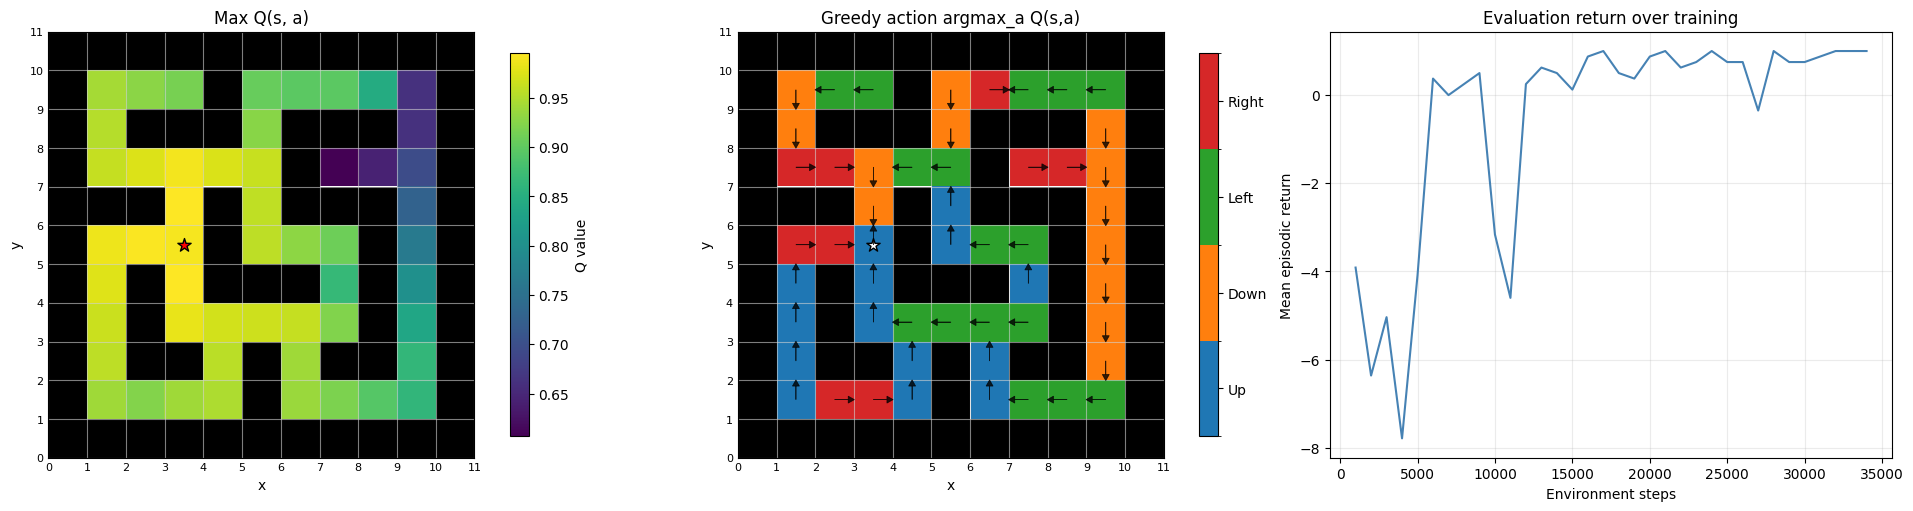

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.505971  2.8309731 2.7151923 1.9926443 1.8589088]
cumulative variance (first 5 dims): [0.3830503  0.53424984 0.67333484 0.74824464 0.81343675]
cos(phi(s,a), psi/task): mean=0.8449, std=0.1193


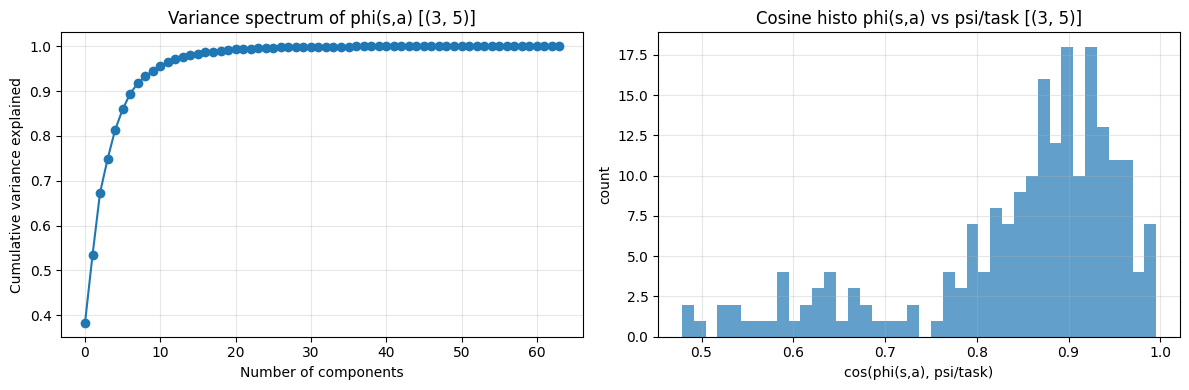


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0.523      0.382      0.345      0

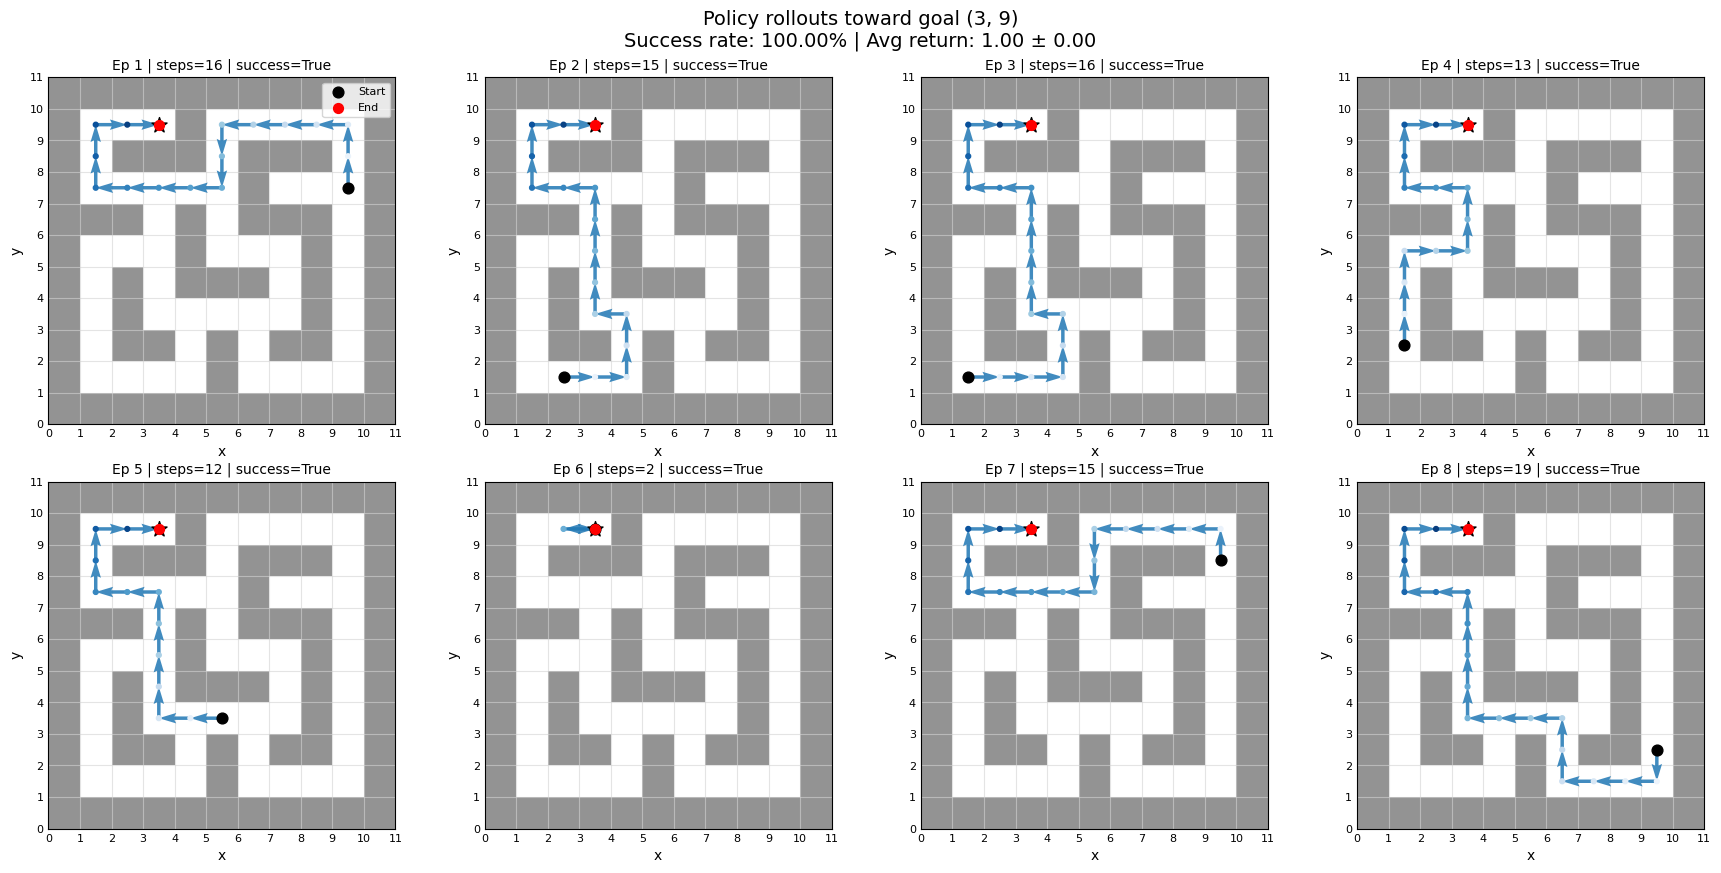

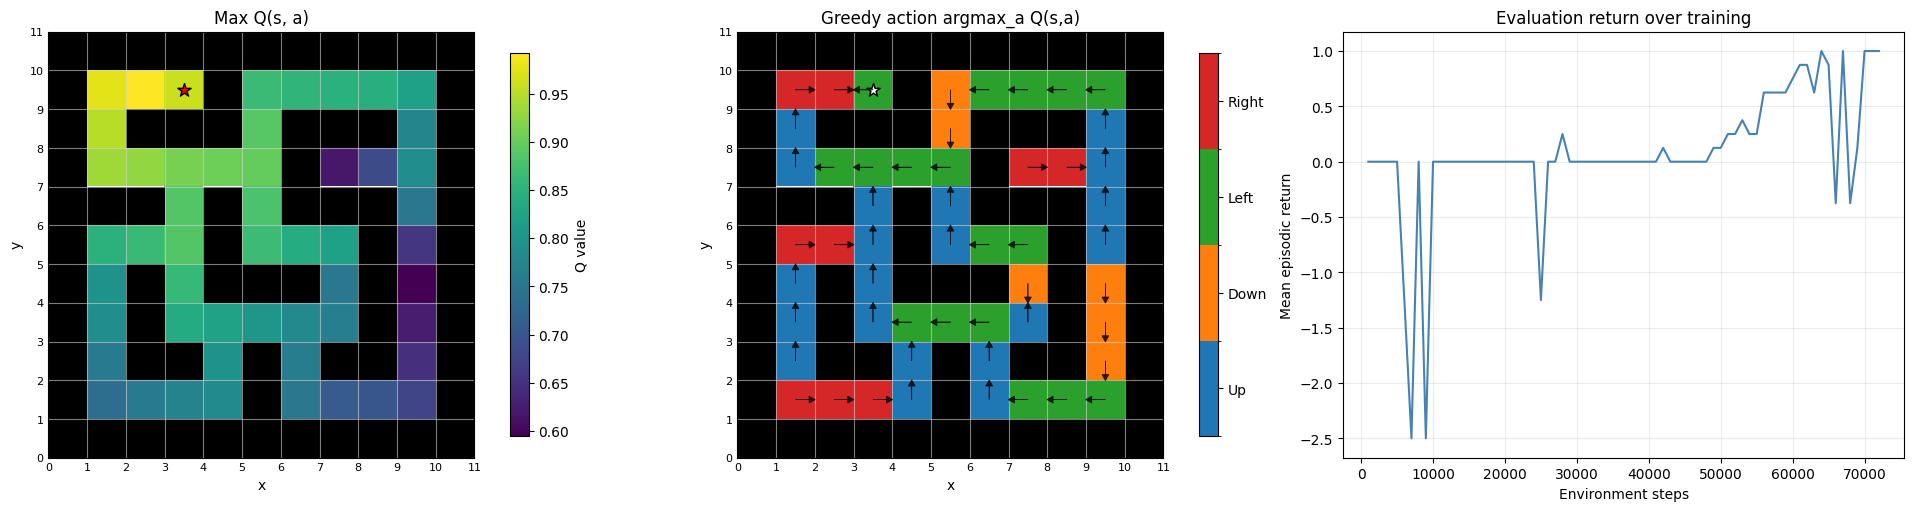

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.7281895 3.5965528 3.0205047 2.435948  2.231226 ]
cumulative variance (first 5 dims): [0.3024431  0.47743857 0.6008664  0.68114316 0.7484937 ]
cos(phi(s,a), psi/task): mean=0.7396, std=0.1156


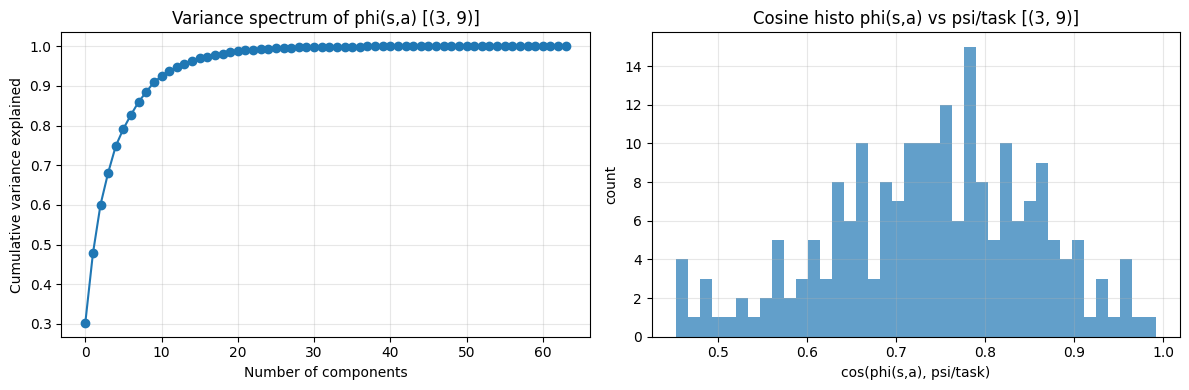


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367      0.424
  (3, 5)      0.447      0.520      1.000      0.099      0.289      0.458      0

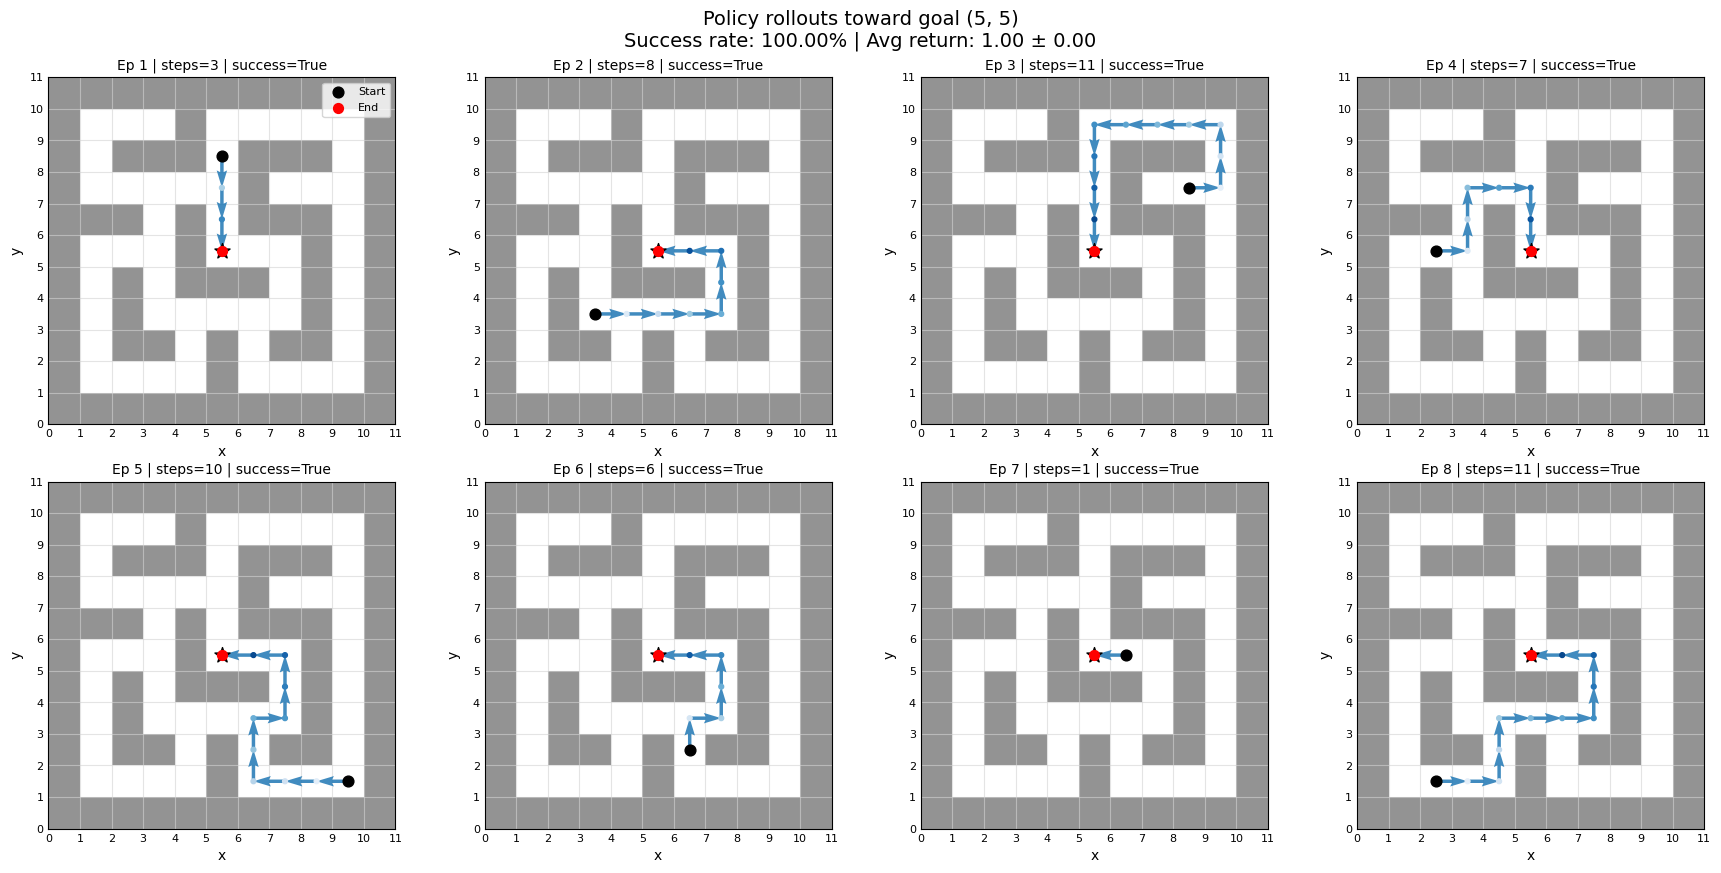

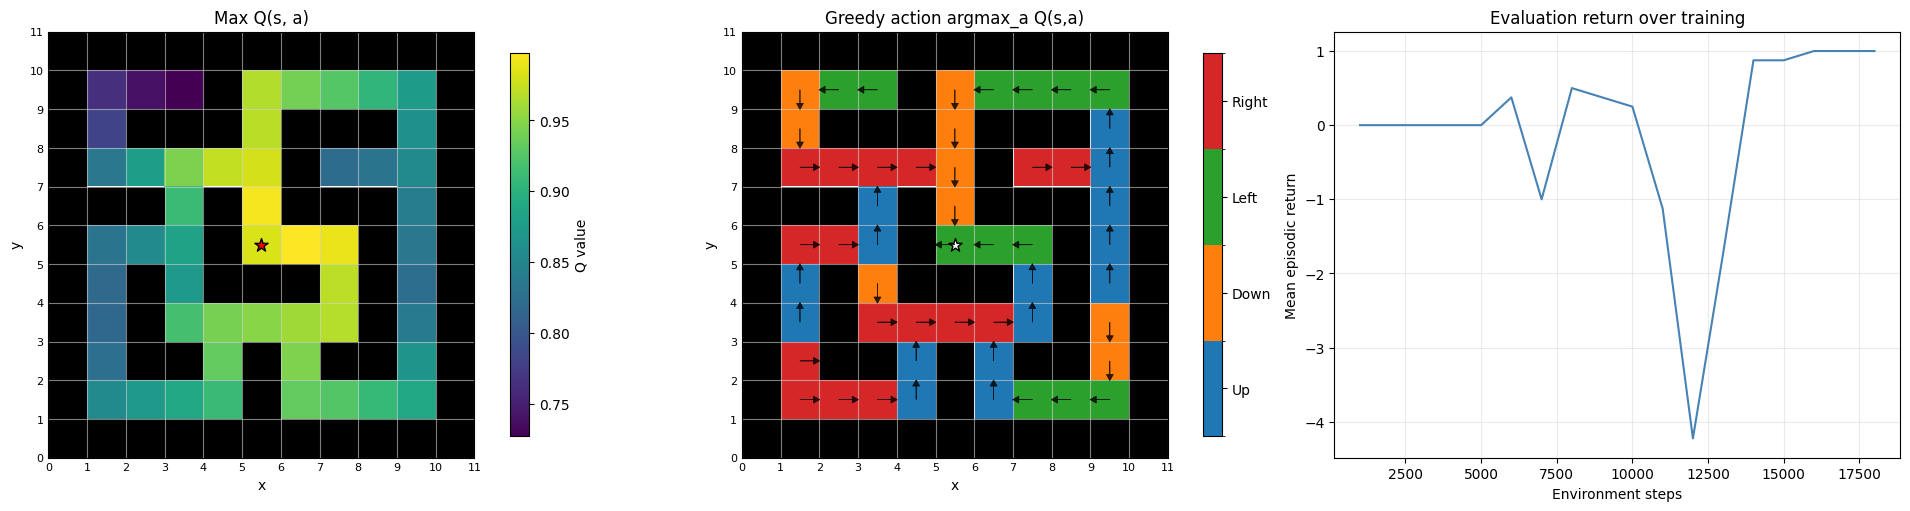

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.908476  3.0881898 2.7830472 2.5487587 2.1739821]
cumulative variance (first 5 dims): [0.2615275  0.42479903 0.55739903 0.66861314 0.7495254 ]
cos(phi(s,a), psi/task): mean=0.8303, std=0.0844


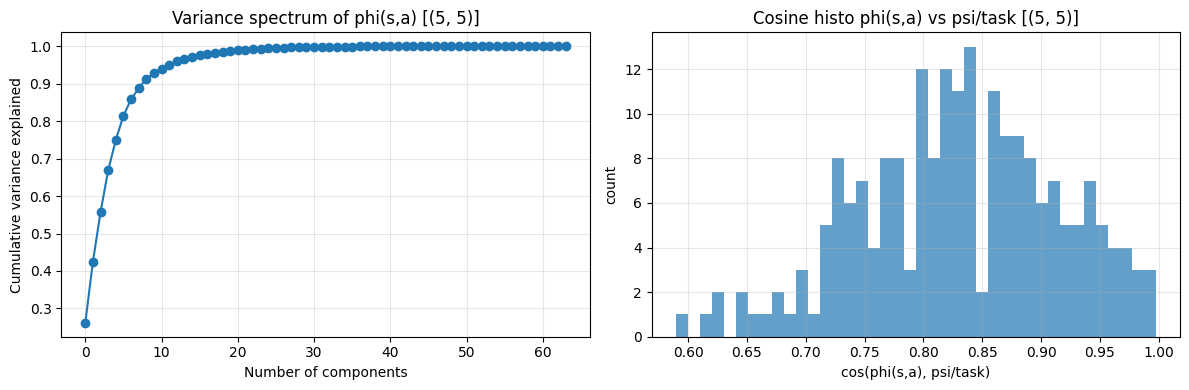


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367      0.424      0.354
  (3, 5)      0.447      0.520      1.000      0

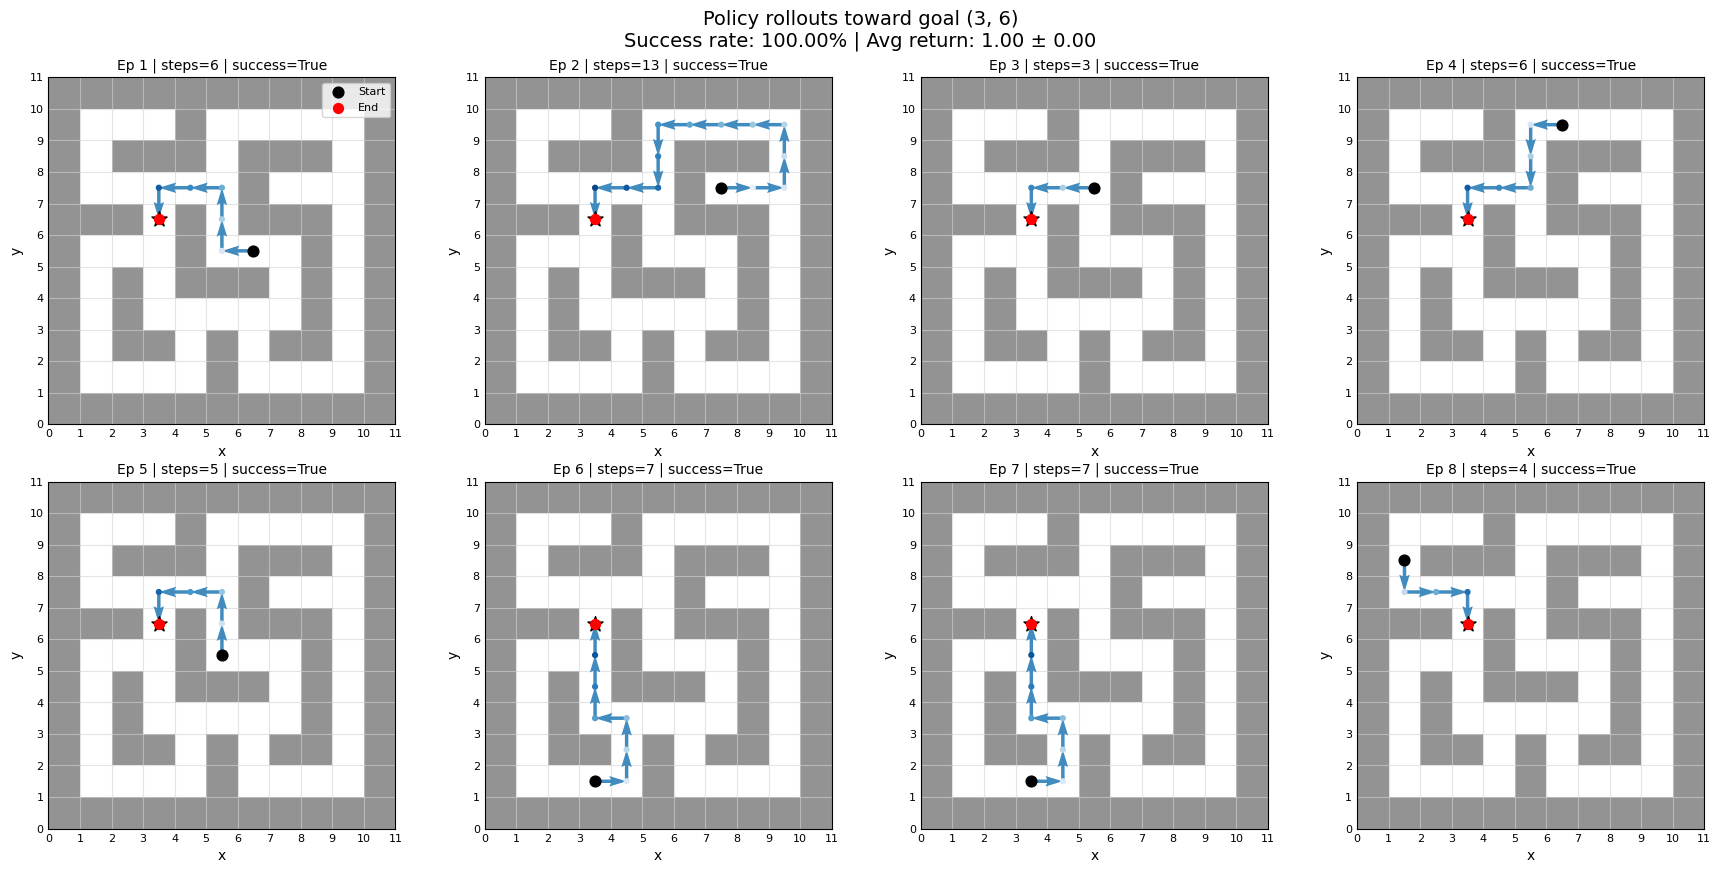

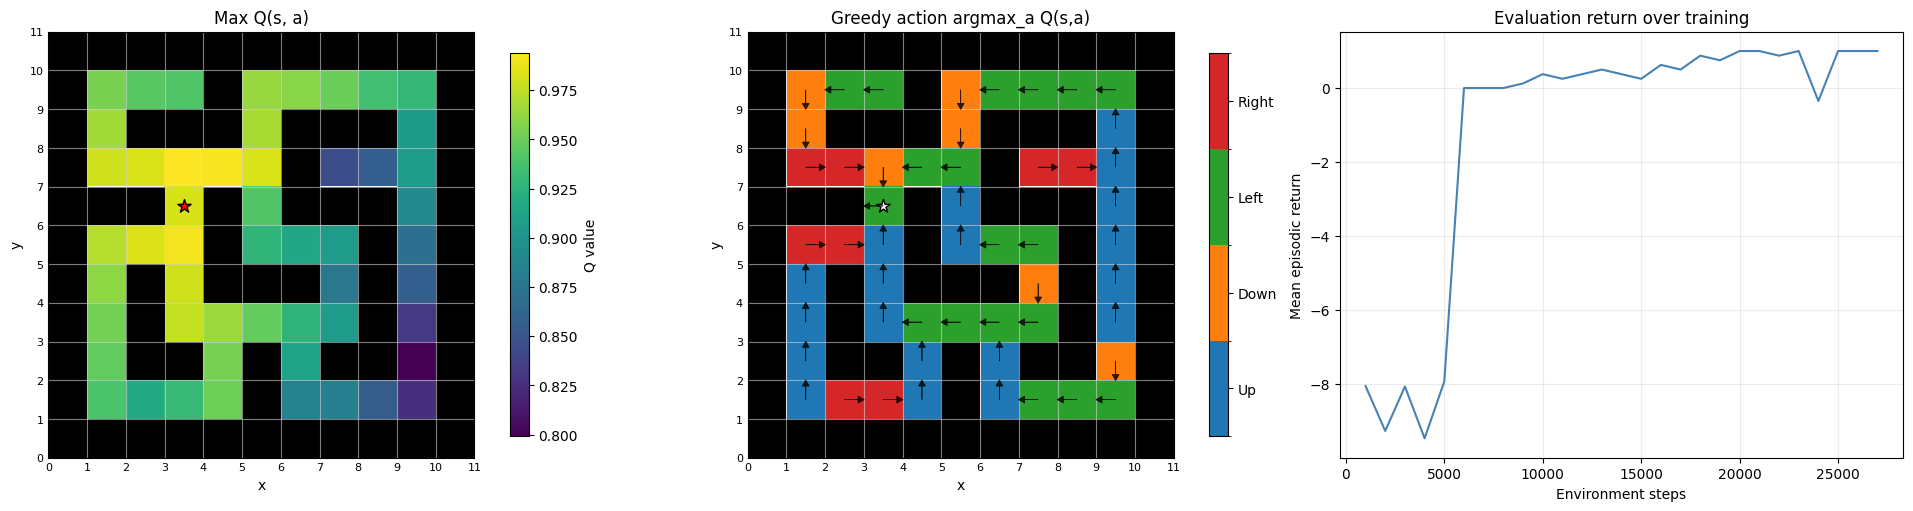

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4295301 2.8408868 2.3610263 1.9424995 1.7693979]
cumulative variance (first 5 dims): [0.26779184 0.45154548 0.5784654  0.6643766  0.73565847]
cos(phi(s,a), psi/task): mean=0.8701, std=0.0794


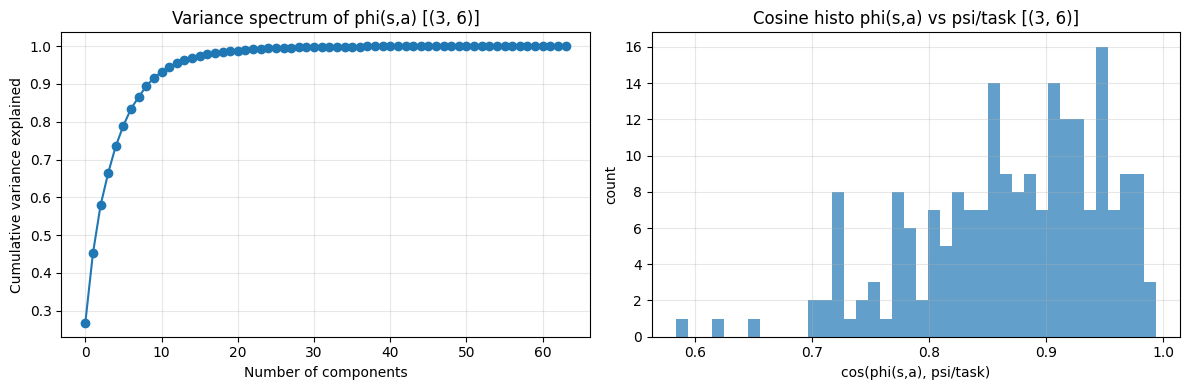


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367      0.424      0.354      0.358
  (3, 5)      0

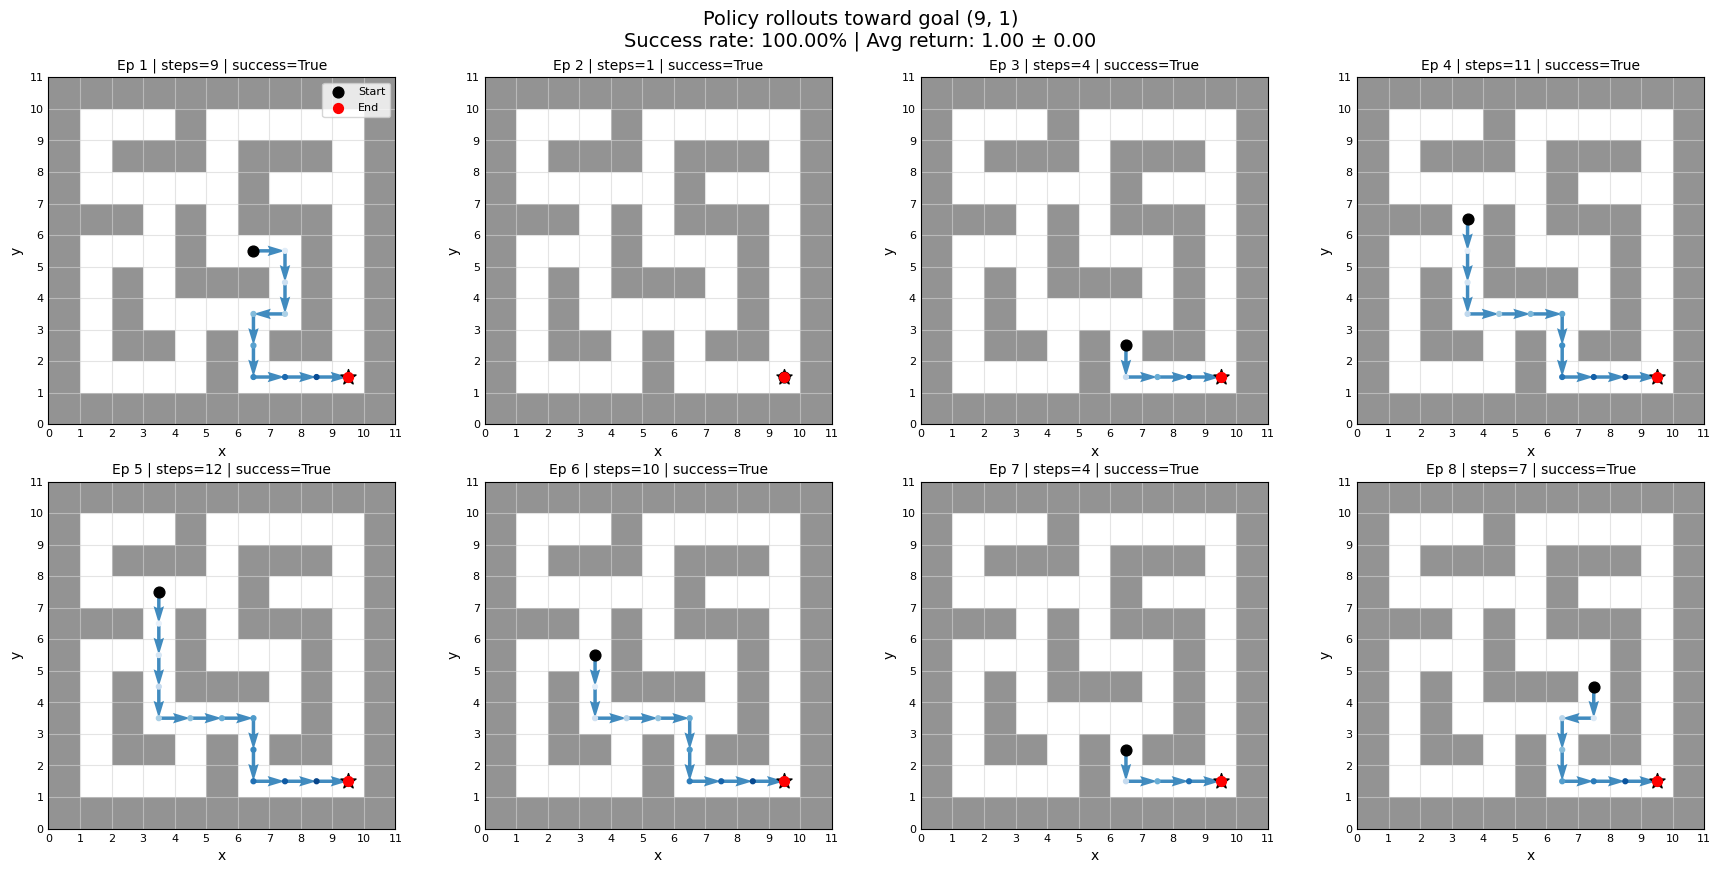

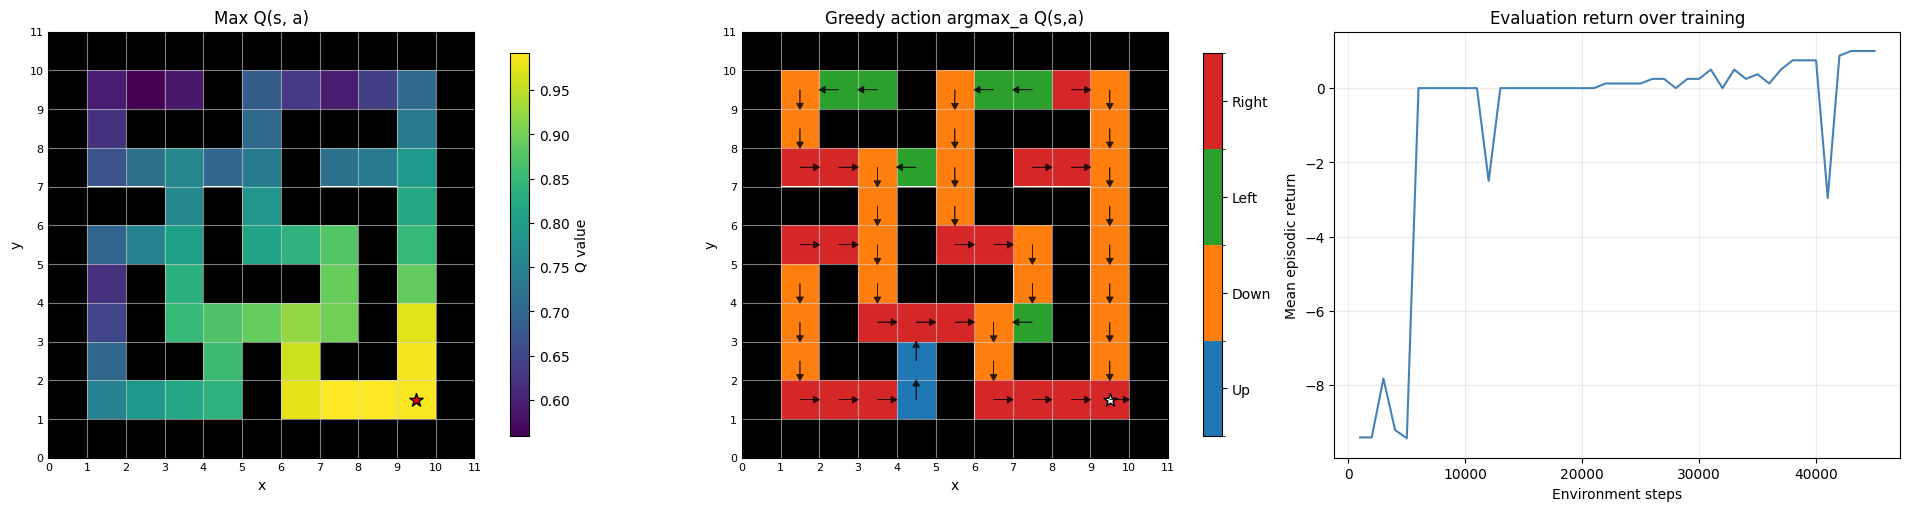

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.967019  3.693569  3.3623078 2.9768863 1.9856406]
cumulative variance (first 5 dims): [0.22560376 0.42117733 0.5832436  0.7102841  0.7668063 ]
cos(phi(s,a), psi/task): mean=0.7170, std=0.1346


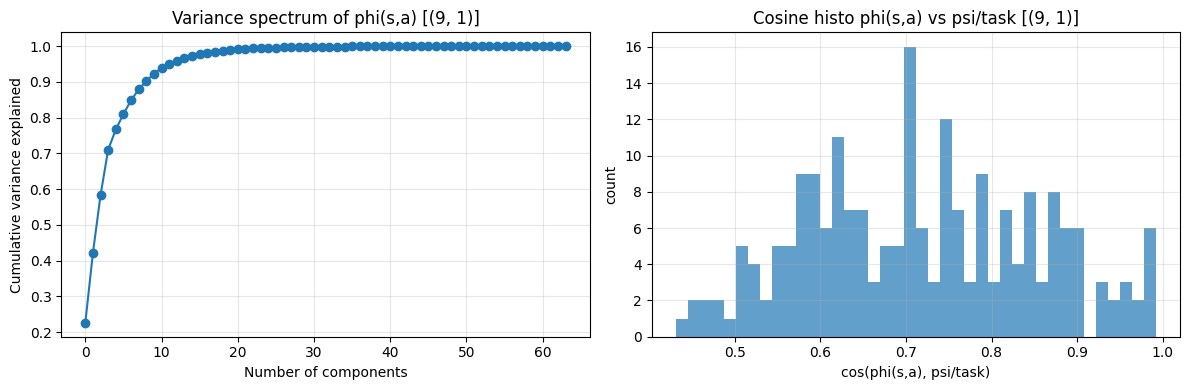


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340      0.193
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367      0.424      0.354     

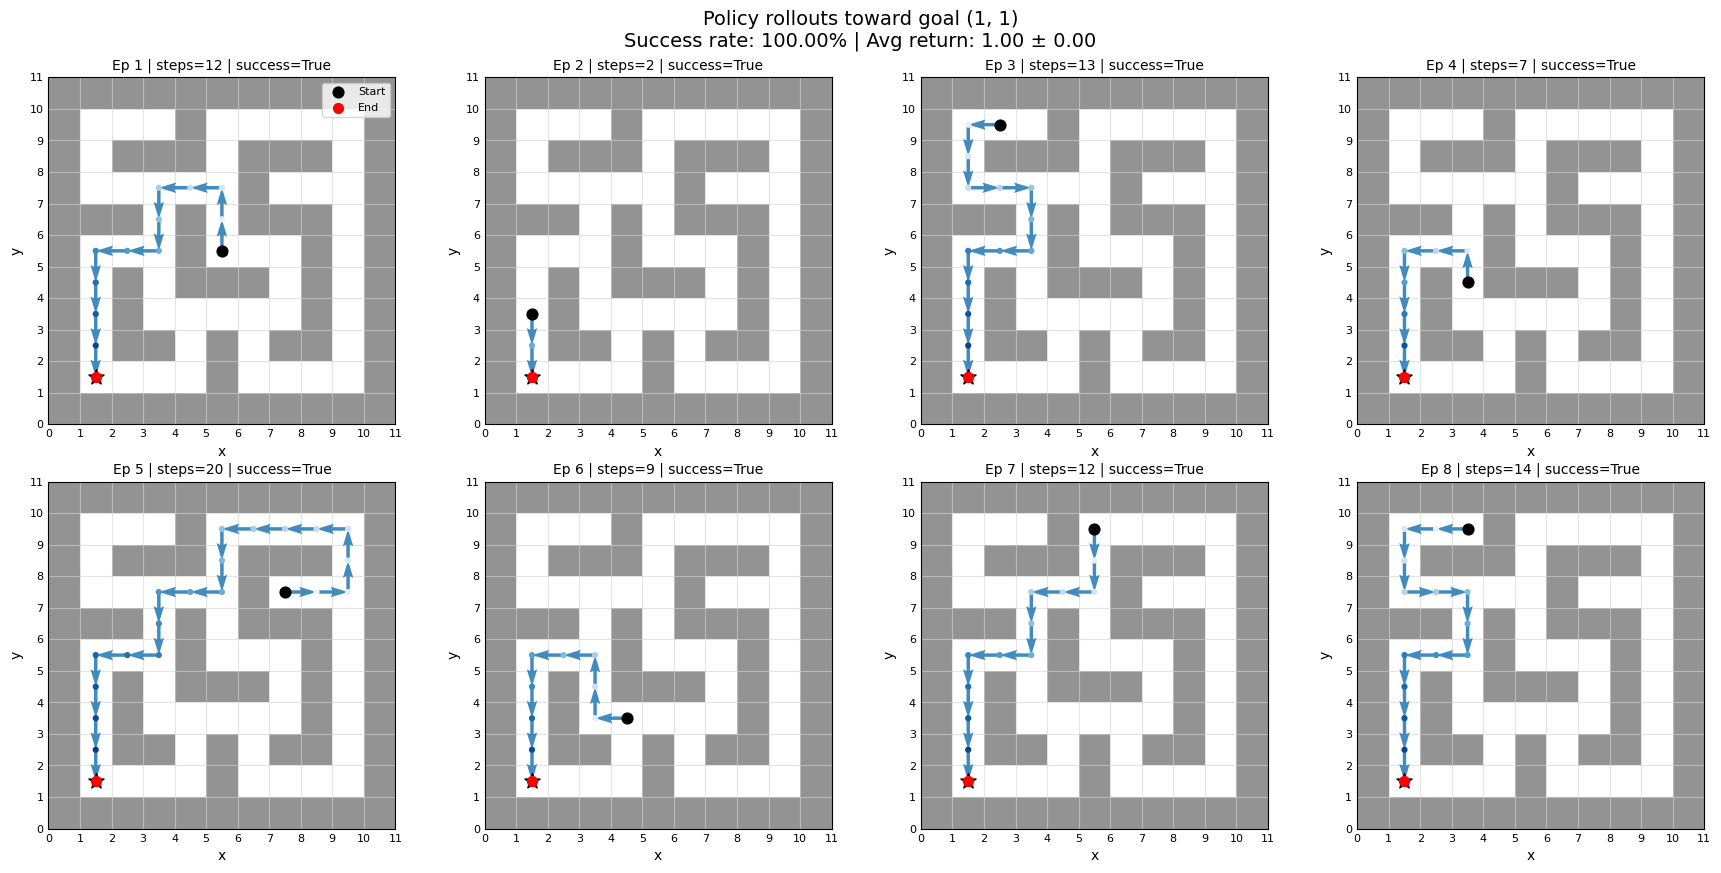

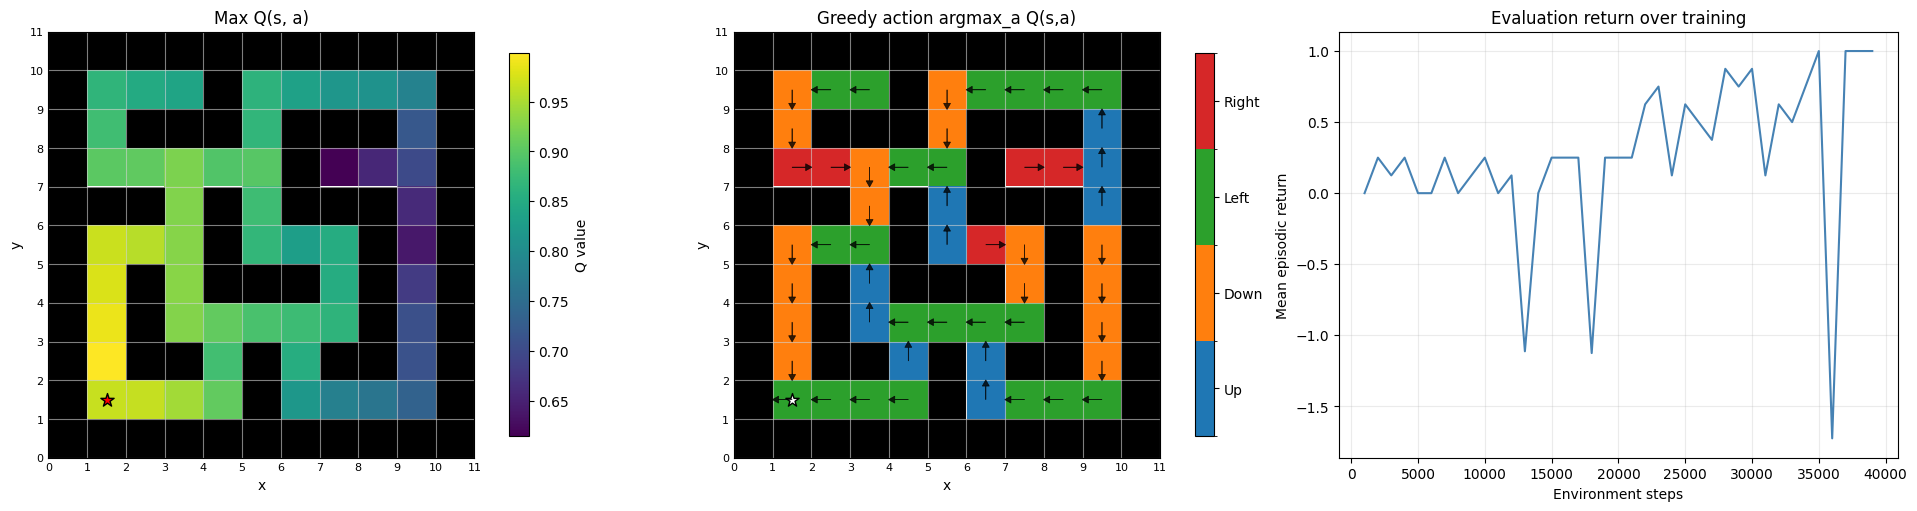

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.2458267 3.277021  3.1062653 2.7014327 1.9422526]
cumulative variance (first 5 dims): [0.27505904 0.4389141  0.586138   0.6974879  0.75504684]
cos(phi(s,a), psi/task): mean=0.7847, std=0.1183


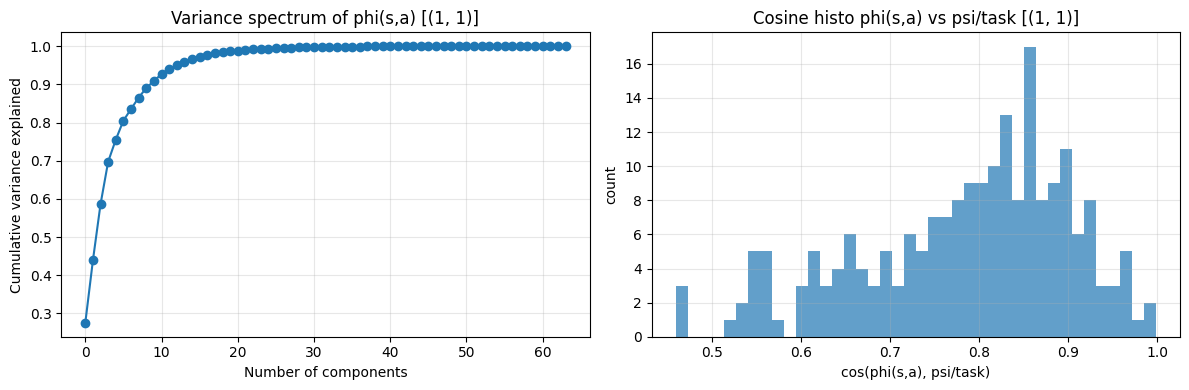


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340      0.193      0.141
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428      0.421      0.367     

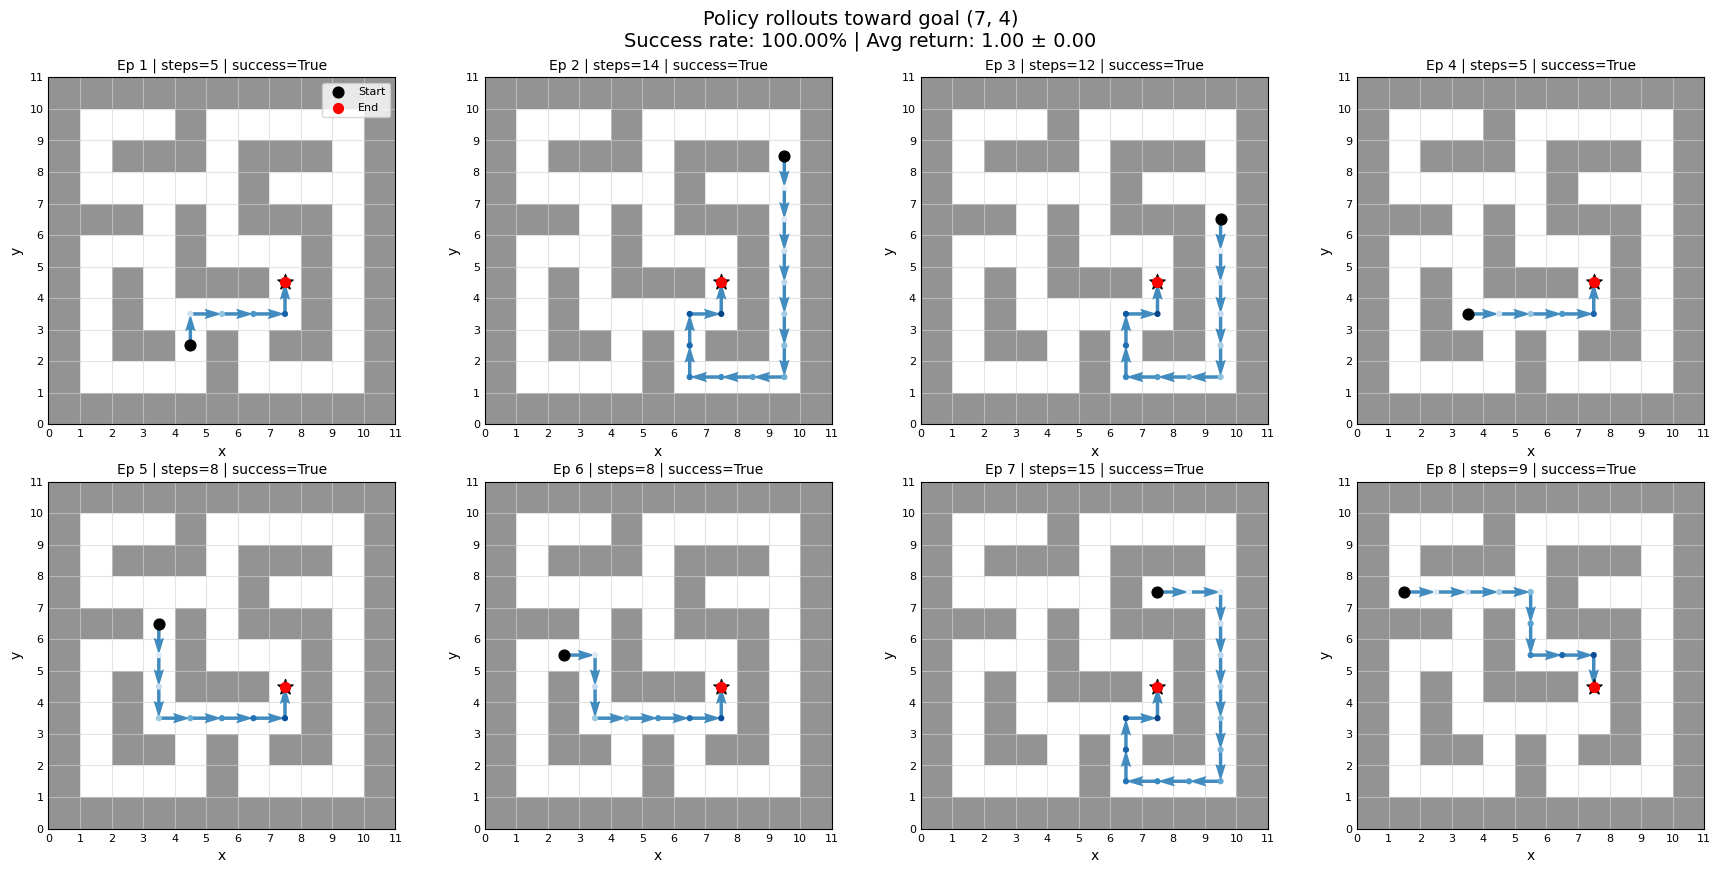

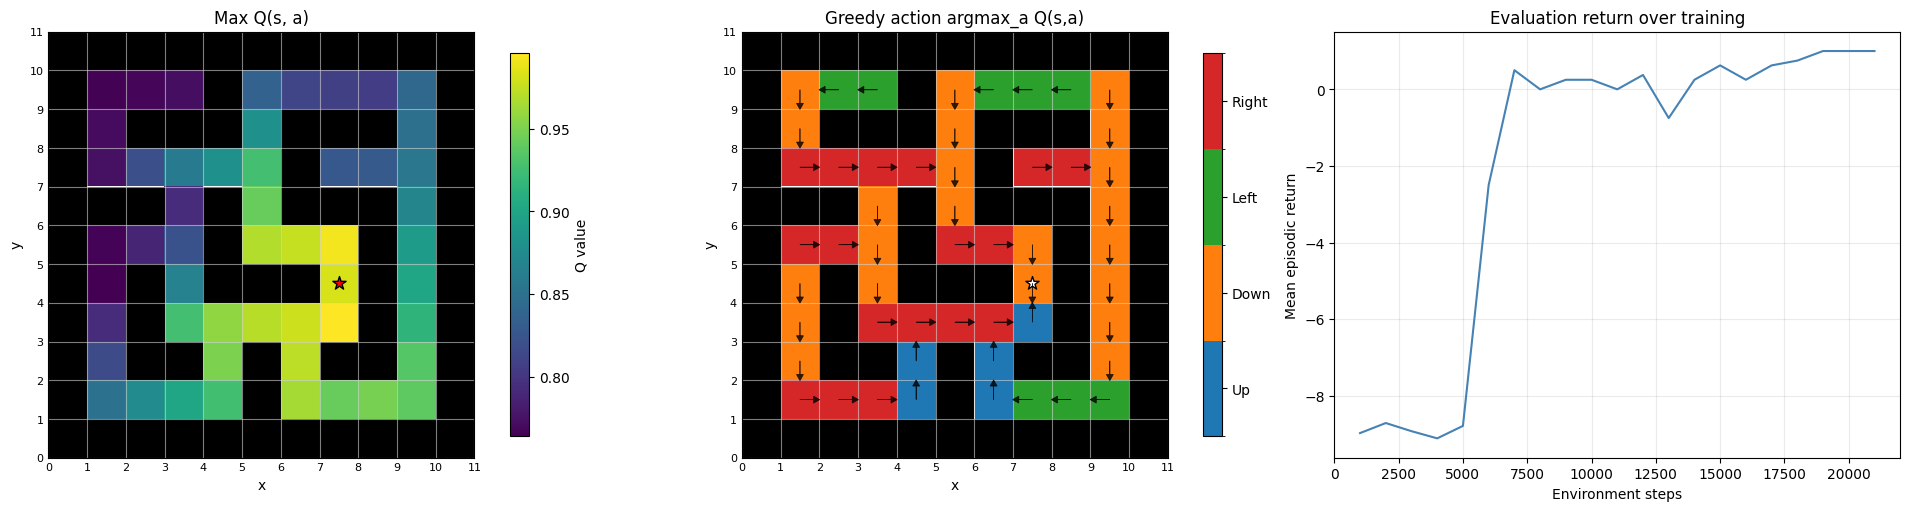

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.260189  3.534683  2.6111555 2.348235  1.8950527]
cumulative variance (first 5 dims): [0.2998961  0.5063457  0.61900795 0.71012425 0.7694654 ]
cos(phi(s,a), psi/task): mean=0.8137, std=0.0932


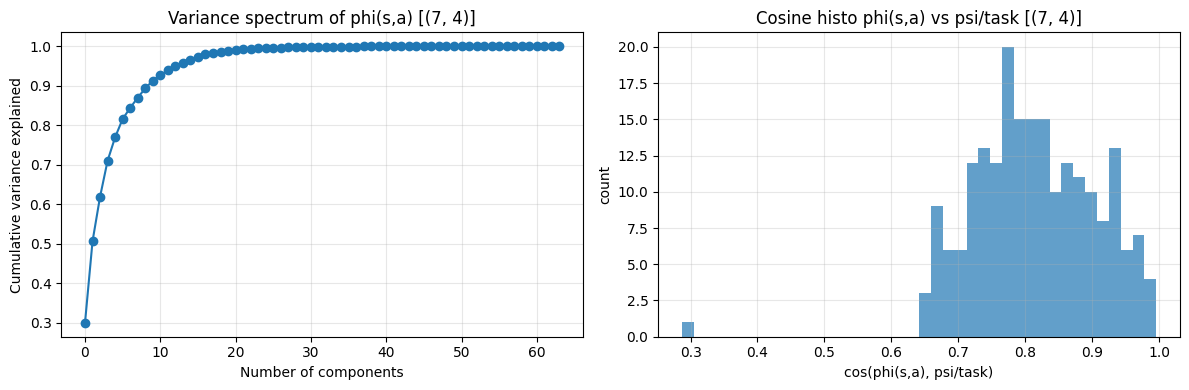


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340      0.193      0.141      0.156
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485      0.485      0.428     

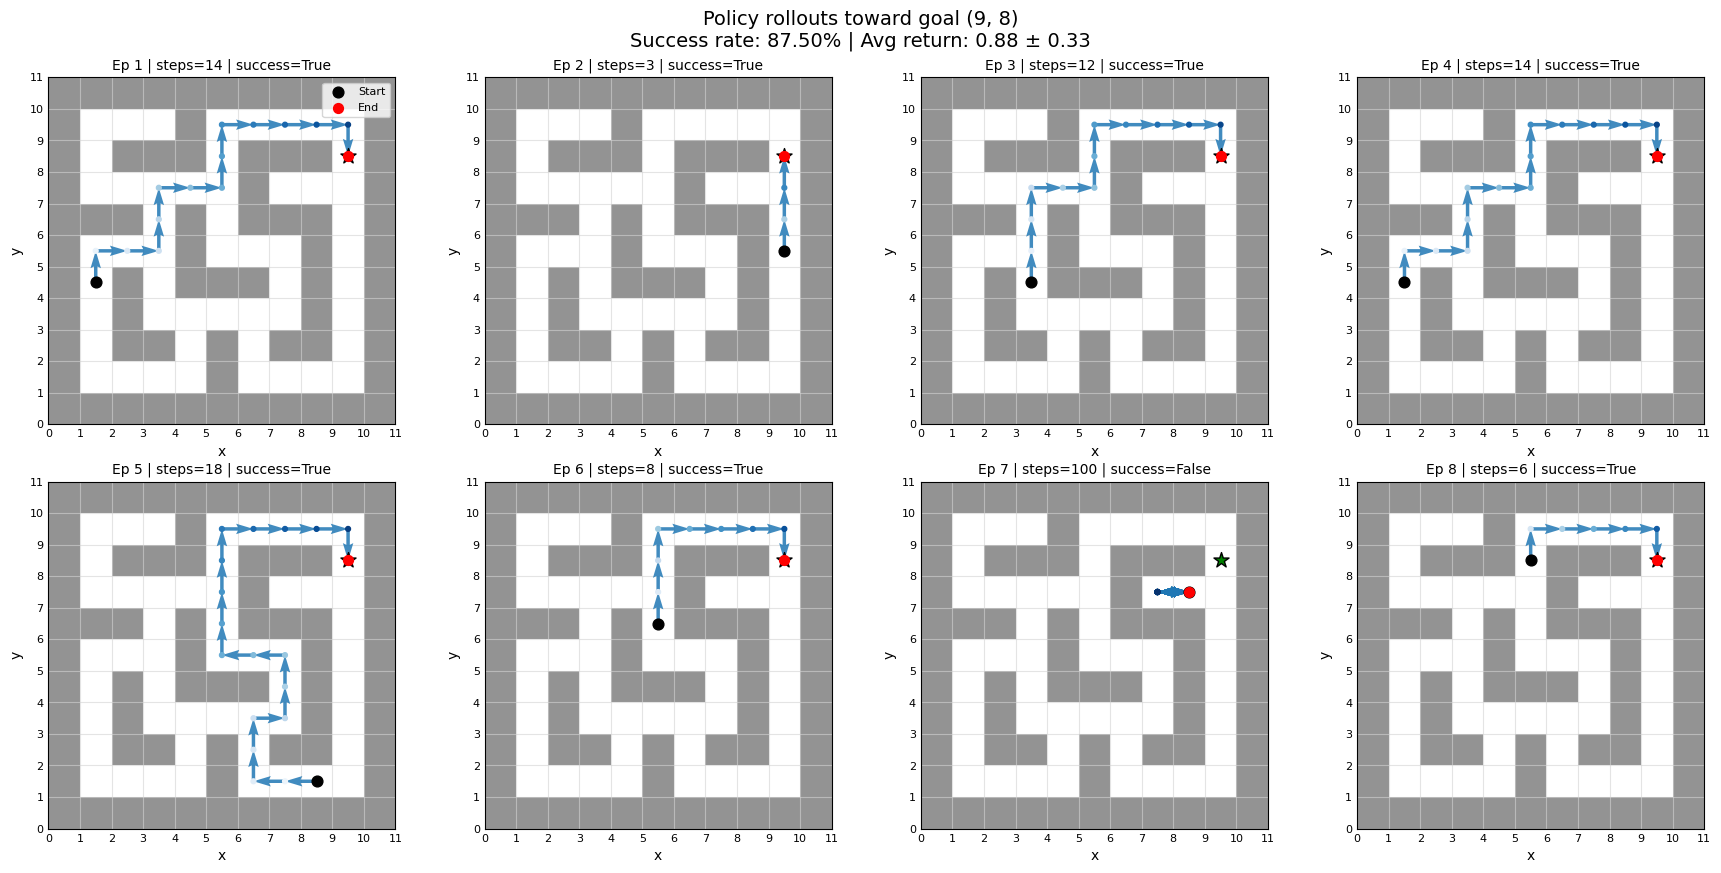

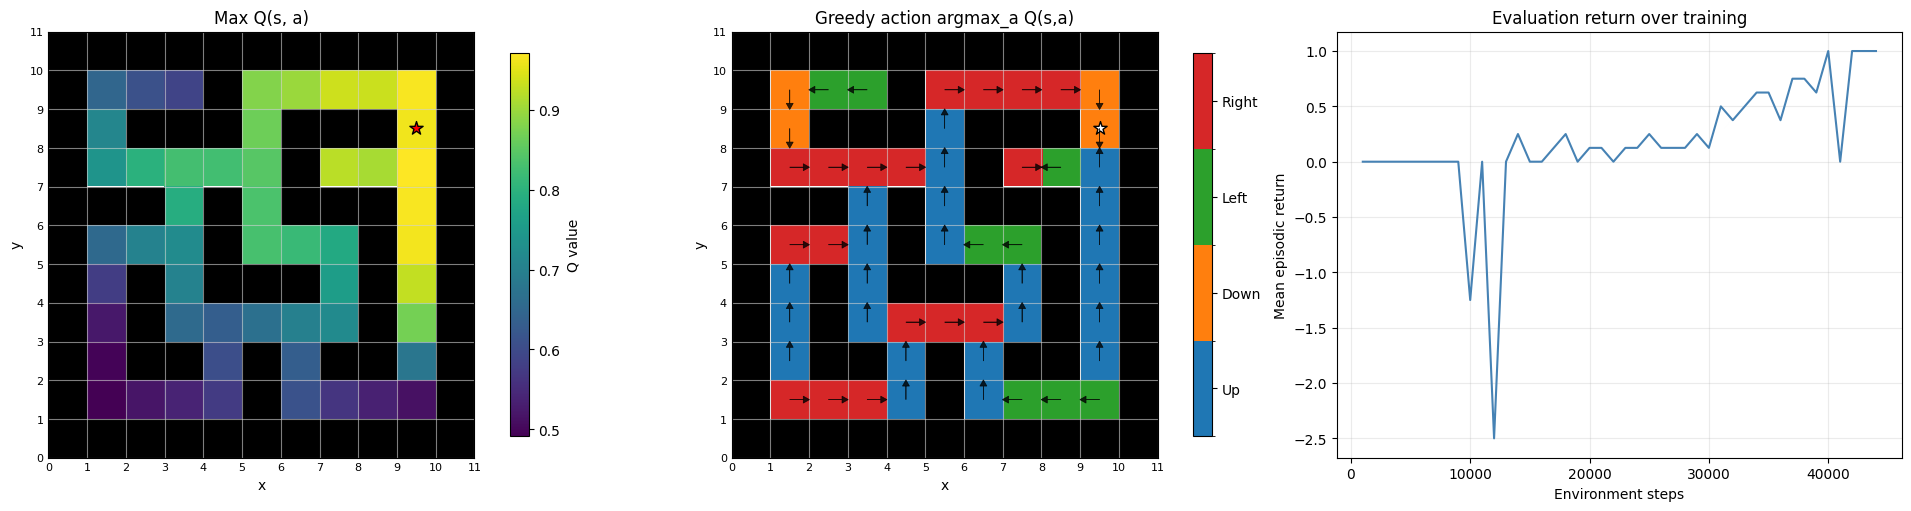

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.827166  4.107318  3.745911  3.3175702 2.3726072]
cumulative variance (first 5 dims): [0.25437623 0.4385419  0.5917236  0.711876   0.7733291 ]
cos(phi(s,a), psi/task): mean=0.6650, std=0.1582


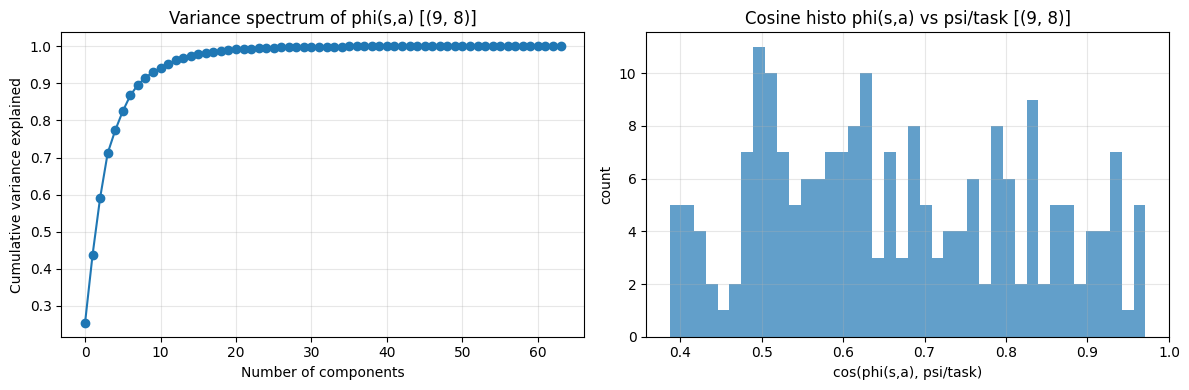


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340      0.193      0.141      0.156      0.138
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468      0.474      0.485     

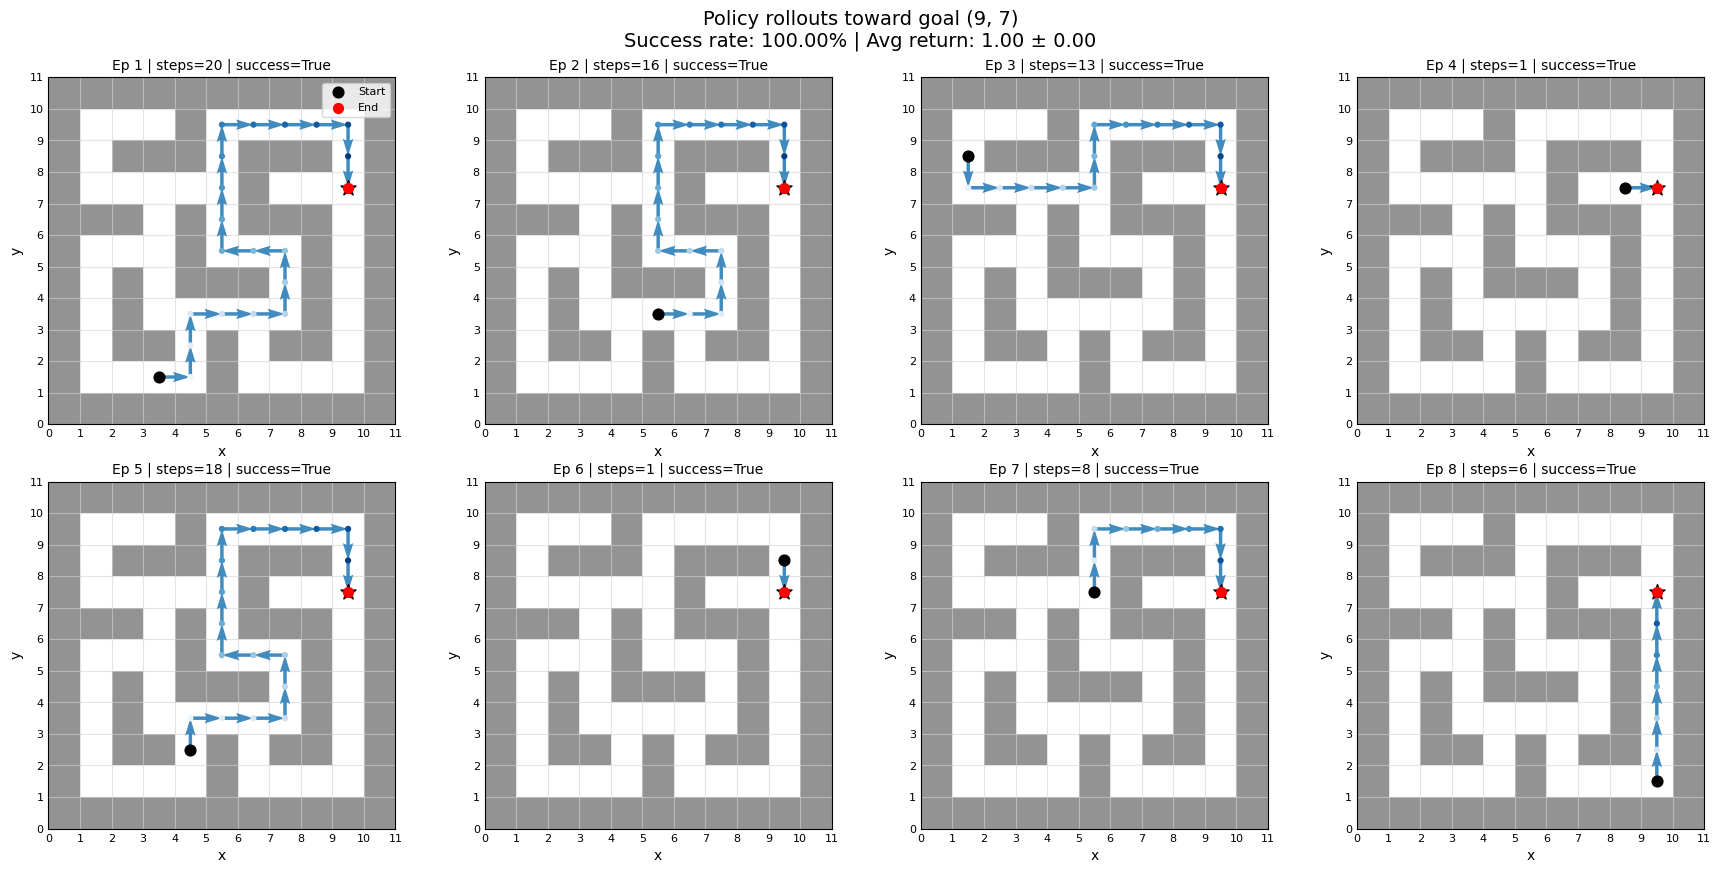

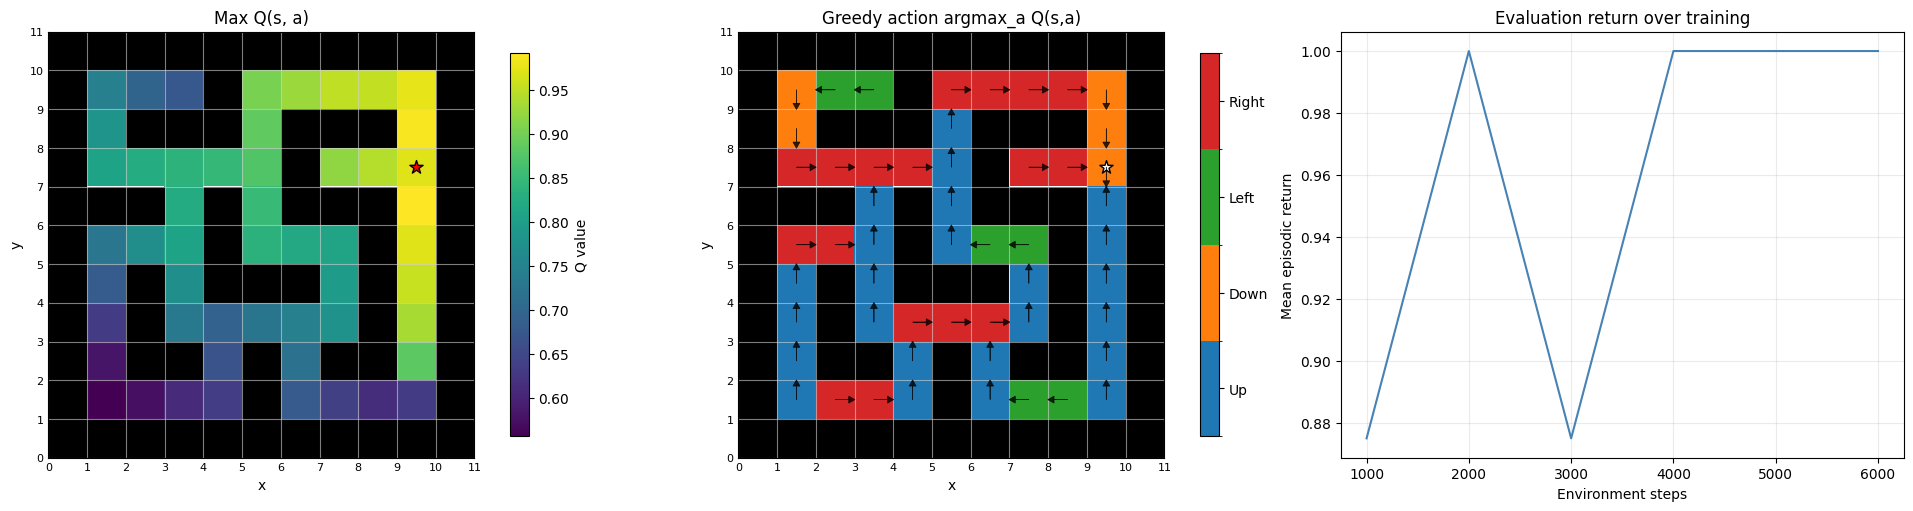

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.325093  3.9216154 3.248504  3.0596917 2.31389  ]
cumulative variance (first 5 dims): [0.23350999 0.42548496 0.55721396 0.67407507 0.74090946]
cos(phi(s,a), psi/task): mean=0.7183, std=0.1362


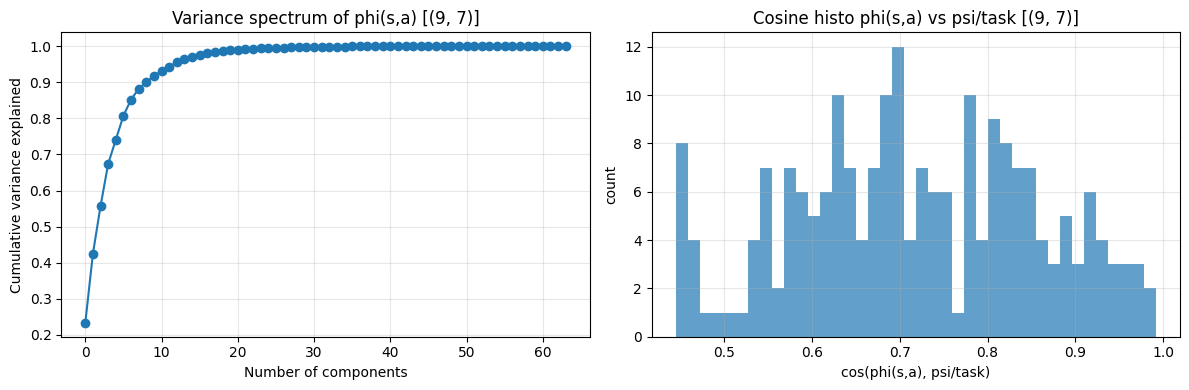


Goal embedding cosine similarity matrix:
     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)     (9, 9)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)
  (9, 9)      1.000      0.672      0.447      0.207      0.495      0.232      0.518      0.529      0.324      0.462      0.502      0.493      0.460      0.440      0.335      0.361      0.344      0.307      0.275      0.292      0.295      0.295      0.364      0.331      0.312      0.381      0.329      0.340      0.193      0.141      0.156      0.138      0.145
  (7, 7)      0.672      1.000      0.520      0.296      0.544      0.480      0.658      0.611      0.418      0.446      0.652      0.602      0.612      0.578      0.523      0.519      0.515      0.510      0.468     

In [3]:
SEEDS = [42]
PASS = 3
GOALS = [(9, 9), (7, 7), (3, 5), (3, 9), (5, 5), (3,6), (9,1), (1,1), (7,4), (9,8),(9,7)]
BUFFER_CAPACITY = 100000
LR = float(1e-3)
sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]

overall_results = {
    goal: {
        "eval_returns": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)  # your helper

    # Create env to get obs_dim, num_actions once
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # One network per seed, reused across goals
    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)


    # Per-seed task embedding memory (for repulsion)
    seed_task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []
    prev_q_net = None
    prev_q_target = None
    epsilon_reduction = False  # Initialize epsilon_reduction for the first pass

    for pass_num in range(PASS):
        print(f"\n===== PASS {pass_num + 1} / {PASS} =====\n")

        if pass_num == 2:
            epsilon_reduction = True
        for goal_idx, goal in enumerate(GOALS):
            print(f"\n----- seed={seed}, goal={goal} -----\n")

            if pass_num == 0 or goal_idx == 0:
                q_net = deepcopy(q_net_base)
                q_target = deepcopy(q_target_base)
                q_target.load_state_dict(q_net.state_dict())
                for p in q_target.parameters():
                    p.requires_grad_(False)
            else:
                if prev_q_net is None or prev_q_target is None:
                    raise ValueError("Previous Q-networks are not available for pass > 0.")
                q_net = deepcopy(prev_q_net)
                q_target = deepcopy(prev_q_target)
                q_target.load_state_dict(q_net.state_dict())
                for p in q_target.parameters():
                    p.requires_grad_(False)

            weight_history.append(
                collect_weight_snapshot(
                    qnet=q_net,
                    goal_label=goal,
                    stage_label=f"goal_{goal_idx}_before_train_{goal}",
                    sa_keywords_local=sa_keywords_local,
                    goal_keywords_local=goal_keywords_local,
                    max_samples_per_group=40000,
                )
            )

            (
                q_network,
                q_target_network,
                eval_returns,
                min_steps,
                min_time,
                task_embedding,
                sa_embedding_mean,
                sa_embedding_fixed,
                sa_batch_final,
                buffer,
            )= dqn_train(
                q_network=q_net,
                q_target_network=q_target,
                env=make_env(goal=goal),
                obs_dim=obs_dim,
                buffer_capacity=BUFFER_CAPACITY,
                lr=LR,
                goal=goal,
                device=DEVICE,
                embedding_memory=seed_task_embedding_memory,  # previous task embeddings in this seed
                regulariser=None,
                reg_alpha=1,          # your choice 
                make_env=make_env,
                epsilon_reduction=epsilon_reduction,
            )

            weight_history.append(
                collect_weight_snapshot(
                    qnet=q_network,
                    goal_label=goal,
                    stage_label=f"goal_{goal_idx}_after_train_{goal}",
                    sa_keywords_local=sa_keywords_local,
                    goal_keywords_local=goal_keywords_local,
                    max_samples_per_group=40000,
                )
            )
            visualise_q_table(goal, q_network, eval_returns=eval_returns, device=DEVICE, make_env=make_env)
            visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)
            seed_task_embedding_memory.append(task_embedding)
            seen_goal_labels.append(str(goal))
            print_goal_embedding_similarity(seed_task_embedding_memory, goal_labels=seen_goal_labels)

            if pass_num != 0:
                prev_q_net = deepcopy(q_network)
                prev_q_target = deepcopy(q_target_network)


            overall_results[goal]["eval_returns"].append(eval_returns)
            overall_results[goal]["min_steps"].append(min_steps)
            overall_results[goal]["min_time"].append(min_time)
            overall_results[goal]["task_embeddings"].append(task_embedding)
            overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
            overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
            overall_results[goal]["sa_batches_final"].append(sa_batch_final)


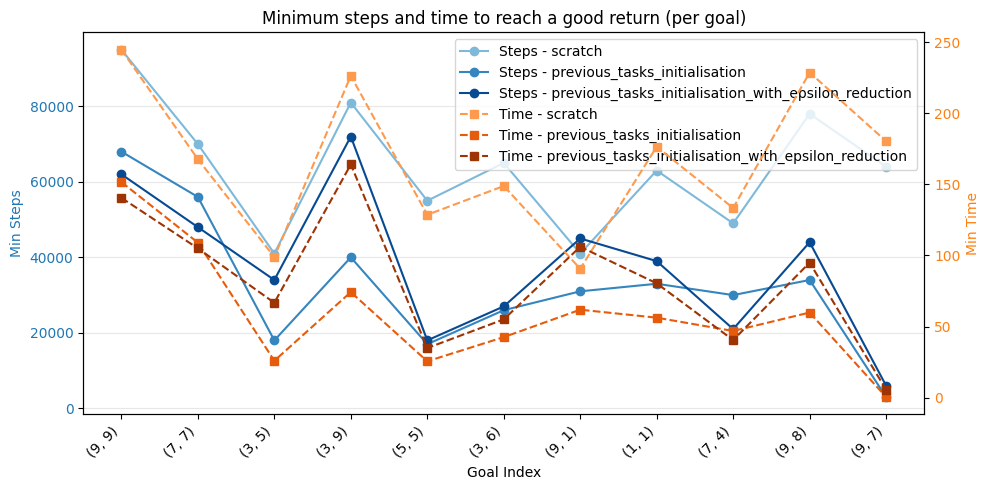

In [ ]:
# --------------------------------------------------
# CHANGE THESE NAMES ONLY
# Must match the number of experiments per goal
# Example: ["seed_1", "seed_2"] or ["exp_A", "exp_B", "exp_C"]
experiment_labels = ["scratch", "previous_tasks_initialisation", "previous_tasks_initialisation_with_epsilon_reduction"]
# --------------------------------------------------

goals = list(overall_results.keys())

used_goals = []
steps_per_goal = []
time_per_goal = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.asarray(steps_raw).reshape(-1)
    time_arr  = np.asarray(time_raw).reshape(-1)

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    steps_arr = np.array([np.nan if x is None else x for x in steps_arr], dtype=float)
    time_arr  = np.array([np.nan if x is None else x for x in time_arr], dtype=float)

    if np.all(np.isnan(steps_arr)) or np.all(np.isnan(time_arr)):
        print(f"[WARN] Skipping goal {goal}: no valid results")
        continue

    # Require same number of experiments for steps/time for this goal
    if steps_arr.size != time_arr.size:
        print(
            f"[WARN] Skipping goal {goal}: "
            f"min_steps has {steps_arr.size} entries but min_time has {time_arr.size}"
        )
        continue

    steps_per_goal.append(steps_arr)
    time_per_goal.append(time_arr)
    used_goals.append(goal)

if not used_goals:
    raise ValueError("No goals with valid non-empty min_steps/min_time found.")

# Convert to arrays of shape: (num_goals, num_experiments)
steps_per_goal = np.vstack(steps_per_goal)
time_per_goal  = np.vstack(time_per_goal)

num_goals, num_experiments = steps_per_goal.shape
x = np.arange(num_goals)

if len(experiment_labels) != num_experiments:
    raise ValueError(
        f"experiment_labels has length {len(experiment_labels)}, "
        f"but data contains {num_experiments} experiments per goal."
    )

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
step_colors = plt.cm.Blues(np.linspace(0.45, 0.9, num_experiments))
step_lines = []

for exp_idx in range(num_experiments):
    line, = ax1.plot(
        x,
        steps_per_goal[:, exp_idx],
        label=f"Steps - {experiment_labels[exp_idx]}",
        color=step_colors[exp_idx],
        marker="o",
        linestyle="-",
    )
    step_lines.append(line)

ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
time_colors = plt.cm.Oranges(np.linspace(0.45, 0.9, num_experiments))
time_lines = []

for exp_idx in range(num_experiments):
    line, = ax2.plot(
        x,
        time_per_goal[:, exp_idx],
        label=f"Time - {experiment_labels[exp_idx]}",
        color=time_colors[exp_idx],
        marker="s",
        linestyle="--",
    )
    time_lines.append(line)

ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45, ha="right")

# Combined legend across both axes
lines = step_lines + time_lines
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

ax1.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## HTML visualisation

In [5]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_net,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze_baseline.html",
    weights_his=weight_history
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])

(9, 9)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(7, 7)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(3, 5)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(3, 9)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(5, 5)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(3, 6)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(9, 1)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(1, 1)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(7, 4)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(9, 8)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
(9, 7)
task_embeddings: 3
sa_fixed_probe_embeddings: 3
sa_batches_final: 3
plots/full_embedding_dashboard_maze_baseline.html
{'trace': 0.6591070381239154, 'mean_diag': 0.010298547470686177, 'mean_abs_offdiag': 0.0018319421429220091, 'eig_ratio': 445.